# Benchmark didático da geometria de Dicke
## Estado de Dicke $\rightarrow$ Jacobiano $\rightarrow$ shots $\rightarrow$ QR $\rightarrow$ triangulação $\rightarrow$ ganho operacional

Este notebook é uma versão de **apresentação e entendimento do experimento**.

O objetivo não é esconder a matemática nem reduzir tudo a uma tabela final.
A proposta é mostrar, passo a passo:

1. como o estado inicial é preparado;
2. o que cada parâmetro do circuito significa;
3. como o Jacobiano é construído;
4. para que servem os shots;
5. como energia e geometria são combinadas;
6. o que significa manter $a$ congelado;
7. como a recorrência triangular aparece;
8. como os $\theta$ mudam;
9. e por que o ganho de custo pode chegar à ordem de $\sim25\times$.

Sempre que possível, cada definição é acompanhada de um exemplo numérico simples.


## Roteiro do experimento

A lógica do método pode ser resumida assim:

$$
\text{portfólio/hamiltoniano}
\longrightarrow
\text{estado de Dicke}
\longrightarrow
J_D
\longrightarrow
B_H = J_D^\top F_Q(E)
\longrightarrow
Q_H R_H
\longrightarrow
d_H
\longrightarrow
\theta_D + \Delta\theta
\longrightarrow
P_\star.
$$

Onde:

- $|D_k^n\rangle$ é o estado de Dicke com $k$ excitações em $n$ qubits;
- $J_D$ é o Jacobiano local do circuito avaliado no ponto de Dicke;
- $F_Q(E)$ são as features ortogonais em função da energia;
- $B_H$ é a matriz modal que conecta geometria local e energia;
- $Q_H R_H$ é a fatoração QR dessa matriz modal;
- $d_H$ é a direção geométrica no espaço de parâmetros;
- $\Delta\theta$ é o deslocamento aplicado sobre os parâmetros físicos do circuito;
- $P_\star$ é a probabilidade do bitstring ótimo (ground state).

O objetivo prático é simples:

> sair de um estado inicial simétrico e barato (Dicke),
> usar uma direção geométrica informada por estrutura,
> e obter rapidamente grande probabilidade no bitstring ótimo.


In [1]:
from pathlib import Path
from dataclasses import dataclass
import hashlib
import itertools
import json
import os
import pickle
import time
import math
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import subprocess

# Seaborn é usado apenas para visualização.
# Se não estiver instalado no ambiente local, tentamos instalar
# automaticamente usando o mesmo Python que está executando o Jupyter.
try:
    import seaborn as sns
except ModuleNotFoundError:
    print("Seaborn não encontrado. Instalando automaticamente...")
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "seaborn",
        ]
    )
    import seaborn as sns

print("seaborn =", sns.__version__)

try:
    import torch
except Exception as exc:
    raise ImportError(
        "Este benchmark requer torch para reconstruir caches geométricos ausentes."
    ) from exc

from numpy.polynomial.legendre import legvander
from scipy.optimize import minimize
from IPython.display import display

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    from qiskit import QuantumCircuit, QuantumRegister
    from qiskit.circuit import ParameterVector
    from qiskit.quantum_info import Statevector
except Exception as exc:
    raise ImportError(
        "Este benchmark requer qiskit. Instale qiskit no ambiente local."
    ) from exc

try:
    import cma
    HAVE_CMA=True
except Exception:
    HAVE_CMA=False


def normalize(v):
    """Return an L2-normalized float vector with a safe zero-norm guard."""
    v=np.asarray(
        v,
        float,
    )

    return (
        v
        /max(
            np.linalg.norm(v),
            1e-30,
        )
    )


SEED=20261006

REGIMES=[
    (10,4),
    (10,5),
    (11,5),
    (11,6),
]

PARENTS_PER_MARKET_REGIME=8

EXPECTED_MARKETS={
    "BR_EQUITY_BRL",
    "US_EQUITY_USD",
}
MIN_JOINT_OBS=40

Q_GEOM=10
RHO_STEP=2.2

RANDOM_REPLICATES=16

SHOT_BUDGETS=[
    256,512,1024,2048,
    4096,8192,16384,32768,
]
SHOT_REPLICATES=16
SHOT_GATE_SUCCESS_FRACTION=.80
COS_GATE=.95
RETENTION_GATE=.90

VQE_SHOTS_PER_EVAL=2048
VQE_CONFIRM_SHOTS=4096
VQE_MAXEVAL=128
VQE_SEEDS=[0,1,2]

# Operational geometry used in direct cost/bitstring comparisons.
GEOM_COMPARE_SHOTS=8192
GEOM_PLOT_REPLICATE=0
GEOM_CONFIRM_SHOTS=4096

# SPSA schedules. These are fixed before seeing the test outcomes.
SPSA_A0=0.08
SPSA_C0=0.10
SPSA_ALPHA=0.602
SPSA_GAMMA=0.101
VQE_OPTIMIZERS=[
    "COBYLA",
    "POWELL",
    "NELDER_MEAD",
    "SPSA",
]+(
    ["CMAES"]
    if HAVE_CMA
    else []
)

FAST_DEV=os.environ.get("GEOM_FAST_DEV","0")=="1"

if FAST_DEV:
    PARENTS_PER_MARKET_REGIME=2
    RANDOM_REPLICATES=4
    SHOT_REPLICATES=4
    VQE_MAXEVAL=24
    VQE_SEEDS=[0]

ANNUALIZATION=252.0
RISK_GAMMA=.50
RETURN_BETA=1.00
ORTHO_Z_SCALE=3.0

SCALING_DEVICE=torch.device(
    os.environ.get("GEOM_SCALING_DEVICE","cpu")
)
SCALING_REAL=torch.float64
SCALING_COMPLEX=torch.complex128

torch.set_default_dtype(torch.float64)

FROZEN_A_Q10=np.asarray(
    [
        -0.58430912,
         0.41316894,
        -0.33735103,
         0.29215456,
        -0.26131098,
         0.23854320,
        -0.22084809,
         0.20658447,
        -0.19476971,
         0.18477477,
    ],
    float,
)
FROZEN_A_Q10=FROZEN_A_Q10/np.linalg.norm(FROZEN_A_Q10)

# ------------------------------------------------------------------
# Diretório de resultados/caches
#
# O notebook procura primeiro um benchmark já executado. Isso evita
# recalcular milhares de avaliações apenas para a apresentação.
# Se nada for encontrado, cria um diretório local novo.
# ------------------------------------------------------------------
_ENV_OUTPUT_ROOT=os.environ.get(
    "GEOM_OUTPUT_ROOT",
    "",
).strip()

if _ENV_OUTPUT_ROOT:
    OUTPUT_ROOT=Path(
        _ENV_OUTPUT_ROOT
    ).expanduser().resolve()
else:
    _output_candidates=[
        Path.home()/"Desktop"/"v82105_paper1_operational_benchmark",
        Path.cwd()/"v82105_paper1_operational_benchmark",
        Path.cwd()/"geometry_benchmark_didactic",
    ]

    _existing=[
        p.expanduser().resolve()
        for p in _output_candidates
        if p.expanduser().exists()
    ]

    OUTPUT_ROOT=(
        _existing[0]
        if _existing
        else (
            Path.cwd()
            /"geometry_benchmark_didactic"
        ).resolve()
    )

DATA_DIR=OUTPUT_ROOT/"data"
FIG_DIR=OUTPUT_ROOT/"figures"
CACHE_DIR=OUTPUT_ROOT/"cache"

for p in [
    OUTPUT_ROOT,DATA_DIR,FIG_DIR,CACHE_DIR
]:
    p.mkdir(parents=True,exist_ok=True)

print("FAST_DEV =",FAST_DEV)
print("REGIMES =",REGIMES)
print("VQE_OPTIMIZERS =",VQE_OPTIMIZERS)
print("OUTPUT_ROOT selecionado =",OUTPUT_ROOT)
BASE_OUTPUT_ROOT=OUTPUT_ROOT

PRESENTATION_ROOT=BASE_OUTPUT_ROOT/"presentation_analysis"
PRESENTATION_DATA_DIR=PRESENTATION_ROOT/"data"
PRESENTATION_FIG_DIR=PRESENTATION_ROOT/"figures"
PRESENTATION_CACHE_DIR=PRESENTATION_ROOT/"cache"

for _p in [
    PRESENTATION_ROOT,
    PRESENTATION_DATA_DIR,
    PRESENTATION_FIG_DIR,
    PRESENTATION_CACHE_DIR,
]:
    _p.mkdir(
        parents=True,
        exist_ok=True,
    )

GEOM_COMPARE_SHOTS=8192
GEOM_COMPARE_REPLICATES=16
GEOM_THETA_REPLICATE=0

# Full-cohort causal audit: all optimizers, seed 0, plus geometry.
# Set GEOM_CAUSAL_ALL_SEEDS=1 to expand to all VQE seeds.
CAUSAL_ALL_SEEDS=os.environ.get(
    "GEOM_CAUSAL_ALL_SEEDS",
    "0",
)=="1"

# Optional development mode for the expensive statevector ablation.
GEOM_FAST_CAUSAL=os.environ.get(
    "GEOM_FAST_CAUSAL",
    "0",
)=="1"

print("PRESENTATION_ROOT =",PRESENTATION_ROOT)

sns.set_theme(context="talk", style="whitegrid")
plt.rcParams["figure.dpi"] = 140


seaborn = 0.13.2
FAST_DEV = False
REGIMES = [(10, 4), (10, 5), (11, 5), (11, 6)]
VQE_OPTIMIZERS = ['COBYLA', 'POWELL', 'NELDER_MEAD', 'SPSA', 'CMAES']
OUTPUT_ROOT selecionado = /home/marlonmaxuel/Desktop/v82105_paper1_operational_benchmark
PRESENTATION_ROOT = /home/marlonmaxuel/Desktop/v82105_paper1_operational_benchmark/presentation_analysis


/home/marlonmaxuel/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def stable_int(*parts):
    s="|".join(map(str,parts))
    return int(
        hashlib.sha256(
            s.encode()
        ).hexdigest()[:16],
        16,
    )%(2**32-1)


def resolve_root(env_name,candidates,required):
    roots=[]
    env=os.environ.get(env_name,"").strip()
    if env:
        roots.append(Path(env))

    roots += [Path(x) for x in candidates]

    seen=set()

    for root in roots:
        root=root.expanduser().resolve()

        if str(root) in seen:
            continue

        seen.add(str(root))

        if all((root/r).exists() for r in required):
            return root

    return None


DATASET_ROOT=resolve_root(
    "GEOM_DATASET_ROOT",
    [
        Path.cwd()/"20_22A_yahoo_dataset_v2",
        Path.cwd().parent/"20_22A_yahoo_dataset_v2",
        Path.home()/"Desktop"/"20_22A_yahoo_dataset_v2",
        Path.home()/"Documents"/"20_22A_yahoo_dataset_v2",
    ],
    [
        Path("03_splits")/"yf__returns__train__v2.parquet",
    ],
)

V821022_ROOT=resolve_root(
    "V82105_V821022_ROOT",
    [
        Path.cwd()/"v821022_modal_contribution_mechanism_audit",
        Path.cwd().parent/"v821022_modal_contribution_mechanism_audit",
        Path.home()/"Desktop"/"v821022_modal_contribution_mechanism_audit",
        Path.home()/"Documents"/"v821022_modal_contribution_mechanism_audit",
    ],
    [
        Path("data")/"mechanism_instance_summary.parquet",
        Path("data")/"mechanism_gates.csv",
    ],
)

CACHE_ROOTS=[]
env=os.environ.get("V82105_CACHE_ROOT","").strip()
if env:
    CACHE_ROOTS.append(Path(env).expanduser().resolve())

CACHE_ROOTS += [
    Path.cwd()/"v821033_joint_delta_method_audit_final"/"scaling_cache",
    Path.cwd()/"v821033_joint_delta_method_audit_fixed_d4b"/"scaling_cache",
    Path.cwd()/"v821032_second_mode_bottleneck_audit"/"scaling_cache",
    Path.home()/"Desktop"/"v821033_joint_delta_method_audit_final"/"scaling_cache",
    Path.home()/"Desktop"/"v821033_joint_delta_method_audit_fixed_d4b"/"scaling_cache",
    Path.home()/"Desktop"/"v821032_second_mode_bottleneck_audit"/"scaling_cache",
]
CACHE_ROOTS=[
    CACHE_DIR,
    V821022_ROOT/"scaling_cache",
]+CACHE_ROOTS

CACHE_ROOTS=[
    p.expanduser().resolve()
    for p in CACHE_ROOTS
]

if DATASET_ROOT is None:
    raise FileNotFoundError("Defina GEOM_DATASET_ROOT.")

if V821022_ROOT is None:
    raise FileNotFoundError("Defina V82105_V821022_ROOT.")

print("DATASET_ROOT =",DATASET_ROOT)
print("V821022_ROOT =",V821022_ROOT)

DATASET_ROOT = /home/marlonmaxuel/Desktop/20_22A_yahoo_dataset_v2
V821022_ROOT = /home/marlonmaxuel/Desktop/v821022_modal_contribution_mechanism_audit



## 1. Problema físico-combinatório e estado de Dicke

No subespaço de Hamming fixo, cada bitstring viável possui exatamente $k$ ativos selecionados entre $n$ possibilidades.
O número total de estados viáveis é:

$$
M = \binom{n}{k}.
$$

O **estado de Dicke** correspondente é a superposição uniforme sobre todos esses bitstrings:

$$
|D_k^n\rangle
=
\frac{1}{\sqrt{\binom{n}{k}}}
\sum_{x\,:\,|x|=k} |x\rangle.
$$

### Exemplo simples

Se $n=4$ e $k=2$, então:

$$
M = \binom{4}{2}=6,
$$

e os seis bitstrings viáveis são, por exemplo:

$$
1100,\;1010,\;1001,\;0110,\;0101,\;0011.
$$

No ponto de Dicke, todos esses estados têm a mesma amplitude e, portanto, a mesma probabilidade:

$$
P_D(x)=\frac{1}{6}.
$$

Esse é o ponto de partida do nosso experimento.


### Referências para esta etapa

O estado de Dicke foi introduzido originalmente no contexto de estados coletivos
simétricos por Dicke:

- R. H. Dicke, *Coherence in Spontaneous Radiation Processes*,
  **Physical Review 93**, 99–110 (1954).
  DOI: `10.1103/PhysRev.93.99`.

Para preparação determinística de estados de Dicke em circuitos quânticos:

- A. Bärtschi e S. Eidenbenz, *Deterministic Preparation of Dicke States*,
  FCT 2019, pp. 126–139.
  DOI: `10.1007/978-3-030-25027-0_9`.

Para o uso de subespaços factíveis e operadores que preservam restrições em
otimização quântica:

- S. Hadfield et al., *From the Quantum Approximate Optimization Algorithm to a
  Quantum Alternating Operator Ansatz*, **Algorithms 12**, 34 (2019).
  DOI: `10.3390/a12020034`.


In [3]:
split_dir=DATASET_ROOT/"03_splits"

returns_train=pd.read_parquet(
    split_dir/"yf__returns__train__v2.parquet"
)

test_path=split_dir/"yf__returns__test__v2.parquet"
cal_path=split_dir/"yf__returns__calibration__v2.parquet"

if test_path.exists():
    returns_eval=pd.read_parquet(test_path)
    EVAL_SPLIT="test_2025"
elif cal_path.exists():
    returns_eval=pd.read_parquet(cal_path)
    EVAL_SPLIT="calibration_2024"
else:
    returns_eval=returns_train
    EVAL_SPLIT="train_2024_FALLBACK"

MECH_INSTANCE=pd.read_parquet(
    V821022_ROOT/"data"/"mechanism_instance_summary.parquet"
)

MECH_GATES=pd.read_csv(
    V821022_ROOT/"data"/"mechanism_gates.csv"
)

if not MECH_GATES["pass_gate"].astype(bool).all():
    raise RuntimeError("V8.2.10.2.2 possui gate falho.")

SOURCE=MECH_INSTANCE[
    [
        "market","parent_id","asset_ids",
        "asset_hash","n","k","M",
    ]
].drop_duplicates().copy()

eligible_rows=[]

for row in SOURCE.itertuples(index=False):
    if (int(row.n),int(row.k)) not in REGIMES:
        continue

    assets=str(row.asset_ids).split("|")

    if not set(assets).issubset(
        set(returns_eval.columns)
    ):
        continue

    joint=returns_eval[
        assets
    ].dropna(how="any")

    if len(joint)<MIN_JOINT_OBS:
        continue

    eligible_rows.append(
        {
            "market":row.market,
            "parent_id":row.parent_id,
            "asset_ids":row.asset_ids,
            "asset_hash":row.asset_hash,
            "n":int(row.n),
            "k":int(row.k),
            "M":int(row.M),
            "n_joint_eval":int(len(joint)),
            "selection_hash":stable_int(
                "paper1-benchmark",
                EVAL_SPLIT,
                row.market,
                row.parent_id,
            ),
        }
    )

ELIGIBLE=pd.DataFrame(eligible_rows)

selected=[]

for (market,n,k),g in ELIGIBLE.groupby(
    ["market","n","k"]
):
    g=g.sort_values(
        ["selection_hash","parent_id"]
    ).head(
        PARENTS_PER_MARKET_REGIME
    )

    selected.append(g)

COHORT=pd.concat(
    selected,
    ignore_index=True,
)

expected_groups={
    (m,n,k)
    for m in COHORT["market"].unique()
    for n,k in REGIMES
}

print("EVAL_SPLIT =",EVAL_SPLIT)
display(
    COHORT.groupby(
        ["market","n","k"]
    ).size().rename("parents").reset_index()
)

COHORT.to_csv(
    DATA_DIR/"benchmark_cohort_preregistered.csv",
    index=False,
)

# ------------------------------------------------------------------
# Early preregistration / coverage gate.
# Run this BEFORE geometry, finite-shot, or VQE campaigns.
# ------------------------------------------------------------------
EXPECTED_CELLS={
    (market,n,k)
    for market in EXPECTED_MARKETS
    for n,k in REGIMES
}

ELIGIBLE_COUNTS=(
    ELIGIBLE.groupby(
        ["market","n","k"]
    )
    .size()
    .rename("eligible_parents")
)

COHORT_COUNTS=(
    COHORT.groupby(
        ["market","n","k"]
    )
    .size()
    .rename("selected_parents")
)

coverage_rows=[]

for market,n,k in sorted(
    EXPECTED_CELLS
):
    coverage_rows.append(
        {
            "market":market,
            "n":int(n),
            "k":int(k),
            "eligible_parents":int(
                ELIGIBLE_COUNTS.get(
                    (market,n,k),
                    0,
                )
            ),
            "selected_parents":int(
                COHORT_COUNTS.get(
                    (market,n,k),
                    0,
                )
            ),
        }
    )

COHORT_COVERAGE=pd.DataFrame(
    coverage_rows
)

display(
    COHORT_COVERAGE
)

observed_cells=set(
    map(
        tuple,
        COHORT[
            ["market","n","k"]
        ]
        .drop_duplicates()
        .to_numpy()
    )
)

COHORT_GATES=pd.DataFrame(
    [
        {
            "gate":"C0_temporal_holdout_is_test_2025",
            "pass_gate":EVAL_SPLIT=="test_2025",
            "value":EVAL_SPLIT,
            "requirement":"test_2025",
        },
        {
            "gate":"C1_all_expected_market_regime_cells_exist",
            "pass_gate":observed_cells==EXPECTED_CELLS,
            "value":f"{len(observed_cells)}/{len(EXPECTED_CELLS)} cells",
            "requirement":f"{len(EXPECTED_CELLS)}/{len(EXPECTED_CELLS)} cells",
        },
        {
            "gate":"C2_at_least_8_eligible_parents_per_cell",
            "pass_gate":bool(
                (
                    COHORT_COVERAGE[
                        "eligible_parents"
                    ]>=PARENTS_PER_MARKET_REGIME
                ).all()
            ),
            "value":int(
                COHORT_COVERAGE[
                    "eligible_parents"
                ].min()
            ),
            "requirement":f">={PARENTS_PER_MARKET_REGIME}",
        },
        {
            "gate":"C3_exactly_8_selected_parents_per_cell",
            "pass_gate":bool(
                (
                    COHORT_COVERAGE[
                        "selected_parents"
                    ]==PARENTS_PER_MARKET_REGIME
                ).all()
            ),
            "value":f"min={int(COHORT_COVERAGE['selected_parents'].min())}, "
                    f"max={int(COHORT_COVERAGE['selected_parents'].max())}",
            "requirement":PARENTS_PER_MARKET_REGIME,
        },
    ]
)

display(
    COHORT_GATES
)

COHORT_COVERAGE.to_csv(
    DATA_DIR/
    "benchmark_cohort_coverage.csv",
    index=False,
)

COHORT_GATES.to_csv(
    DATA_DIR/
    "benchmark_cohort_early_gates.csv",
    index=False,
)

if not COHORT_GATES[
    "pass_gate"
].astype(bool).all():
    raise RuntimeError(
        "A coorte real não satisfaz o contrato pré-registrado. "
        "Não executar geometry/shot/VQE até corrigir a seleção."
    )

print(
    "Early cohort contract: PASS"
)

EVAL_SPLIT = test_2025


,market,n,k,parents
0,BR_EQUITY_BRL,10,4,8
1,BR_EQUITY_BRL,10,5,8
2,BR_EQUITY_BRL,11,5,8
3,BR_EQUITY_BRL,11,6,8
4,US_EQUITY_USD,10,4,8
5,US_EQUITY_USD,10,5,8
6,US_EQUITY_USD,11,5,8
7,US_EQUITY_USD,11,6,8


,market,n,k,eligible_parents,selected_parents
0,BR_EQUITY_BRL,10,4,66,8
1,BR_EQUITY_BRL,10,5,66,8
2,BR_EQUITY_BRL,11,5,12,8
3,BR_EQUITY_BRL,11,6,12,8
4,US_EQUITY_USD,10,4,66,8
5,US_EQUITY_USD,10,5,66,8
6,US_EQUITY_USD,11,5,12,8
7,US_EQUITY_USD,11,6,12,8


,gate,pass_gate,value,requirement
0,C0_temporal_holdout_is_test_2025,True,test_2025,test_2025
1,C1_all_expected_market_regime_cells_exist,True,8/8 cells,8/8 cells
2,C2_at_least_8_eligible_parents_per_cell,True,12,>=8
3,C3_exactly_8_selected_parents_per_cell,True,"min=8, max=8",8


Early cohort contract: PASS



## 2. Parâmetros físicos do circuito: o que são $l$ e $i$?

A preparação do estado de Dicke usa uma malha de rotações controladas que redistribui amplitude dentro do subespaço de Hamming fixo.
Cada parâmetro ativo fica associado a um par lógico:

$$
(l,i).
$$

### Interpretação prática

- $l$ indica a **posição mais à direita** (o bloco/qubit-alvo da etapa atual da construção);
- $i$ indica a **posição de controle** que participa da redistribuição de amplitude;
- quando $i=l-1$, a gate é do tipo **CY**;
- quando $i<l-1$, a gate é do tipo **CCY**.

Em linguagem simples:

> o índice $l$ diz **onde** a etapa está atuando,
> e o índice $i$ diz **por qual caminho lógico** a amplitude está sendo redirecionada.

A estrutura ativa possui dimensão:

$$
d = k(n-k),
$$

ou seja, só os parâmetros realmente capazes de mover amplitude dentro do subespaço entram no experimento.


### Exemplo didático de $(l,i)$

Suponha que, em uma etapa do circuito, tenhamos

$$
l=5.
$$

Os possíveis controles associados podem incluir, por exemplo,

$$
i=4,\;3,\;2,\ldots
$$

Quando

$$
i=l-1=4,
$$

temos uma interação de vizinhança imediata, representada aqui por uma gate `CY`.

Quando

$$
i<l-1,
$$

o acoplamento atravessa um nível lógico intermediário e aparece como `CCY`.

Assim, uma chave como

$$
(l,i,\mathrm{gate})=(5,3,\mathrm{CCY})
$$

não é um rótulo arbitrário: ela identifica exatamente **qual caminho de
redistribuição de amplitude** aquele parâmetro controla.

Essa chave lógica é também o que permite alinhar corretamente a ordem
estrutural do ansatz com a ordem interna de parâmetros do Qiskit.


In [4]:
# =====================================================================
# MAPA MATEMÁTICO DESTA CÉLULA
# =====================================================================
# [D1] Número de estados factíveis:
#      M = C(n,k)
#
# [D2] Número de parâmetros ativos do ansatz usado aqui:
#      d = k(n-k)
#
# [D3] Ângulo de Dicke de cada relação lógica (l,i):
#      CY : theta_D = 2 arccos sqrt((l-i)/(l+1))
#      CCY: theta_D =   arccos sqrt((l-i)/(l+1))
#
# [D4] Conversão para a coordenada interna phi:
#      phi_D = 2*pi*theta_D / periodo
#
# [J1] O SAFE-JVP constrói o Jacobiano local:
#      J_D(x,j) = d p_phi(x) / d phi_j |_(phi=phi_D)
#
# As linhas do Jacobiano são bitstrings factíveis x.
# As colunas são parâmetros ativos j.
# =====================================================================

def build_active_structure(n,k):
    """Reduced Dicke active-coordinate contract used in the V8.2 scaling audits."""
    records=[]
    occupied_start=n-k

    for l in range(n)[::-1]:
        for i in range(l-1,l-1-k,-1):
            if i<0:
                continue

            gate_type="CY" if i==l-1 else "CCY"
            dead=bool(
                l>=occupied_start
                and i>=occupied_start
            )

            ratio=float(l-i)/float(l+1)

            if gate_type=="CY":
                theta_D=float(
                    2*np.arccos(np.sqrt(ratio))
                )
                period=4*np.pi
            else:
                theta_D=float(
                    np.arccos(np.sqrt(ratio))
                )
                period=2*np.pi

            phi_D=2*np.pi*theta_D/period

            records.append(
                {
                    "l":int(l),
                    "i":int(i),
                    "gate_type":gate_type,
                    "is_structural_null":dead,
                    "theta_D":theta_D,
                    "period":float(period),
                    "phi_D":float(phi_D),
                }
            )

    return (
        records,
        [r for r in records if not r["is_structural_null"]],
    )


def local_scaling_cache_path(n,k):
    return CACHE_DIR/f"scaling_engine_{int(n)}C{int(k)}.npz"


def find_scaling_cache(n,k):
    name=f"scaling_engine_{int(n)}C{int(k)}.npz"

    for root in CACHE_ROOTS:
        p=Path(root)/name

        if not p.exists():
            continue

        z=np.load(p,allow_pickle=False)

        required={
            "M",
            "d_active",
            "X",
            "V",
            "J_modal",
        }

        if required.issubset(set(z.files)):
            return p

        print(
            "[cache ignored: missing fields]",
            p,
            "available=",
            z.files,
        )

    return None


def build_scaling_engine(n,k,force=False):
    """
    Load a valid geometry cache or rebuild it with the same SAFE-JVP
    construction used in the earlier V8.2 audits.

    Cache contract:
        J_modal = J_raw @ V
    """
    n=int(n)
    k=int(k)

    cp=find_scaling_cache(n,k)

    if cp is not None and not force:
        z=np.load(cp,allow_pickle=False)

        return {
            "M":int(z["M"]),
            "d_active":int(z["d_active"]),
            "X":z["X"],
            "V":z["V"],
            "J_modal":z["J_modal"],
            "source":str(cp),
            "cache_hit":True,
            "build_seconds":(
                float(z["build_seconds"])
                if "build_seconds" in z.files
                else np.nan
            ),
        }

    print(
        f"[autobuild] scaling_engine_{n}C{k}.npz não encontrado; "
        "reconstruindo SAFE-JVP..."
    )

    t0=time.perf_counter()

    active_records=build_active_structure(n,k)[1]
    d=len(active_records)
    expected_d=k*(n-k)

    if d!=expected_d:
        raise RuntimeError(
            f"Active-coordinate mismatch for {n}C{k}: "
            f"{d} != k(n-k)={expected_d}"
        )

    dim=2**n

    combos=list(
        itertools.combinations(range(n),k)
    )
    M=len(combos)

    basis=np.asarray(
        [
            sum(1<<q for q in combo)
            for combo in combos
        ],
        np.int64,
    )

    X=np.zeros((M,n),np.int8)
    for r,combo in enumerate(combos):
        X[r,list(combo)]=1

    dev=SCALING_DEVICE

    index=torch.arange(
        dim,
        dtype=torch.long,
        device=dev,
    )

    basis_t=torch.tensor(
        basis,
        dtype=torch.long,
        device=dev,
    )

    phi=torch.tensor(
        [rec["phi_D"] for rec in active_records],
        dtype=SCALING_REAL,
        device=dev,
    )

    periods=torch.tensor(
        [rec["period"] for rec in active_records],
        dtype=SCALING_REAL,
        device=dev,
    )

    initial_index=sum(
        1<<(n-exc-1)
        for exc in range(k)
    )

    cx_pairs={}
    ccx_pairs={}
    ry_pairs={}
    cry_pairs={}

    for rec in active_records:
        l=int(rec["l"])
        i=int(rec["i"])

        key=(i,l)

        if key not in cx_pairs:
            mask=(
                (((index>>i)&1)==1)
                & (((index>>l)&1)==0)
            )

            a=index[mask]
            cx_pairs[key]=(a,a|(1<<l))

        if i not in ry_pairs:
            mask=((index>>i)&1)==0
            a=index[mask]
            ry_pairs[i]=(a,a|(1<<i))

        if rec["gate_type"]=="CY":
            key=(l,i)

            mask=(
                (((index>>l)&1)==1)
                & (((index>>i)&1)==0)
            )

            a=index[mask]
            cry_pairs[key]=(a,a|(1<<i))

        else:
            key=(l,i+1,i)

            if key not in ccx_pairs:
                mask=(
                    (((index>>l)&1)==1)
                    & (((index>>(i+1))&1)==1)
                    & (((index>>i)&1)==0)
                )

                a=index[mask]
                ccx_pairs[key]=(a,a|(1<<i))

    def swap(state,pairs):
        a,b=pairs
        out=state.clone()
        out[a]=state[b]
        out[b]=state[a]
        return out

    def ry(state,theta,pairs):
        a,b=pairs
        x=state[a]
        y=state[b]

        c=torch.cos(theta/2).to(SCALING_COMPLEX)
        ss=torch.sin(theta/2).to(SCALING_COMPLEX)

        out=state.clone()
        out[a]=c*x-ss*y
        out[b]=ss*x+c*y
        return out

    def prob_torch(delta):
        dw=torch.atan2(
            torch.sin(delta),
            torch.cos(delta),
        )

        theta=periods*(phi+dw)/(2*math.pi)

        state=torch.zeros(
            dim,
            dtype=SCALING_COMPLEX,
            device=dev,
        )

        state[initial_index]=1+0j

        for aa,rec in enumerate(active_records):
            l=int(rec["l"])
            i=int(rec["i"])
            th=theta[aa]

            state=swap(
                state,
                cx_pairs[(i,l)],
            )

            if rec["gate_type"]=="CY":
                state=ry(
                    state,
                    th,
                    cry_pairs[(l,i)],
                )
            else:
                state=ry(
                    state,
                    th,
                    ry_pairs[i],
                )

                state=swap(
                    state,
                    ccx_pairs[(l,i+1,i)],
                )

                state=ry(
                    state,
                    -th,
                    ry_pairs[i],
                )

                state=swap(
                    state,
                    ccx_pairs[(l,i+1,i)],
                )

            state=swap(
                state,
                cx_pairs[(i,l)],
            )

        p=state.real.square()+state.imag.square()
        return p[basis_t]

    d0=torch.zeros(
        d,
        dtype=SCALING_REAL,
        device=dev,
    )

    cols=[]

    for j in tqdm(
        range(d),
        desc=f"SAFE-JVP {n}C{k}",
    ):
        v=torch.zeros_like(d0)
        v[j]=1.0

        _,tan=torch.autograd.functional.jvp(
            prob_torch,
            d0,
            v,
            create_graph=False,
            strict=False,
        )

        cols.append(
            tan.detach().cpu().numpy()
        )

    J_raw=np.column_stack(cols)

    G=J_raw.T@J_raw
    ew,V=np.linalg.eigh(G)

    order=np.argsort(ew)[::-1]
    V=V[:,order]

    for j in range(V.shape[1]):
        ii=int(
            np.argmax(np.abs(V[:,j]))
        )

        if V[ii,j]<0:
            V[:,j]*=-1.0

    J_modal=J_raw@V

    build_seconds=float(
        time.perf_counter()-t0
    )

    local_cp=local_scaling_cache_path(n,k)

    np.savez(
        local_cp,
        M=np.asarray(M),
        d_active=np.asarray(d),
        X=X,
        V=V,
        J_modal=J_modal,
        build_seconds=np.asarray(build_seconds),
    )

    print(
        f"[autobuild done] {n}C{k}: "
        f"M={M}, d={d}, {build_seconds:.2f}s -> {local_cp}"
    )

    del J_raw,G,index,basis_t,d0
    del cx_pairs,ccx_pairs,ry_pairs,cry_pairs

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()

    return {
        "M":M,
        "d_active":d,
        "X":X,
        "V":V,
        "J_modal":J_modal,
        "source":str(local_cp),
        "cache_hit":False,
        "build_seconds":build_seconds,
    }


def load_engine(n,k):
    return build_scaling_engine(
        n,
        k,
        force=False,
    )


ENGINE_BY_REGIME={}
ENGINE_ROWS=[]

for n,k in REGIMES:
    eng=load_engine(n,k)

    ENGINE_BY_REGIME[(n,k)]=eng

    ENGINE_ROWS.append(
        {
            "n":int(n),
            "k":int(k),
            "M":int(eng["M"]),
            "d_active":int(eng["d_active"]),
            "cache_hit":bool(eng["cache_hit"]),
            "source":eng["source"],
            "build_seconds":float(eng["build_seconds"]),
        }
    )

ENGINE_AUDIT=pd.DataFrame(ENGINE_ROWS)

display(ENGINE_AUDIT)

ENGINE_AUDIT.to_csv(
    DATA_DIR/"geometry_engine_sources.csv",
    index=False,
)


@dataclass
class Problem:
    problem_id:str
    parent_id:str
    market:str
    n:int
    k:int
    asset_ids:list
    mu:np.ndarray
    Sigma:np.ndarray
    X:np.ndarray
    J:np.ndarray
    V:np.ndarray
    E:np.ndarray
    opt_mask:np.ndarray
    E0:float
    Emax:float
    n_joint:int


PROBLEMS=[]

for row in COHORT.itertuples(index=False):
    assets=str(row.asset_ids).split("|")

    frame=returns_eval[
        assets
    ].dropna(how="any")

    mu=ANNUALIZATION*frame.mean().to_numpy(float)
    Sigma=ANNUALIZATION*frame.cov().to_numpy(float)
    Sigma=.5*(Sigma+Sigma.T)

    eng=ENGINE_BY_REGIME[
        (int(row.n),int(row.k))
    ]

    X=np.asarray(
        eng["X"],
        dtype=np.int8,
    )

    E=(
        RISK_GAMMA*np.einsum(
            "bi,ij,bj->b",
            X.astype(float),
            Sigma,
            X.astype(float),
            optimize=True,
        )
        -RETURN_BETA*(
            X.astype(float)@mu
        )
    )

    E0=float(E.min())

    opt_mask=np.isclose(
        E,
        E0,
        atol=1e-12,
        rtol=0,
    )

    V=np.asarray(
        eng["V"],
        float,
    )

    if not np.allclose(
        V.T@V,
        np.eye(V.shape[1]),
        rtol=0,
        atol=1e-10,
    ):
        raise RuntimeError(
            f"Modal basis V is not orthogonal for {row.n}C{row.k}."
        )

    PROBLEMS.append(
        Problem(
            problem_id=(
                f"{str(row.market)}::"
                f"{str(row.parent_id)}::"
                f"{int(row.n)}C{int(row.k)}"
            ),
            parent_id=str(row.parent_id),
            market=str(row.market),
            n=int(row.n),
            k=int(row.k),
            asset_ids=assets,
            mu=mu,
            Sigma=Sigma,
            X=X,
            J=np.asarray(
                eng["J_modal"],
                float,
            ),
            V=V,
            E=np.asarray(E,float),
            opt_mask=opt_mask,
            E0=E0,
            Emax=float(E.max()),
            n_joint=int(len(frame)),
        )
    )


PROBLEM_TABLE=pd.DataFrame(
    [
        {
            "problem_id":p.problem_id,
            "parent_id":p.parent_id,
            "market":p.market,
            "n":p.n,
            "k":p.k,
            "M":len(p.E),
            "d_active":p.J.shape[1],
            "ground_degeneracy":int(p.opt_mask.sum()),
            "n_joint":p.n_joint,
        }
        for p in PROBLEMS
    ]
)


# A physical parent may legitimately appear at multiple cardinalities k.
# Therefore every cache key must be sector-specific.
if not PROBLEM_TABLE["problem_id"].is_unique:
    dup=PROBLEM_TABLE[
        PROBLEM_TABLE["problem_id"].duplicated(
            keep=False
        )
    ].sort_values(
        "problem_id"
    )

    display(dup)

    raise RuntimeError(
        "problem_id collision after sector-ID construction."
    )

expected_uid=[
    f"{p.market}::{p.parent_id}::{p.n}C{p.k}"
    for p in PROBLEMS
]

if expected_uid!=PROBLEM_TABLE["problem_id"].tolist():
    raise RuntimeError(
        "Sector-ID contract mismatch."
    )

print(
    "Unique sector IDs:",
    PROBLEM_TABLE["problem_id"].nunique(),
    "/",
    len(PROBLEM_TABLE),
)

display(
    PROBLEM_TABLE.groupby(
        ["market","n","k"]
    ).agg(
        problems=("problem_id","size"),
        median_M=("M","median"),
        median_d=("d_active","median"),
    ).reset_index()
)

PROBLEM_TABLE.to_csv(
    DATA_DIR/"problem_manifest.csv",
    index=False,
)

,n,k,M,d_active,cache_hit,source,build_seconds
0,10,4,210,24,True,/home/marlonmaxuel/Desktop/v821033_joint_delta...,NaN
1,10,5,252,25,True,/home/marlonmaxuel/Desktop/v821033_joint_delta...,NaN
2,11,5,462,30,True,/home/marlonmaxuel/Desktop/v821033_joint_delta...,NaN
3,11,6,462,30,True,/home/marlonmaxuel/Desktop/v821033_joint_delta...,NaN


Unique sector IDs: 64 / 64


,market,n,k,problems,median_M,median_d
0,BR_EQUITY_BRL,10,4,8,210.0,24.0
1,BR_EQUITY_BRL,10,5,8,252.0,25.0
2,BR_EQUITY_BRL,11,5,8,462.0,30.0
3,BR_EQUITY_BRL,11,6,8,462.0,30.0
4,US_EQUITY_USD,10,4,8,210.0,24.0
5,US_EQUITY_USD,10,5,8,252.0,25.0
6,US_EQUITY_USD,11,5,8,462.0,30.0
7,US_EQUITY_USD,11,6,8,462.0,30.0



## 3. Como o circuito de Dicke é montado

O circuito começa colocando $k$ excitações em uma configuração de referência e, em seguida, aplica uma sequência ordenada de gates parametrizadas.

Do ponto de vista operacional, cada parâmetro controla uma rotação que modifica a distribuição de amplitudes entre os bitstrings viáveis.

Se chamarmos o vetor de parâmetros físicos de:

$$
\phi = (\phi_1,\ldots,\phi_d),
$$

o ponto de Dicke corresponde ao vetor especial:

$$
\phi_D.
$$

A partir dele, consideramos deslocamentos:

$$
\Delta\phi = \phi - \phi_D.
$$

Mais adiante convertemos isso para ângulos físicos $\theta$, pois é nessa escala que faz sentido comparar amplitudes dos parâmetros.


In [5]:
# =====================================================================
# MAPA MATEMÁTICO DESTA CÉLULA — PREPARAÇÃO DO ESTADO DE DICKE
# =====================================================================
# O circuito começa em uma configuração com exatamente k excitações.
#
# Cada par lógico (l,i) identifica uma rotação que redistribui amplitude:
#   l -> posição/bloco alvo da etapa;
#   i -> controle lógico associado.
#
# Se i = l-1 usamos CY.
# Se i < l-1 usamos CCY.
#
# A lista logical_key=(l,i,gate_type) preserva essa interpretação física
# mesmo quando o Qiskit reorganiza internamente a ordem dos parâmetros.
# =====================================================================

def CY_parameterized(identifier):
    param=ParameterVector(
        name=f"x{identifier}",
        length=1,
    )

    qc=QuantumCircuit(2)
    qc.cry(
        param[0],
        1,
        0,
    )

    return qc.to_gate(
        label="CY"
    )


def CCY_parameterized(identifier):
    param=ParameterVector(
        name=f"y{identifier}",
        length=1,
    )

    qc=QuantumCircuit(3)

    qc.ry(
        param[0],
        0,
    )
    qc.ccx(
        2,
        1,
        0,
    )
    qc.ry(
        -param[0],
        0,
    )
    qc.ccx(
        2,
        1,
        0,
    )

    return qc.to_gate(
        label="CCY"
    )


def logical_key(l,i,gate_type):
    return (
        int(l),
        int(i),
        str(gate_type),
    )


def is_dead_pair(n,k,l,i):
    occupied_start=n-k

    return bool(
        l>=occupied_start
        and i>=occupied_start
    )


def build_dicke_circuit(n,k,seed=0):
    old=np.random.get_state()

    try:
        np.random.seed(
            int(seed)
        )

        qr=QuantumRegister(
            n,
            "q",
        )

        qc=QuantumCircuit(
            qr
        )

        for exc in range(k):
            qc.x(
                n-exc-1
            )

        records=[]
        aux=1

        for l in range(n)[::-1]:
            for i in range(
                l-1,
                l-1-k,
                -1,
            ):
                if i<0:
                    aux+=1
                    continue

                if is_dead_pair(
                    n,k,l,i
                ):
                    aux+=1
                    continue

                uid=(
                    f"{l}{i}{aux}"
                    f"{np.random.randint(0,int(1e8))}"
                )

                if i==l-1:
                    gate=CY_parameterized(
                        uid
                    )

                    par=list(
                        gate.params[0].parameters
                    )[0]

                    qc.cx(
                        qr[i],
                        qr[l],
                    )

                    qc.append(
                        gate,
                        [
                            qr[i],
                            qr[l],
                        ],
                    )

                    qc.cx(
                        qr[i],
                        qr[l],
                    )

                    gate_type="CY"
                    period=4*np.pi

                else:
                    gate=CCY_parameterized(
                        uid
                    )

                    par=list(
                        gate.params[0].parameters
                    )[0]

                    qc.cx(
                        qr[i],
                        qr[l],
                    )

                    qc.append(
                        gate,
                        [
                            qr[i],
                            qr[i+1],
                            qr[l],
                        ],
                    )

                    qc.cx(
                        qr[i],
                        qr[l],
                    )

                    gate_type="CCY"
                    period=2*np.pi

                records.append(
                    {
                        "parameter_object":par,
                        "logical_key":logical_key(
                            l,
                            i,
                            gate_type,
                        ),
                        "l":int(l),
                        "i":int(i),
                        "gate_type":gate_type,
                        "period":float(period),
                    }
                )

                aux+=1

    finally:
        np.random.set_state(
            old
        )

    qc=qc.decompose()

    ordered=list(
        qc.parameters
    )

    pindex={
        p:j
        for j,p in enumerate(
            ordered
        )
    }

    rows=[]
    pbykey={}

    for rec in records:
        rr=dict(rec)
        p=rr.pop(
            "parameter_object"
        )

        rr[
            "theta_index"
        ]=int(
            pindex[p]
        )

        rows.append(
            rr
        )

        pbykey[
            rr["logical_key"]
        ]=p

    structure=(
        pd.DataFrame(rows)
        .sort_values(
            "theta_index"
        )
        .reset_index(
            drop=True
        )
    )

    assert len(
        structure
    )==k*(n-k)

    return {
        "circuit":qc,
        "structure":structure,
        "parameter_by_key":pbykey,
    }


def scs_ratio(l,i):
    return float(
        l-i
    )/float(
        l+1
    )


def analytic_angle(row):
    ratio=scs_ratio(
        int(row.l),
        int(row.i),
    )

    if row.gate_type=="CY":
        return float(
            2*np.arccos(
                np.sqrt(ratio)
            )
        )

    if row.gate_type=="CCY":
        return float(
            np.arccos(
                np.sqrt(ratio)
            )
        )

    raise ValueError(
        row.gate_type
    )


def wrap_phase(phi):
    phi=np.asarray(
        phi,
        float,
    )

    return (
        phi+np.pi
    )%(2*np.pi)-np.pi


def phi_dicke(bundle):
    vals=[]

    for row in bundle[
        "structure"
    ].itertuples(index=False):
        theta=analytic_angle(
            row
        )

        vals.append(
            2*np.pi
            *theta
            /float(row.period)
        )

    return np.asarray(
        vals,
        float,
    )


BUNDLES={}
PHI_D={}

for n,k in REGIMES:
    b=build_dicke_circuit(
        n,
        k,
        stable_int(
            "dicke",
            n,
            k,
            SEED,
        ),
    )

    # SAFE-JVP engine coordinates are ordered by the deterministic
    # physical loop over (l, i, gate_type). Qiskit Parameter objects
    # are sorted independently in theta_index order. Build the exact
    # permutation by logical_key; never infer it from integer position.
    engine_records=build_active_structure(
        n,
        k,
    )[1]

    engine_keys=[
        logical_key(
            rec["l"],
            rec["i"],
            rec["gate_type"],
        )
        for rec in engine_records
    ]

    circuit_keys=[
        tuple(row.logical_key)
        for row in b[
            "structure"
        ].itertuples(
            index=False
        )
    ]

    if len(set(engine_keys))!=len(engine_keys):
        raise RuntimeError(
            f"Duplicate logical keys in SAFE-JVP engine for {n}C{k}."
        )

    if len(set(circuit_keys))!=len(circuit_keys):
        raise RuntimeError(
            f"Duplicate logical keys in Qiskit circuit for {n}C{k}."
        )

    if set(engine_keys)!=set(circuit_keys):
        missing_in_circuit=sorted(
            set(engine_keys)
            -set(circuit_keys)
        )

        missing_in_engine=sorted(
            set(circuit_keys)
            -set(engine_keys)
        )

        raise RuntimeError(
            f"Logical-key mismatch for {n}C{k}. "
            f"missing_in_circuit={missing_in_circuit}; "
            f"missing_in_engine={missing_in_engine}"
        )

    engine_index={
        key:j
        for j,key in enumerate(
            engine_keys
        )
    }

    # For each Qiskit/circuit coordinate j, return the matching
    # SAFE-JVP engine-coordinate index.
    engine_index_for_circuit=np.asarray(
        [
            engine_index[
                key
            ]
            for key in circuit_keys
        ],
        dtype=int,
    )

    circuit_index_for_engine=np.empty_like(
        engine_index_for_circuit
    )

    circuit_index_for_engine[
        engine_index_for_circuit
    ]=np.arange(
        len(
            engine_index_for_circuit
        ),
        dtype=int,
    )

    b[
        "engine_keys"
    ]=engine_keys

    b[
        "circuit_keys"
    ]=circuit_keys

    b[
        "engine_index_for_circuit"
    ]=engine_index_for_circuit

    b[
        "circuit_index_for_engine"
    ]=circuit_index_for_engine

    BUNDLES[
        (n,k)
    ]=b

    PHI_D[
        (n,k)
    ]=phi_dicke(
        b
    )

    print(
        f"[coordinate map] {n}C{k}: "
        f"d={len(engine_keys)}, "
        f"identity_permutation="
        f"{bool(np.array_equal(engine_index_for_circuit,np.arange(len(engine_keys))))}"
    )


def bind_delta(n,k,delta):
    bundle=BUNDLES[
        (n,k)
    ]

    delta=np.asarray(
        delta,
        float,
    )

    phi=wrap_phase(
        PHI_D[
            (n,k)
        ]
        +delta
    )

    bind={}

    for row,pval in zip(
        bundle[
            "structure"
        ].itertuples(index=False),
        phi,
    ):
        theta=(
            float(row.period)
            *float(pval)
            /(2*np.pi)
        )

        bind[
            bundle[
                "parameter_by_key"
            ][
                row.logical_key
            ]
        ]=theta

    return bundle[
        "circuit"
    ].assign_parameters(
        bind,
        inplace=False,
    )


def x_rows_to_ints(X):
    X=np.asarray(
        X,
        dtype=np.int8,
    )

    powers=(
        1
        <<np.arange(
            X.shape[1],
            dtype=np.int64,
        )
    )

    return (
        X.astype(
            np.int64
        )
        @powers
    )



def modal_to_active(problem,d_modal):
    """
    Coordinate contract:

        J_modal = J_engine @ V

    where J_engine columns follow the deterministic SAFE-JVP physical-loop
    order. Qiskit binds delta in theta_index (circuit) order.

    Therefore:
        delta_engine  = V @ delta_modal
        delta_circuit[j] = delta_engine[engine_index_for_circuit[j]]
    """
    d_modal=np.asarray(
        d_modal,
        float,
    )

    d_engine=(
        problem.V
        @d_modal
    )

    mapping=BUNDLES[
        (
            problem.n,
            problem.k,
        )
    ][
        "engine_index_for_circuit"
    ]

    d_circuit=(
        d_engine[
            mapping
        ]
    )

    return d_circuit


def engine_to_circuit(problem,d_engine):
    d_engine=np.asarray(
        d_engine,
        float,
    )

    mapping=BUNDLES[
        (
            problem.n,
            problem.k,
        )
    ][
        "engine_index_for_circuit"
    ]

    return d_engine[
        mapping
    ]


def circuit_to_engine(problem,d_circuit):
    d_circuit=np.asarray(
        d_circuit,
        float,
    )

    inverse=BUNDLES[
        (
            problem.n,
            problem.k,
        )
    ][
        "circuit_index_for_engine"
    ]

    return d_circuit[
        inverse
    ]


def exact_probability_vector(problem,delta):
    qc=bind_delta(
        problem.n,
        problem.k,
        delta,
    )

    sv=Statevector.from_instruction(
        qc
    )

    pfull=np.asarray(
        sv.probabilities(),
        float,
    )

    ints=x_rows_to_ints(
        problem.X
    )

    p=pfull[
        ints
    ].copy()

    leakage=float(
        max(
            0.0,
            1.0-p.sum(),
        )
    )

    return (
        p,
        leakage,
    )


def exact_metrics(problem,delta):
    p,leak=exact_probability_vector(
        problem,
        delta,
    )

    total=max(
        p.sum(),
        1e-30,
    )

    p=p/total

    return {
        "Pstar":float(
            p[
                problem.opt_mask
            ].sum()
        ),
        "energy":float(
            p@problem.E
        ),
        "leakage":float(
            leak
        ),
        "probabilities":p,
    }

[coordinate map] 10C4: d=24, identity_permutation=False
[coordinate map] 10C5: d=25, identity_permutation=False
[coordinate map] 11C5: d=30, identity_permutation=False
[coordinate map] 11C6: d=30, identity_permutation=False


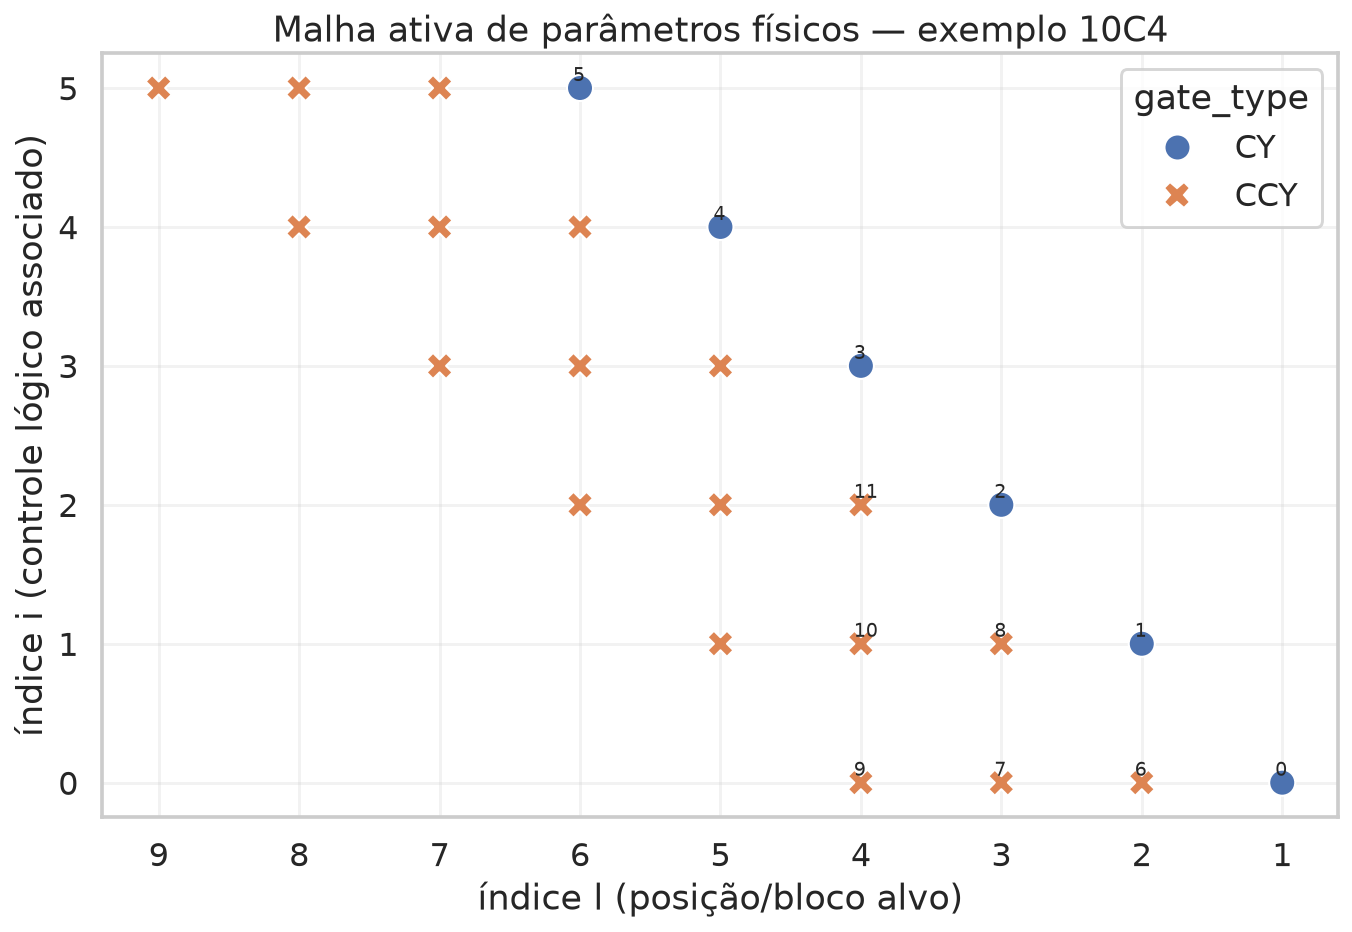

,parameter_index,l,i,gate_type,period
0,0,1,0,CY,12.566371
1,1,2,1,CY,12.566371
2,2,3,2,CY,12.566371
3,3,4,3,CY,12.566371
4,4,5,4,CY,12.566371
5,5,6,5,CY,12.566371
6,6,2,0,CCY,6.283185
7,7,3,0,CCY,6.283185
8,8,3,1,CCY,6.283185
9,9,4,0,CCY,6.283185


In [6]:

# Visualização da malha ativa de parâmetros para um exemplo-base.
example_n, example_k = REGIMES[0]
example_structure = BUNDLES[(example_n, example_k)]["structure"].copy()
example_structure["parameter_index"] = np.arange(len(example_structure))

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=example_structure,
    x="l",
    y="i",
    hue="gate_type",
    style="gate_type",
    s=180,
    ax=ax,
)

for row in example_structure.head(12).itertuples(index=False):
    ax.text(
        row.l + 0.05,
        row.i + 0.05,
        str(int(row.parameter_index)),
        fontsize=10,
    )

ax.set_title(
    f"Malha ativa de parâmetros físicos — exemplo {example_n}C{example_k}"
)
ax.set_xlabel("índice l (posição/bloco alvo)")
ax.set_ylabel("índice i (controle lógico associado)")
ax.invert_xaxis()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(
    PRESENTATION_FIG_DIR / "active_parameter_lattice.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

display(
    example_structure[["parameter_index", "l", "i", "gate_type", "period"]].head(15)
)


### Como ler a malha ativa $(l,i)$

Cada ponto é um parâmetro físico ativo do ansatz.

- O eixo $l$ identifica a posição/bloco alvo da etapa.
- O eixo $i$ identifica o controle lógico associado.
- A combinação $(l,i)$ determina qual relação de redistribuição de amplitude
  está sendo parametrizada.
- `CY` aparece quando $i=l-1$; `CCY` quando $i<l-1$.

Para $10C4$, o número esperado de parâmetros ativos é

$$
d=k(n-k)=4(10-4)=24.
$$

Portanto o gráfico não mostra apenas “pontos do circuito”: ele é a representação
visual das **24 coordenadas físicas** nas quais o Jacobiano e os deslocamentos
$\Delta\theta$ serão definidos.


## 4. Jacobiano no ponto de Dicke: como ele é construído?

O Jacobiano local é a peça central do método.

Para cada bitstring viável $x$ e cada parâmetro ativo $j$, medimos como a probabilidade muda localmente quando perturbamos o parâmetro:

$$
J_D(x,j)
=
\left.
\frac{\partial p_\phi(x)}{\partial \phi_j}
\right|_{\phi=\phi_D}.
$$

### Como ler essa matriz

- **linhas** $\to$ bitstrings viáveis;
- **colunas** $\to$ parâmetros físicos ativos;
- **entrada** $J_D(x,j)$ $\to$ sensibilidade local da probabilidade do bitstring $x$ ao parâmetro $j$.

Assim, o Jacobiano transforma o circuito em um objeto geométrico mensurável.

### Exemplo conceitual

Se tivermos 6 bitstrings viáveis e 4 parâmetros ativos, então:

$$
J_D \in \mathbb{R}^{6\times4}.
$$

A coluna $j$ mostra **para quais bitstrings** o parâmetro $j$ empurra probabilidade.
A linha $x$ mostra **quais parâmetros** afetam mais aquele bitstring.


### Como uma entrada do Jacobiano pode ser entendida numericamente?

Mesmo quando o código usa JVP/autodiferenciação para eficiência, a interpretação
de uma entrada é a mesma de uma diferença finita.

Para o parâmetro $j$:

$$
J_D(x,j)
\approx
\frac{
p_{\phi_D+\varepsilon e_j}(x)
-
p_{\phi_D-\varepsilon e_j}(x)
}{
2\varepsilon
}.
$$

Aqui:

- $e_j$ é o vetor unitário que perturba somente o parâmetro $j$;
- $\varepsilon$ é uma perturbação pequena;
- o numerador mede quanto a probabilidade do bitstring $x$ muda;
- dividir por $2\varepsilon$ transforma essa diferença numa derivada local.

#### Exemplo numérico simples

Suponha que para um bitstring particular:

$$
p_{\phi_D+\varepsilon e_2}(x)=0.172,
$$

$$
p_{\phi_D-\varepsilon e_2}(x)=0.168,
$$

com

$$
\varepsilon=0.01.
$$

Então:

$$
J_D(x,2)
\approx
\frac{0.172-0.168}{0.02}
=
0.20.
$$

Isso significa que, localmente, aumentar o parâmetro 2 tende a **aumentar**
a probabilidade daquele bitstring.

Se o resultado fosse negativo, o mesmo parâmetro tenderia a retirar massa de
probabilidade desse estado.


In [7]:
# =====================================================================
# MAPA MATEMÁTICO DESTA CÉLULA — ENERGIA -> QR -> DIREÇÃO GEOMÉTRICA
# =====================================================================
# [F1] Normalização da energia:
#      z = (E - <E>) / (ORTHO_Z_SCALE * std(E))
#
# [F2] Features de energia:
#      F_Q(E) = [P_1(z), ..., P_Q(z)]
#      onde P_j são polinômios de Legendre.
#
# [B1] Acoplamento geometria-energia:
#      B_H = J_D^T F_Q(E)
#
# [QR1] Ortogonalização:
#      A = B_H D^{-1} = Q_H R_H
#      com D contendo as normas das colunas de B_H.
#
# [G1] Direção geométrica:
#      d_H = normalize(Q_H a_frozen)
#
# "a_frozen" é fixo; Q_H muda com o Hamiltoniano.
# Portanto a direção física continua sendo Hamiltoniano-dependente.
# =====================================================================

def energy_features(E,q=Q_GEOM):
    E=np.asarray(E,float)

    x=(
        E-E.mean()
    )/max(
        ORTHO_Z_SCALE*E.std(),
        1e-12,
    )

    F=legvander(
        x,
        int(q),
    )[:,1:]

    return (
        F
        -F.mean(
            axis=0,
            keepdims=True,
        )
    )


def canonical_qr_from_B(B):
    B=np.asarray(
        B,
        float,
    )

    norms=np.linalg.norm(
        B,
        axis=0,
    )

    if np.any(
        norms<=1e-14
    ):
        return None

    A=(
        B
        /norms[
            None,:
        ]
    )

    if np.linalg.matrix_rank(
        A,
        tol=1e-11
    )<A.shape[1]:
        return None

    Q,R=np.linalg.qr(
        A,
        mode="reduced",
    )

    for j in range(
        Q.shape[1]
    ):
        if float(
            Q[:,j]
            @A[:,j]
        )<0:
            Q[:,j]*=-1.0
            R[j,:]*=-1.0

    return {
        "Q":Q,
        "R":R,
        "A":A,
        "norms":norms,
    }


def exact_directions(problem):
    J=problem.J
    E=problem.E

    gE=J.T@E

    d_energy=(
        -normalize(
            gE
        )
    )

    F=energy_features(
        E,
        Q_GEOM,
    )

    B=J.T@F

    qr=canonical_qr_from_B(
        B
    )

    if qr is None:
        raise RuntimeError(
            f"QR geometry unavailable for {problem.problem_id}"
        )

    Q=qr[
        "Q"
    ]

    d_frozen=normalize(
        Q@FROZEN_A_Q10
    )

    gP=(
        J.T
        @problem.opt_mask.astype(float)
    )

    projected=(
        Q@(
            Q.T@gP
        )
    )

    d_oracle=normalize(
        projected
    )

    return {
        "gE":gE,
        "F":F,
        "B":B,
        "Q":Q,
        "d_energy":d_energy,
        "d_frozen":d_frozen,
        "d_oracle":d_oracle,
        "gP":gP,
    }


DIRECTION_CACHE={
    p.problem_id:exact_directions(p)
    for p in PROBLEMS
}
print(
    "Exact direction cache:",
    len(DIRECTION_CACHE),
    "problems",
)

Exact direction cache: 64 problems


In [8]:
# =====================================================================
# MAPA MATEMÁTICO DESTA CÉLULA — ESTIMAÇÃO POR SHOTS
# =====================================================================
# Cada shot fornece um bitstring X_t.
#

# [S0] Equação geral do estimador geométrico por shots:
#
#      \hat B_H
#      =
#      (1/N) \sum_{t=1}^{N}
#      s_D(X_t)\,F_Q(E(X_t))^T
#
#      onde:
#      - N   = número total de shots;
#      - X_t = bitstring observado no shot t;
#      - s_D(X_t) = score local do Dicke naquele bitstring;
#      - E(X_t)   = energia do bitstring;
#      - F_Q(E)   = vetor de features de Legendre até ordem Q.
#
# [S0b] Depois do estimador:
#
#      \hat B_H -> QR -> \hat Q_H \hat R_H
#      \hat d_H = normalize(\hat Q_H a_frozen)
#
# Em palavras:
# 1) medimos bitstrings;
# 2) transformamos cada bitstring em informação de score + energia;
# 3) acumulamos isso numa estimativa de \hat B_H;
# 4) extraímos a base ortonormal \hat Q_H;
# 5) projetamos o vetor estrutural fixo a_frozen para obter a direção geométrica.

# [S1] Score local no Dicke:
#      s_D(X_t) = M * J_D[X_t,:]
#
# [S2] Gradiente de energia estimado:
#      gE_hat = (1/N) sum_t s_D(X_t) [E(X_t)-E_bar]
#
# [S3] Matriz geométrica estimada:
#      B_hat = (1/N) sum_t s_D(X_t) F_Q(E(X_t))^T
#
# [S4] Depois:
#      B_hat -> QR -> Q_hat
#      d_hat = normalize(Q_hat a_frozen)
#
# Assim, os shots são usados para estimar a DIREÇÃO geométrica.
# =====================================================================

def sample_energy_features(
    E_samples,
    q=Q_GEOM,
):
    """
    Build the Legendre feature matrix using ONLY the energies observed
    in the current shot sample.

    No population mean/std and no unobserved E(x) are consulted.
    """
    E_samples=np.asarray(
        E_samples,
        float,
    )

    mu_hat=float(
        E_samples.mean()
    )

    sigma_hat=float(
        E_samples.std(
            ddof=0
        )
    )

    x=(
        E_samples
        -mu_hat
    )/max(
        ORTHO_Z_SCALE
        *sigma_hat,
        1e-12,
    )

    F=legvander(
        x,
        int(q),
    )[:,1:]

    # Finite-sample centering is operational and also exploits E[s_D]=0.
    F=(
        F
        -F.mean(
            axis=0,
            keepdims=True,
        )
    )

    return {
        "F":F,
        "mu_hat":mu_hat,
        "sigma_hat":sigma_hat,
    }


def estimated_directions_from_samples(
    problem,
    sample_idx,
):
    M=len(
        problem.E
    )

    sample_idx=np.asarray(
        sample_idx,
        dtype=int,
    )

    N=len(
        sample_idx
    )

    score=(
        M
        *problem.J[
            sample_idx,
            :
        ]
    )

    E_sample=problem.E[
        sample_idx
    ]

    # Sample-only centering.
    Ecenter_sample=(
        E_sample
        -E_sample.mean()
    )

    gEhat=(
        score.T
        @Ecenter_sample
    )/N

    if np.linalg.norm(
        gEhat
    )<=1e-14:
        d_energy=None
    else:
        d_energy=-normalize(
            gEhat
        )

    feat=sample_energy_features(
        E_sample,
        Q_GEOM,
    )

    Fhat=feat[
        "F"
    ]

    Bhat=(
        score.T
        @Fhat
    )/N

    qr=canonical_qr_from_B(
        Bhat
    )

    if qr is None:
        d_frozen=None
    else:
        d_frozen=normalize(
            qr[
                "Q"
            ]
            @FROZEN_A_Q10
        )

    return {
        "d_energy":d_energy,
        "d_frozen":d_frozen,
        "mu_hat":feat[
            "mu_hat"
        ],
        "sigma_hat":feat[
            "sigma_hat"
        ],
    }

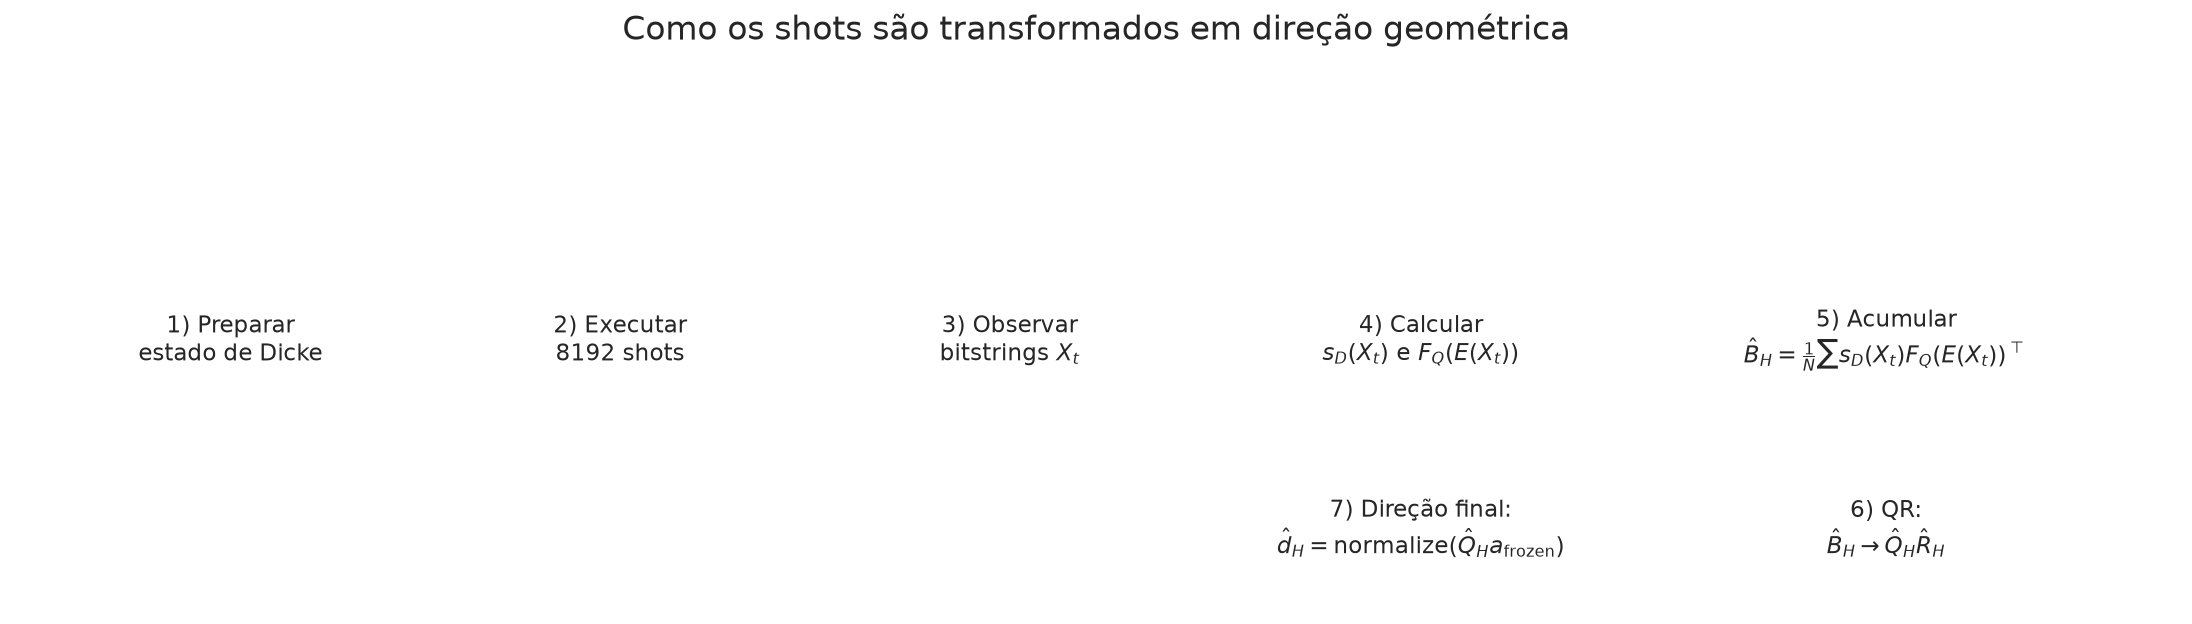

In [9]:
# =====================================================================
# FIGURA: PIPELINE DOS SHOTS -> GEOMETRIA
# =====================================================================
#
# Esta figura resume o fluxo matemático:
#
#    shots -> bitstrings X_t -> score + energia -> \hat B_H -> QR -> \hat d_H
#
# A ideia é deixar explícito como o mapeamento local é construído.
# =====================================================================

fig, ax = plt.subplots(figsize=(16, 4.8))
ax.axis("off")

boxes = [
    (0.03, 0.32, 0.14, 0.36, "1) Preparar\nestado de Dicke"),
    (0.21, 0.32, 0.14, 0.36, "2) Executar\n8192 shots"),
    (0.39, 0.32, 0.14, 0.36, "3) Observar\nbitstrings $X_t$"),
    (0.57, 0.32, 0.16, 0.36, "4) Calcular\n$s_D(X_t)$ e $F_Q(E(X_t))$"),
    (0.78, 0.32, 0.17, 0.36, "5) Acumular\n$\\hat B_H=\\frac{1}{N}\\sum s_D(X_t)F_Q(E(X_t))^\\top$"),
]
for x, y, w, h, label in boxes:
    rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=12)

# Arrows between main boxes
for x1, x2 in [(0.17,0.21), (0.35,0.39), (0.53,0.57), (0.73,0.78)]:
    ax.annotate("", xy=(x2, 0.5), xytext=(x1, 0.5), arrowprops=dict(arrowstyle="->", lw=2))

# Lower secondary boxes
rect = plt.Rectangle((0.78, 0.06), 0.17, 0.18, fill=False, linewidth=2)
ax.add_patch(rect)
ax.text(0.865, 0.15, "6) QR:\n$\\hat B_H\\to \\hat Q_H\\hat R_H$", ha="center", va="center", fontsize=12)

rect = plt.Rectangle((0.57, 0.06), 0.16, 0.18, fill=False, linewidth=2)
ax.add_patch(rect)
ax.text(0.65, 0.15, "7) Direção final:\n$\\hat d_H=\\mathrm{normalize}(\\hat Q_H a_{\\rm frozen})$", ha="center", va="center", fontsize=12)

ax.annotate("", xy=(0.865, 0.24), xytext=(0.865, 0.32), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(0.73, 0.15), xytext=(0.78, 0.15), arrowprops=dict(arrowstyle="->", lw=2))

ax.set_title("Como os shots são transformados em direção geométrica", fontsize=17, pad=16)

fig.tight_layout()
fig.savefig(PRESENTATION_FIG_DIR / "shots_to_geometry_pipeline.png", dpi=250, bbox_inches="tight")
plt.show()

### Como ler o fluxograma dos shots

A figura resume o papel dos shots sem esconder a matemática.

Os 8192 shots não servem para “testar várias soluções completas”.  
Eles servem para estimar o objeto

$$
\hat B_H
=
\frac{1}{N}\sum_{t=1}^{N}
s_D(X_t)\,F_Q(E(X_t))^\top.
$$

Cada shot produz um bitstring \(X_t\). Esse bitstring entra em duas frentes:

1. ele informa **qual foi o estado observado**;
2. ele informa **qual é a energia desse estado**.

A linha correspondente do Jacobiano fornece o score local \(s_D(X_t)\), e a energia fornece as features \(F_Q(E(X_t))\).  
A média dessas contribuições gera uma aproximação da estrutura local do Hamiltoniano ao redor do Dicke.

Depois disso:

$$
\hat B_H
\longrightarrow
\hat Q_H\hat R_H
\longrightarrow
\hat d_H.
$$

Portanto, os shots constroem o **mapa local do terreno**; a direção geométrica é a maneira compacta de transformar esse mapa em um deslocamento no espaço dos parâmetros.

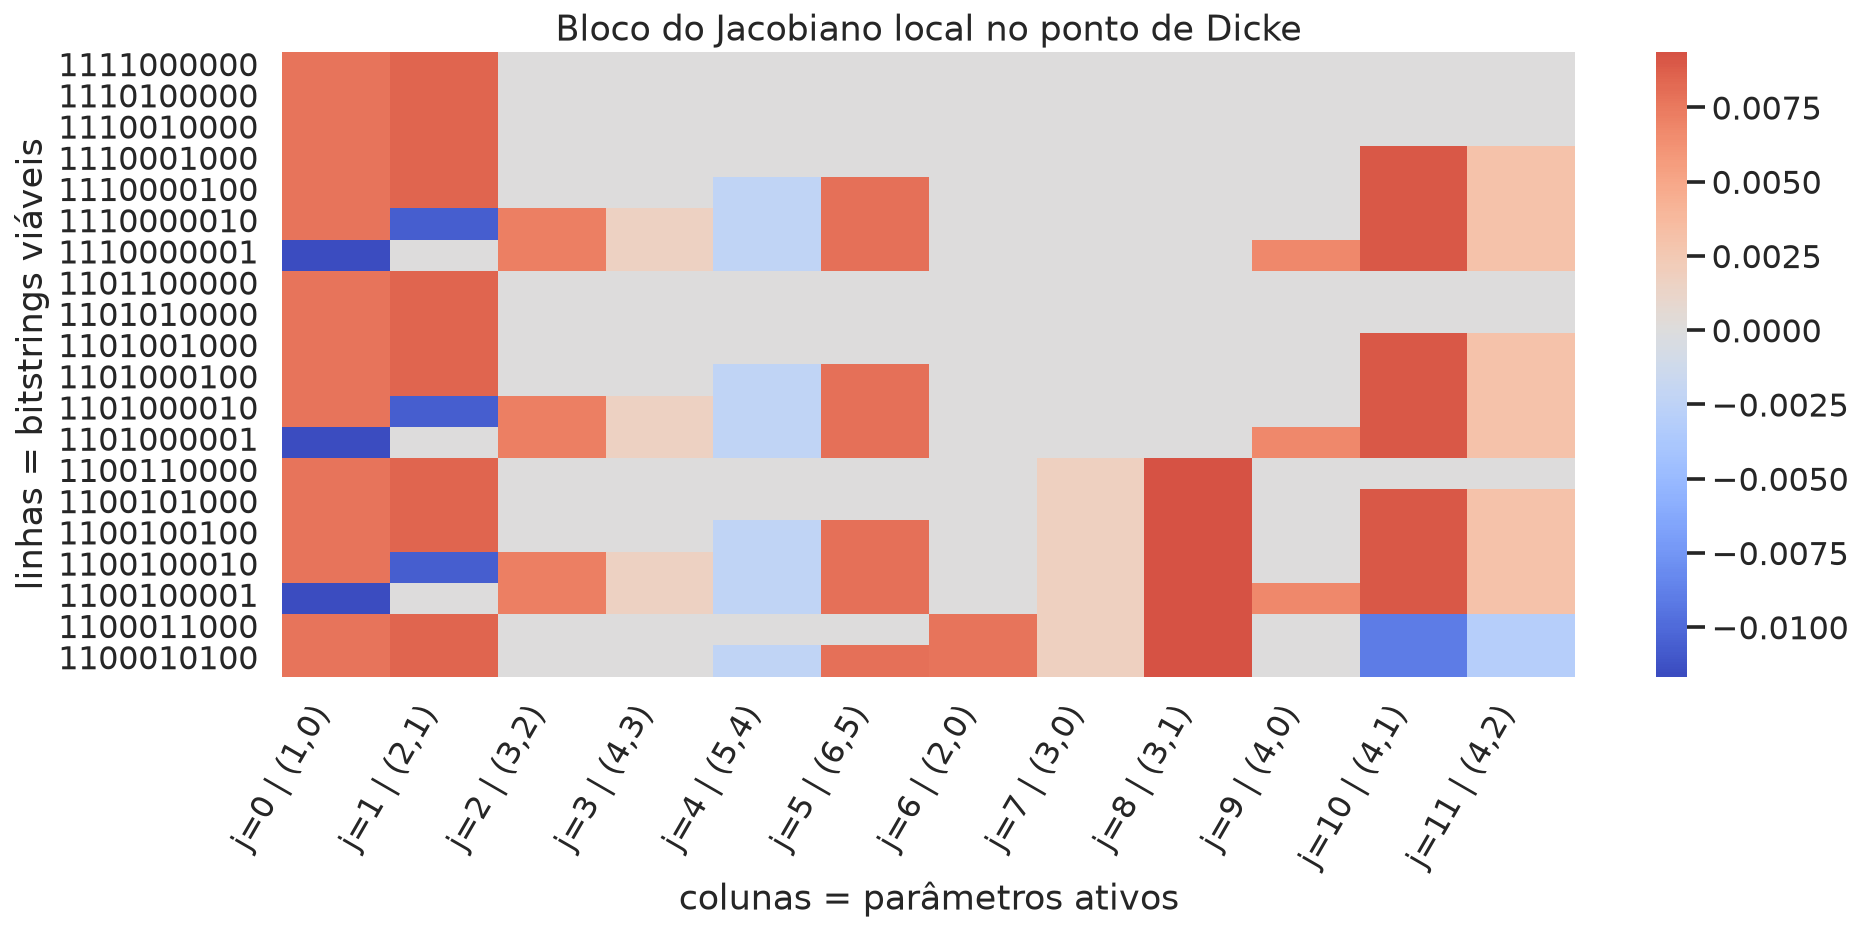

Dimensão do Jacobiano completo: (210, 24)


In [10]:

# Exemplo visual do Jacobiano para um problema representativo.
example_problem = next(p for p in PROBLEMS if p.n == example_n and p.k == example_k)
J_show = example_problem.J[:20, : min(12, example_problem.J.shape[1])]

bitstring_labels = ["".join(map(str, row.tolist())) for row in example_problem.X[:20]]
param_labels = [
    f"j={int(r.parameter_index)} | ({int(r.l)},{int(r.i)})"
    for r in example_structure.iloc[: min(12, len(example_structure))].itertuples(index=False)
]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    J_show,
    cmap="coolwarm",
    center=0,
    xticklabels=param_labels,
    yticklabels=bitstring_labels,
    ax=ax,
)
ax.set_title("Bloco do Jacobiano local no ponto de Dicke")
ax.set_xlabel("colunas = parâmetros ativos")
ax.set_ylabel("linhas = bitstrings viáveis")
plt.xticks(rotation=60, ha="right")
fig.tight_layout()
fig.savefig(
    PRESENTATION_FIG_DIR / "jacobian_block_heatmap.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

print("Dimensão do Jacobiano completo:", example_problem.J.shape)


### Como ler o heatmap do Jacobiano

O Jacobiano local é

$$
J_D(x,j)
=
\left.
\frac{\partial p_\phi(x)}
{\partial\phi_j}
\right|_{\phi=\phi_D}.
$$

No gráfico:

- cada **linha** é um bitstring factível;
- cada **coluna** é um parâmetro ativo $j$;
- cada célula mede a sensibilidade local da probabilidade daquele bitstring ao
  parâmetro.

Valor positivo significa que uma pequena perturbação positiva em $j$ tende a
aumentar $p(x)$; valor negativo significa que tende a reduzi-la.

O padrão de sinais é importante porque uma direção no espaço dos parâmetros não
move todos os bitstrings do mesmo modo: ela redistribui probabilidade de forma
estruturada.

### Como os 8192 shots constroem a direção geométrica

A etapa de shots estima a geometria **a partir de amostras do circuito preparado no ponto de Dicke**.

A equação central é

$$
\hat B_H
=
\frac{1}{N}\sum_{t=1}^{N}
s_D(X_t)\,F_Q(E(X_t))^\top.
$$

Aqui:

- \(N\) é o número total de shots;
- \(X_t\) é o bitstring observado no shot \(t\);
- \(s_D(X_t)\) é o **score local do Dicke** para esse bitstring;
- \(E(X_t)\) é a energia do bitstring;
- \(F_Q(E(X_t))\) é o vetor de features de Legendre calculado nessa energia;
- \(\hat B_H\) é a estimativa do objeto geométrico que será fatorado por QR.

A sequência completa é:

1. **Preparação do estado de Dicke.**  
   O circuito é montado com os ângulos de Dicke \(\phi_D\), produzindo uma distribuição de referência no subespaço factível.

2. **Execução de \(N=8192\) shots.**  
   Cada shot é uma execução do circuito seguida de medição.  
   O resultado de cada shot é um bitstring \(X_t\).

3. **Cálculo do score local.**  
   Para cada bitstring medido, o código consulta a linha correspondente do Jacobiano e monta

   $$
   s_D(X_t)=M\,J_D[X_t,:].
   $$

4. **Cálculo da energia e das features.**  
   O mesmo bitstring fornece sua energia \(E(X_t)\).  
   A partir dessa energia, o código monta

   $$
   F_Q(E(X_t))=
   \big(P_1(z_t),P_2(z_t),\dots,P_Q(z_t)\big),
   $$

   com \(z_t\) sendo a energia normalizada.

5. **Acúmulo das contribuições.**  
   Cada shot adiciona uma matriz de posto 1:

   $$
   s_D(X_t)\,F_Q(E(X_t))^\top.
   $$

   A média dessas matrizes gera \(\hat B_H\).

6. **Fatoração QR da matriz estimada.**  
   O código ortogonaliza \(\hat B_H\) e extrai \(\hat Q_H\).

7. **Construção da direção geométrica.**  
   Finalmente, o vetor estrutural fixo \(a_{\rm frozen}\) é projetado nessa base:

   $$
   \hat d_H=\mathrm{normalize}(\hat Q_H a_{\rm frozen}).
   $$

Em outras palavras, os 8192 shots são usados para **mapear o terreno local** do Hamiltoniano perto do ponto de Dicke.  
Eles não procuram diretamente o ótimo global; eles constroem a **direção informada** que desloca o circuito para uma região de probabilidade muito melhor.

### Como isso aparece no código

A lógica do código é:

- medir bitstrings;
- transformar bitstrings em score e energia;
- acumular \(\hat B_H\);
- fazer QR;
- converter isso em deslocamento geométrico.

Assim, a parte mais importante a observar no código não é apenas a chamada do simulador, mas o fato de que cada shot alimenta a expressão

$$
\hat B_H
=
\frac{1}{N}\sum_{t=1}^{N}
s_D(X_t)\,F_Q(E(X_t))^\top.
$$

Essa é a ponte entre “medir bitstrings” e “obter uma direção geométrica no espaço dos parâmetros”.


## 5. Features de energia, QR e o significado de $a$ congelado

A energia $E(x)$ de cada bitstring entra no método através de um conjunto de features ortogonais (aqui, polinômios de Legendre centralizados):

$$
F_Q(E) = [P_1(z),P_2(z),\ldots,P_Q(z)],
$$

onde $z$ é a energia normalizada.

A matriz modal é:

$$
B_H = J_D^\top F_Q(E).
$$

Depois fatoramos:

$$
B_H = Q_H R_H.
$$

O bloco $Q_H$ define uma base ortonormal de direções relevantes no espaço de parâmetros.

### O que significa usar $a$ congelado?

Chamamos de **$a$ congelado** um vetor fixo de pesos modais:

$$
a_{\rm frozen}\in\mathbb{R}^Q,
$$

que é mantido constante durante a etapa online.

A direção geométrica usada no espaço de parâmetros é então:

$$
d_H^{\rm geom}
=
\frac{Q_H a_{\rm frozen}}{\|Q_H a_{\rm frozen}\|_2}.
$$

Em linguagem simples:

> “congelado” significa que o envelope modal $a$ **não é reajustado para cada Hamiltoniano** na etapa online.
> O que muda de um problema para outro é a base $Q_H$, não o vetor estrutural $a_{\rm frozen}$.

Isso é importante porque separa duas coisas:

- a **estrutura universal** proposta pelo método ($a_{\rm frozen}$);
- a **adaptação local ao Hamiltoniano** (via $Q_H$).


### Exemplo simples do vetor $a$ congelado

Imagine, apenas para entender a mecânica, que $Q_H$ tenha três colunas:

$$
Q_H=
\begin{bmatrix}
|&|&|\\
q_1&q_2&q_3\\
|&|&|
\end{bmatrix}
$$

e que o vetor estrutural seja

$$
a_{\rm frozen}
=
(0.80,\,-0.50,\,0.30).
$$

A direção é:

$$
d_H
\propto
0.80\,q_1
-
0.50\,q_2
+
0.30\,q_3.
$$

Quando dizemos que $a$ está **congelado**, queremos dizer que os números

$$
0.80,\,-0.50,\,0.30
$$

não são reotimizados para cada novo Hamiltoniano.

O que muda é:

$$
Q_H.
$$

Portanto:

$$
\boxed{
\text{mesmos pesos estruturais}
+
\text{nova base adaptada ao Hamiltoniano}
=
\text{nova direção física}
}
$$

No experimento real usamos dez coeficientes, mas a interpretação é exatamente a
mesma.


In [11]:
# ======================================================================
# RESULTADOS OPERACIONAIS: DESCOBERTA AUTOMÁTICA + FALLBACK
# ======================================================================

def _candidate_result_roots():
    """Pastas plausíveis onde um benchmark completo pode ter sido executado."""
    roots=[
        OUTPUT_ROOT,
        Path.home()/"Desktop"/"v82105_paper1_operational_benchmark",
        Path.cwd()/"v82105_paper1_operational_benchmark",
        Path.cwd()/"geometry_benchmark_didactic",
    ]

    unique=[]
    seen=set()

    for root in roots:
        root=root.expanduser().resolve()

        if str(root) in seen:
            continue

        seen.add(
            str(root)
        )

        unique.append(
            root
        )

    return unique


RESULT_ROOT_CANDIDATES=_candidate_result_roots()

print(
    "Pastas pesquisadas para resultados:"
)

for root in RESULT_ROOT_CANDIDATES:
    print(
        " -",
        root,
    )


# ----------------------------------------------------------------------
# A. Recuperação finite-shot
# ----------------------------------------------------------------------
shot_candidates=[]

for root in RESULT_ROOT_CANDIDATES:
    candidate=(
        root
        /"data"
        /"finite_shot_direction_recovery.parquet"
    )

    if candidate.exists():
        shot_candidates.append(
            candidate
        )


if shot_candidates:
    SHOT_PATH=shot_candidates[0]

    print(
        "\nFinite-shot encontrado:",
        SHOT_PATH,
    )

    SHOT_DF=pd.read_parquet(
        SHOT_PATH
    )

else:
    print(
        "\nArquivo finite-shot não encontrado."
    )
    print(
        "Reconstruindo SOMENTE o necessário para a apresentação:"
    )
    print(
        f"  - método: FROZEN_QR_GEOMETRY"
    )
    print(
        f"  - shots: {GEOM_COMPARE_SHOTS}"
    )
    print(
        f"  - réplicas: {SHOT_REPLICATES}"
    )

    SHOT_ROWS=[]

    for p in tqdm(
        PROBLEMS,
        desc="reconstruindo geometria finite-shot",
    ):
        M=len(
            p.E
        )

        zero_delta=np.zeros(
            p.J.shape[1],
            float,
        )

        P0=float(
            exact_metrics(
                p,
                zero_delta,
            )[
                "Pstar"
            ]
        )

        exact_dir=np.asarray(
            DIRECTION_CACHE[
                p.problem_id
            ][
                "d_frozen"
            ],
            float,
        )

        exact_delta=modal_to_active(
            p,
            RHO_STEP
            *exact_dir,
        )

        P_exact=float(
            exact_metrics(
                p,
                exact_delta,
            )[
                "Pstar"
            ]
        )

        exact_gain=(
            P_exact
            -P0
        )

        for rep in range(
            SHOT_REPLICATES
        ):
            rg=np.random.default_rng(
                stable_int(
                    "direction-shots",
                    p.problem_id,
                    rep,
                    SEED,
                )
            )

            sample_idx=rg.integers(
                0,
                M,
                size=int(
                    GEOM_COMPARE_SHOTS
                ),
                endpoint=False,
            )

            est=estimated_directions_from_samples(
                p,
                sample_idx,
            )

            dhat=est[
                "d_frozen"
            ]

            if dhat is None:
                cosine=np.nan
                P_hat=np.nan
                self_ret=np.nan
                available=False

            else:
                dhat=np.asarray(
                    dhat,
                    float,
                )

                cosine=float(
                    dhat
                    @exact_dir
                )

                delta_active=modal_to_active(
                    p,
                    RHO_STEP
                    *dhat,
                )

                P_hat=float(
                    exact_metrics(
                        p,
                        delta_active,
                    )[
                        "Pstar"
                    ]
                )

                self_ret=(
                    (
                        P_hat
                        -P0
                    )
                    /exact_gain
                    if abs(
                        exact_gain
                    )>1e-14
                    else np.nan
                )

                available=True

            gate=bool(
                available
                and np.isfinite(
                    cosine
                )
                and np.isfinite(
                    self_ret
                )
                and cosine>=COS_GATE
                and self_ret>=RETENTION_GATE
            )

            SHOT_ROWS.append(
                {
                    "problem_id":p.problem_id,
                    "market":p.market,
                    "n":int(
                        p.n
                    ),
                    "k":int(
                        p.k
                    ),
                    "method":"FROZEN_QR_GEOMETRY",
                    "replicate":int(
                        rep
                    ),
                    "shots":int(
                        GEOM_COMPARE_SHOTS
                    ),
                    "available":bool(
                        available
                    ),
                    "cosine_to_exact_direction":cosine,
                    "Pstar_estimated_direction":P_hat,
                    "self_retention":self_ret,
                    "gate_cos_retention":gate,
                }
            )

    SHOT_DF=pd.DataFrame(
        SHOT_ROWS
    )

    SHOT_PATH=(
        PRESENTATION_DATA_DIR
        /"finite_shot_direction_recovery.parquet"
    )

    SHOT_DF.to_parquet(
        SHOT_PATH,
        index=False,
    )

    print(
        "Finite-shot reconstruído e salvo em:",
        SHOT_PATH,
    )


required_shot_columns={
    "problem_id",
    "method",
    "replicate",
    "shots",
    "available",
    "Pstar_estimated_direction",
}

missing_shot_cols=(
    required_shot_columns
    -set(
        SHOT_DF.columns
    )
)

if missing_shot_cols:
    raise RuntimeError(
        "Tabela finite-shot incompatível. "
        f"Colunas ausentes: {sorted(missing_shot_cols)}"
    )


# ----------------------------------------------------------------------
# B. Trajetórias VQE / multiotimizador
# ----------------------------------------------------------------------
cache_candidates=[]

for root in RESULT_ROOT_CANDIDATES:
    cache_dir=(
        root
        /"cache"
    )

    if not cache_dir.exists():
        continue

    cache_candidates.extend(
        list(
            cache_dir.glob(
                "vqe_runs__*__MULTIOPTv3__*.pkl"
            )
        )
    )


# Remove duplicatas de caminho.
cache_candidates=sorted(
    {
        p.resolve()
        for p in cache_candidates
    }
)


if not cache_candidates:
    raise FileNotFoundError(
        "\nNão encontrei o cache das trajetórias multiotimizador.\n\n"
        "O finite-shot da geometria já pode ser reconstruído automaticamente, "
        "mas os gráficos de catch-up de COBYLA/CMA-ES/Powell/SPSA precisam das "
        "trajetórias completas já calculadas.\n\n"
        "Procurei nas seguintes pastas:\n"
        +"\n".join(
            f"  - {root/'cache'}"
            for root in RESULT_ROOT_CANDIDATES
        )
        +"\n\n"
        "Se o benchmark foi salvo em outra pasta, defina antes de executar:\n"
        'os.environ["GEOM_OUTPUT_ROOT"] = "/caminho/para/v82105_paper1_operational_benchmark"'
    )


# O maior arquivo é, normalmente, a campanha completa.
VQE_CACHE=max(
    cache_candidates,
    key=lambda p:p.stat().st_size,
)

print(
    "\nCache multiotimizador encontrado:",
    VQE_CACHE,
)


with open(
    VQE_CACHE,
    "rb",
) as f:
    VQE_RUNS=pickle.load(
        f
    )


required_record_fields={
    "problem_id",
    "optimizer",
    "seed",
    "nfev",
    "optimization_shots",
    "selected_delta",
    "trajectory_audit",
    "population_size",
}


bad=[
    i
    for i,r in enumerate(
        VQE_RUNS
    )
    if not required_record_fields.issubset(
        set(
            r
        )
    )
]


if bad:
    raise RuntimeError(
        "Cache VQE incompatível. "
        f"Primeiros records problemáticos: {bad[:10]}"
    )


optimizer_preferred_order=[
    "COBYLA",
    "POWELL",
    "NELDER_MEAD",
    "SPSA",
    "CMAES",
]


present=set(
    r[
        "optimizer"
    ]
    for r in VQE_RUNS
)


OPTIMIZERS_PRESENT=[
    method
    for method in optimizer_preferred_order
    if method in present
]


VQE_SEEDS_PRESENT=sorted(
    {
        int(
            r[
                "seed"
            ]
        )
        for r in VQE_RUNS
    }
)


problem_ids={
    p.problem_id
    for p in PROBLEMS
}


cache_problem_ids={
    r[
        "problem_id"
    ]
    for r in VQE_RUNS
}


missing_problem_ids=sorted(
    problem_ids
    -cache_problem_ids
)


if missing_problem_ids:
    raise RuntimeError(
        "O cache VQE encontrado não cobre toda a coorte. "
        f"Primeiros problemas ausentes: {missing_problem_ids[:10]}"
    )


print(
    "Otimizadores disponíveis:",
    OPTIMIZERS_PRESENT,
)

print(
    "Seeds disponíveis:",
    VQE_SEEDS_PRESENT,
)

print(
    "Número de runs VQE carregados:",
    len(
        VQE_RUNS
    ),
)

Pastas pesquisadas para resultados:
 - /home/marlonmaxuel/Desktop/v82105_paper1_operational_benchmark
 - /home/marlonmaxuel/Desktop/geometry_benchmark_didactic

Finite-shot encontrado: /home/marlonmaxuel/Desktop/v82105_paper1_operational_benchmark/data/finite_shot_direction_recovery.parquet

Cache multiotimizador encontrado: /home/marlonmaxuel/Desktop/v82105_paper1_operational_benchmark/cache/vqe_runs__test_2025__P8__E128__S2048__R3__MULTIOPTv3__COBYLA-POWELL-NELDER_MEAD-SPSA-CMAES.pkl
Otimizadores disponíveis: ['COBYLA', 'POWELL', 'NELDER_MEAD', 'SPSA', 'CMAES']
Seeds disponíveis: [0, 1, 2]
Número de runs VQE carregados: 960



## 6. Shots: o que são e para que servem?

No experimento, não observamos diretamente toda a distribuição de probabilidade com custo zero.
Em vez disso, coletamos **shots**, isto é, amostras de medições do circuito.

Se o circuito foi medido $N$ vezes, obtemos uma amostra:

$$
X_1, X_2, \ldots, X_N.
$$

A partir dessas amostras, estimamos quantidades como:

- média da energia;
- variância da energia;
- features ortogonais amostrais;
- direção geométrica estimada $\widehat d_N$.

### Fórmula de score amostral

Se o score local é $s_D(x)$, então a versão amostral usa algo do tipo:

$$
\widehat B_H
\approx
\frac{1}{N}
\sum_{t=1}^N
s_D(X_t) F_Q(E(X_t)).
$$

Assim, **shots** são o orçamento estatístico que nos permite reconstruir, aproximadamente, a direção geométrica sem enumerar tudo.

### Exemplo simples

Se 8192 shots produzem uma direção suficientemente boa, então o custo operacional da geometria é de 8192 medições.
Se um VQE precisar de 86 avaliações, cada uma com 2048 shots, então o custo equivalente é:

$$
86\times2048 = 176128.
$$

Comparando com a geometria:

$$
\frac{176128}{8192}=21.5.
$$

Esse é exatamente o tipo de ganho que queremos tornar visível.


### Exemplo com poucos shots

Suponha um sistema $4C2$ e apenas oito medições:

| shot | bitstring | energia |
|---:|:---:|---:|
| 1 | 1100 | 0.42 |
| 2 | 1010 | 0.31 |
| 3 | 1100 | 0.42 |
| 4 | 0011 | 0.18 |
| 5 | 1010 | 0.31 |
| 6 | 0101 | 0.24 |
| 7 | 0011 | 0.18 |
| 8 | 0011 | 0.18 |

A média amostral seria:

$$
\widehat\mu_E
=
\frac{
0.42+0.31+0.42+0.18+0.31+0.24+0.18+0.18
}{8}.
$$

Os mesmos shots também selecionam linhas específicas do Jacobiano, isto é:

$$
J_D(X_1,:),\ldots,J_D(X_8,:).
$$

É essa combinação entre:

$$
\boxed{
\text{bitstring observado}
+
\text{energia observada}
+
\text{sensibilidade geométrica}
}
$$

que permite estimar a direção sem reconstruir toda a distribuição exatamente.


In [12]:
# =====================================================================
# MAPA MATEMÁTICO DESTA CÉLULA — CATCH-UP
# =====================================================================
# [C1] Alvo da geometria para cada Hamiltoniano:
#      P*_geom = mediana das réplicas finite-shot em 8192 shots.
#
# [C2] Primeiro instante em que um otimizador atinge esse alvo:
#      N_catch = min {N : P*_opt(N) >= P*_geom}
#
# [C3] Custo em shots:
#      shots_catch = N_catch * shots_por_avaliacao
#
# [C4] Razão de custo:
#      R_shots = shots_catch / 8192
#
# R_shots = 25 significa: o otimizador gastou 25 vezes mais shots
# para consultar pela primeira vez um ponto com qualidade >= geometria.
# =====================================================================

# Geometry target: median over shot replicates at a fixed 8192-shot budget.
GEOM_TARGET=(
    SHOT_DF[
        (
            SHOT_DF[
                "method"
            ]=="FROZEN_QR_GEOMETRY"
        )
        &(
            SHOT_DF[
                "shots"
            ]==GEOM_COMPARE_SHOTS
        )
    ]
    .groupby(
        [
            "problem_id",
            "market",
            "n",
            "k",
        ],
        as_index=False,
    )
    .agg(
        geometry_target_Pstar=(
            "Pstar_estimated_direction",
            "median",
        ),
        geometry_target_q25=(
            "Pstar_estimated_direction",
            lambda x:float(
                np.nanquantile(
                    np.asarray(
                        x,
                        float,
                    ),
                    0.25,
                )
            ),
        ),
        geometry_target_q75=(
            "Pstar_estimated_direction",
            lambda x:float(
                np.nanquantile(
                    np.asarray(
                        x,
                        float,
                    ),
                    0.75,
                )
            ),
        ),
        geometry_available_fraction=(
            "available",
            "mean",
        ),
    )
)

target_lookup={
    row.problem_id:float(
        row.geometry_target_Pstar
    )
    for row in GEOM_TARGET.itertuples(
        index=False
    )
}


def algorithmic_round_from_eval_count(
    record,
    eval_count,
):
    """
    Diagnostic round count.

    - SPSA: 2 objective queries per update.
    - CMA-ES: popsize queries per generation.
    - Other derivative-free methods: query count is reported as a conservative
      adaptive-query index; it is NOT claimed to equal accepted parameter updates.
    """
    optimizer=record[
        "optimizer"
    ]

    if optimizer=="SPSA":
        return int(
            math.ceil(
                eval_count/2
            )
        )

    if optimizer=="CMAES":
        pop=max(
            int(
                record.get(
                    "population_size",
                    1,
                )
            ),
            1,
        )

        return int(
            math.ceil(
                eval_count/pop
            )
        )

    return int(
        eval_count
    )


CATCH_ROWS=[]

for r in VQE_RUNS:
    pid=r[
        "problem_id"
    ]

    if pid not in target_lookup:
        continue

    target=target_lookup[
        pid
    ]

    traj=sorted(
        r[
            "trajectory_audit"
        ],
        key=lambda a:int(
            a[
                "eval"
            ]
        ),
    )

    first=None

    for a in traj:
        if float(
            a[
                "Pstar_exact"
            ]
        )>=target:
            first=a
            break

    if first is None:
        eval_count=np.nan
        catch_shots=np.nan
        ratio=np.nan
        round_count=np.nan
        caught=False
    else:
        eval_count=int(
            first[
                "eval"
            ]
        )+1

        catch_shots=int(
            eval_count
            *VQE_SHOTS_PER_EVAL
        )

        ratio=float(
            catch_shots
            /GEOM_COMPARE_SHOTS
        )

        round_count=algorithmic_round_from_eval_count(
            r,
            eval_count,
        )

        caught=True

    p=next(
        p
        for p in PROBLEMS
        if p.problem_id==pid
    )

    CATCH_ROWS.append(
        {
            "problem_id":pid,
            "market":p.market,
            "n":int(p.n),
            "k":int(p.k),
            "optimizer":r[
                "optimizer"
            ],
            "seed":int(
                r[
                    "seed"
                ]
            ),
            "geometry_target_Pstar":float(
                target
            ),
            "catchup_within_budget":bool(
                caught
            ),
            "catchup_eval_count":eval_count,
            "catchup_algorithmic_round":round_count,
            "catchup_shots":catch_shots,
            "catchup_shot_ratio_vs_geometry":ratio,
            "max_Pstar_queried":float(
                max(
                    a[
                        "Pstar_exact"
                    ]
                    for a in traj
                )
            ),
            "total_nfev":int(
                r[
                    "nfev"
                ]
            ),
        }
    )


CATCH_DF=pd.DataFrame(
    CATCH_ROWS
)

CATCH_SUMMARY=(
    CATCH_DF.groupby(
        [
            "n",
            "k",
            "optimizer",
        ],
        as_index=False,
    )
    .agg(
        runs=(
            "problem_id",
            "size",
        ),
        catchup_fraction=(
            "catchup_within_budget",
            "mean",
        ),
        median_catchup_evals=(
            "catchup_eval_count",
            "median",
        ),
        median_catchup_rounds=(
            "catchup_algorithmic_round",
            "median",
        ),
        median_catchup_shots=(
            "catchup_shots",
            "median",
        ),
        median_shot_ratio_vs_geometry=(
            "catchup_shot_ratio_vs_geometry",
            "median",
        ),
    )
)

GLOBAL_CATCH_SUMMARY=(
    CATCH_DF.groupby(
        "optimizer",
        as_index=False,
    )
    .agg(
        runs=(
            "problem_id",
            "size",
        ),
        catchup_fraction=(
            "catchup_within_budget",
            "mean",
        ),
        median_catchup_evals=(
            "catchup_eval_count",
            "median",
        ),
        median_catchup_rounds=(
            "catchup_algorithmic_round",
            "median",
        ),
        median_catchup_shots=(
            "catchup_shots",
            "median",
        ),
        median_shot_ratio_vs_geometry=(
            "catchup_shot_ratio_vs_geometry",
            "median",
        ),
    )
)

print(
    "GLOBAL CATCH-UP"
)
display(
    GLOBAL_CATCH_SUMMARY
)

print(
    "CATCH-UP BY REGIME"
)
display(
    CATCH_SUMMARY
)

CATCH_DF.to_csv(
    PRESENTATION_DATA_DIR/
    "catchup_runs.csv",
    index=False,
)

CATCH_SUMMARY.to_csv(
    PRESENTATION_DATA_DIR/
    "catchup_by_regime.csv",
    index=False,
)

GLOBAL_CATCH_SUMMARY.to_csv(
    PRESENTATION_DATA_DIR/
    "catchup_global.csv",
    index=False,
)

GLOBAL CATCH-UP


,optimizer,runs,catchup_fraction,median_catchup_evals,median_catchup_rounds,median_catchup_shots,median_shot_ratio_vs_geometry
0,CMAES,192,0.057292,86.0,7.0,176128.0,21.50
1,COBYLA,192,0.588542,86.0,86.0,176128.0,21.50
2,NELDER_MEAD,192,0.000000,NaN,NaN,NaN,NaN
3,POWELL,192,0.015625,107.0,107.0,219136.0,26.75
4,SPSA,192,0.015625,96.0,48.0,196608.0,24.00


CATCH-UP BY REGIME


,n,k,optimizer,runs,catchup_fraction,median_catchup_evals,median_catchup_rounds,median_catchup_shots,median_shot_ratio_vs_geometry
0,10,4,CMAES,48,0.041667,94.0,8.0,192512.0,23.50
1,10,4,COBYLA,48,0.645833,81.0,81.0,165888.0,20.25
2,10,4,NELDER_MEAD,48,0.000000,NaN,NaN,NaN,NaN
3,10,4,POWELL,48,0.000000,NaN,NaN,NaN,NaN
4,10,4,SPSA,48,0.000000,NaN,NaN,NaN,NaN
5,10,5,CMAES,48,0.062500,81.0,7.0,165888.0,20.25
6,10,5,COBYLA,48,0.645833,78.0,78.0,159744.0,19.50
7,10,5,NELDER_MEAD,48,0.000000,NaN,NaN,NaN,NaN
8,10,5,POWELL,48,0.020833,108.0,108.0,221184.0,27.00
9,10,5,SPSA,48,0.000000,NaN,NaN,NaN,NaN



## 7. Visualização direta do ganho: quantas vezes mais shots o VQE precisa?

A pergunta operacional aqui é:

> quantos shots cada otimizador precisa para **alcançar** a qualidade da geometria?

Definimos o fator de custo:

$$
R_{\rm shots}
=
\frac{N_{\rm shots}^{\rm catch}}{8192}.
$$

Interpretação:

- $R_{\rm shots}=1$  $\Rightarrow$ empata com a geometria;
- $R_{\rm shots}=5$  $\Rightarrow$ precisa de cinco vezes mais shots;
- $R_{\rm shots}=25$ $\Rightarrow$ precisa de vinte e cinco vezes mais shots.

A figura abaixo foi desenhada justamente para mostrar esse ganho **na cara**, sem depender de barras tradicionais.


### Como ler os gráficos desta seção

- **Painel da esquerda:** quanto custa em shots alcançar a geometria e com que frequência isso ocorre.
- **Painel da direita:** qual é a qualidade final do endpoint em termos de \(P_\star\).

Assim evitamos uma ambiguidade comum:
o **COBYLA é o melhor entre os otimizadores iterativos convencionais**, mas o **método geométrico continua sendo a referência**, porque entrega qualidade comparável com custo muito menor.


### O ponto central desta comparação

É possível que um otimizador iterativo obtenha um valor final de $P_\star$
ligeiramente maior em alguns casos. Isso **não significa automaticamente que
ele seja o método mais eficiente**.

A comparação deve considerar simultaneamente:

$$
\boxed{
\text{qualidade}
+
\text{custo em shots}
+
\text{frequência de sucesso}
}
$$

Por isso a figura desta seção usa dois painéis complementares:

1. **catch-up:** quantos shots são necessários para atingir a qualidade da geometria;
2. **qualidade × custo:** qual $P_\star$ é obtido e quanto custou chegar ao endpoint.

Essa leitura deixa explícito que COBYLA é o baseline iterativo mais competitivo,
enquanto a geometria ocupa a região de **alta qualidade e baixo custo**.


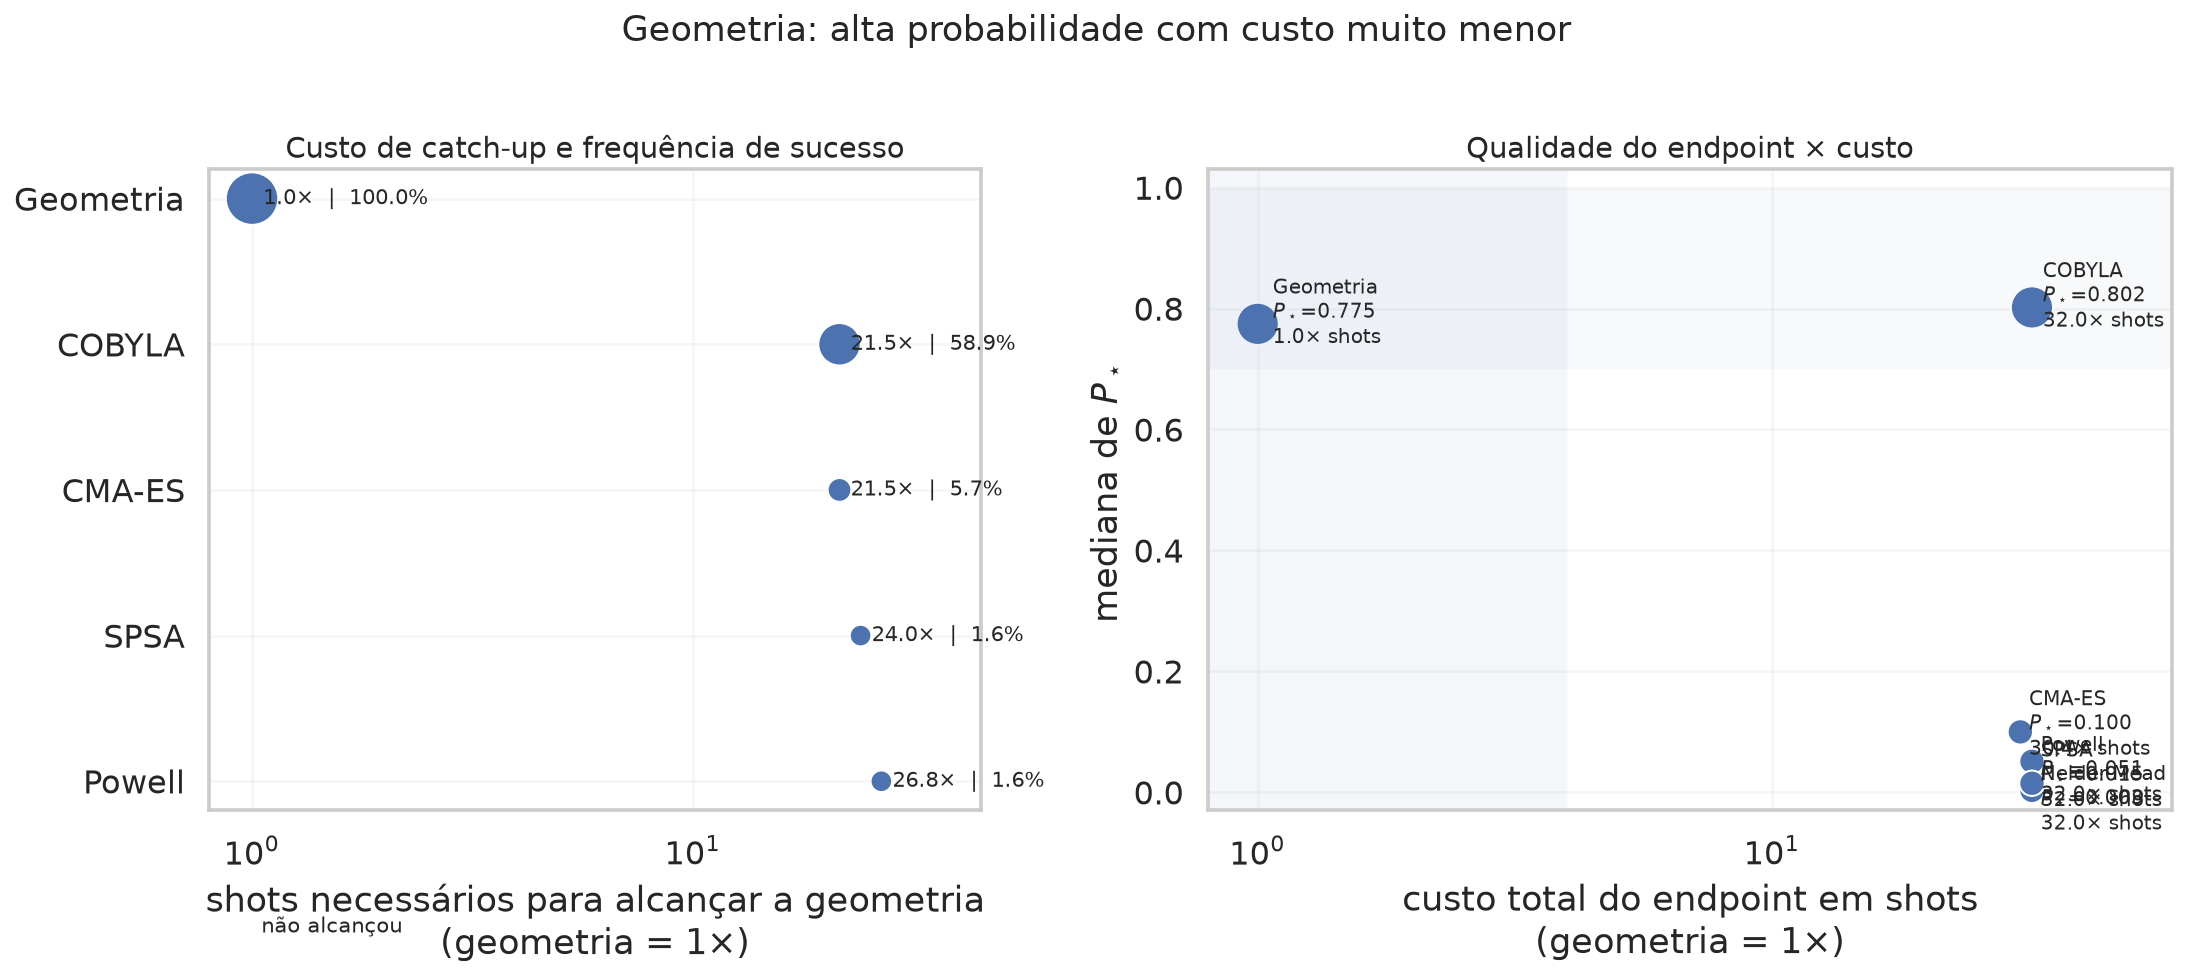

,method,runs,median_Pstar,q25_Pstar,q75_Pstar,median_shots,shot_ratio_vs_geometry
1,COBYLA,192,0.801802,0.246285,0.975902,262144.0,32.000
2,Geometria,64,0.774647,0.651811,0.832185,8192.0,1.000
0,CMA-ES,192,0.099797,0.035165,0.187914,248832.0,30.375
4,Powell,192,0.051095,0.028537,0.072522,262144.0,32.000
5,SPSA,192,0.014871,0.009075,0.024315,262144.0,32.000
3,Nelder-Mead,192,0.003065,0.002165,0.004168,262144.0,32.000


In [13]:
# =====================================================================
# FIGURA PRINCIPAL — CUSTO, CONSISTÊNCIA E QUALIDADE
# =====================================================================
#
# A intenção desta figura é evitar a interpretação errada:
# "COBYLA tem P* ligeiramente maior, logo é melhor".
#
# O endpoint deve ser lido JUNTO com o custo necessário para obtê-lo.
# =====================================================================

display_name_map = {
    "COBYLA": "COBYLA",
    "CMAES": "CMA-ES",
    "POWELL": "Powell",
    "SPSA": "SPSA",
    "NELDER_MEAD": "Nelder-Mead",
}

# ---------------------------------------------------------------------
# 1) Resumo de endpoint + custo total de otimização
# ---------------------------------------------------------------------
_problem_by_id = {
    p.problem_id: p
    for p in PROBLEMS
}

_endpoint_rows = []

# Geometria operacional:
# um valor por Hamiltoniano, com custo fixo de 8192 shots.
for row in GEOM_TARGET.itertuples(index=False):
    _endpoint_rows.append(
        {
            "problem_id": row.problem_id,
            "method": "Geometria",
            "Pstar": float(row.geometry_target_Pstar),
            "shots": int(GEOM_COMPARE_SHOTS),
        }
    )

# Otimizadores:
# usamos o endpoint salvo em cada run e o número real de shots consumidos.
for r in VQE_RUNS:
    _problem = _problem_by_id.get(
        r["problem_id"]
    )

    if _problem is None:
        continue

    _delta = np.asarray(
        r["selected_delta"],
        float,
    )

    _pstar = float(
        exact_metrics(
            _problem,
            _delta,
        )["Pstar"]
    )

    _endpoint_rows.append(
        {
            "problem_id": r["problem_id"],
            "method": display_name_map.get(
                r["optimizer"],
                r["optimizer"],
            ),
            "Pstar": _pstar,
            "shots": int(
                r["optimization_shots"]
            ),
        }
    )

ENDPOINT_PRESENTATION_DF = pd.DataFrame(
    _endpoint_rows
)

GLOBAL_ENDPOINT_SUMMARY = (
    ENDPOINT_PRESENTATION_DF
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        runs=("problem_id", "size"),
        median_Pstar=("Pstar", "median"),
        q25_Pstar=("Pstar", lambda s: float(np.quantile(s, 0.25))),
        q75_Pstar=("Pstar", lambda s: float(np.quantile(s, 0.75))),
        median_shots=("shots", "median"),
    )
)

GLOBAL_ENDPOINT_SUMMARY[
    "shot_ratio_vs_geometry"
] = (
    GLOBAL_ENDPOINT_SUMMARY[
        "median_shots"
    ]
    /float(
        GEOM_COMPARE_SHOTS
    )
)

# ---------------------------------------------------------------------
# 2) Tabela de catch-up para apresentação
# ---------------------------------------------------------------------
CATCH_PRESENTATION_DF = GLOBAL_CATCH_SUMMARY.copy()

CATCH_PRESENTATION_DF[
    "method"
] = CATCH_PRESENTATION_DF[
    "optimizer"
].map(
    lambda x: display_name_map.get(
        x,
        x,
    )
)

# Adicionamos a geometria como referência explícita.
geom_catch = pd.DataFrame(
    {
        "method": ["Geometria"],
        "catchup_fraction": [1.0],
        "median_shot_ratio_vs_geometry": [1.0],
    }
)

catch_plot = pd.concat(
    [
        geom_catch,
        CATCH_PRESENTATION_DF[
            [
                "method",
                "catchup_fraction",
                "median_shot_ratio_vs_geometry",
            ]
        ],
    ],
    ignore_index=True,
)

method_order = [
    "Geometria",
    "COBYLA",
    "CMA-ES",
    "SPSA",
    "Powell",
    "Nelder-Mead",
]

catch_plot[
    "method"
] = pd.Categorical(
    catch_plot[
        "method"
    ],
    categories=method_order,
    ordered=True,
)

catch_plot = catch_plot.sort_values(
    "method"
)

# ---------------------------------------------------------------------
# 3) Figura
# ---------------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    gridspec_kw={
        "width_ratios": [1.0, 1.25]
    },
)

# ============================================================
# Painel A — catch-up
# Um ponto por método. Sem linhas. Sem legenda.
# ============================================================
ax = axes[0]

finite_catch = catch_plot[
    np.isfinite(
        catch_plot[
            "median_shot_ratio_vs_geometry"
        ]
    )
].copy()

sns.scatterplot(
    data=finite_catch,
    x="median_shot_ratio_vs_geometry",
    y="method",
    size="catchup_fraction",
    sizes=(120, 720),
    legend=False,
    ax=ax,
)

for row in finite_catch.itertuples(index=False):
    ax.text(
        float(row.median_shot_ratio_vs_geometry) * 1.06,
        row.method,
        (
            f"{row.median_shot_ratio_vs_geometry:.1f}×"
            f"  |  {100*row.catchup_fraction:.1f}%"
        ),
        va="center",
        fontsize=11,
    )

# Nelder-Mead nunca alcançou o alvo.
if "Nelder-Mead" in method_order:
    ax.text(
        1.05,
        "Nelder-Mead",
        "não alcançou",
        va="center",
        fontsize=11,
    )

ax.set_xscale(
    "log"
)
ax.set_xlim(
    0.8,
    45,
)
ax.set_xlabel(
    "shots necessários para alcançar a geometria\n"
    "(geometria = 1×)"
)
ax.set_ylabel("")
ax.set_title(
    "Custo de catch-up e frequência de sucesso",
    fontsize=15,
)
ax.grid(
    alpha=0.16,
)

# ============================================================
# Painel B — qualidade × custo total
# Aqui fica visualmente claro que COBYLA pode ter P* semelhante,
# mas custa dezenas de vezes mais.
# ============================================================
ax2 = axes[1]

cost_quality = GLOBAL_ENDPOINT_SUMMARY[
    GLOBAL_ENDPOINT_SUMMARY[
        "method"
    ].isin(
        method_order
    )
].copy()

cost_quality[
    "is_main"
] = cost_quality[
    "method"
].isin(
        [
            "Geometria",
            "COBYLA",
        ]
    )

sns.scatterplot(
    data=cost_quality,
    x="shot_ratio_vs_geometry",
    y="median_Pstar",
    size="is_main",
    sizes={
        False: 170,
        True: 470,
    },
    legend=False,
    ax=ax2,
)

# Offsets manuais para evitar sobreposição.
offsets = {
    "Geometria": (1.07, 0.018),
    "COBYLA": (1.05, 0.018),
    "CMA-ES": (1.04, 0.012),
    "Powell": (1.04, -0.015),
    "SPSA": (1.04, 0.012),
    "Nelder-Mead": (1.04, -0.015),
}

for row in cost_quality.itertuples(index=False):
    xmult, dy = offsets.get(
        row.method,
        (1.05, 0.01),
    )

    ax2.text(
        float(row.shot_ratio_vs_geometry) * xmult,
        float(row.median_Pstar) + dy,
        (
            f"{row.method}\n"
            f"$P_\\star$={row.median_Pstar:.3f}\n"
            f"{row.shot_ratio_vs_geometry:.1f}× shots"
        ),
        fontsize=10.5,
        va="center",
    )

# Região visual de alta qualidade e baixo custo.
ax2.axvspan(
    0.8,
    4.0,
    alpha=0.06,
)
ax2.axhspan(
    0.70,
    1.0,
    alpha=0.04,
)

ax2.set_xscale(
    "log"
)
ax2.set_xlim(
    0.8,
    max(
        60,
        float(
            cost_quality[
                "shot_ratio_vs_geometry"
            ].max()
        )*1.7,
    ),
)
ax2.set_ylim(
    -0.03,
    1.03,
)
ax2.set_xlabel(
    "custo total do endpoint em shots\n"
    "(geometria = 1×)"
)
ax2.set_ylabel(
    r"mediana de $P_\star$"
)
ax2.set_title(
    "Qualidade do endpoint × custo",
    fontsize=15,
)
ax2.grid(
    alpha=0.16,
)

fig.suptitle(
    "Geometria: alta probabilidade com custo muito menor",
    fontsize=18,
    y=1.01,
)

fig.tight_layout()

fig.savefig(
    PRESENTATION_FIG_DIR/
    "main_cost_quality_clean_v2.png",
    dpi=260,
    bbox_inches="tight",
)

plt.show()

display(
    GLOBAL_ENDPOINT_SUMMARY.sort_values(
        "median_Pstar",
        ascending=False,
    )
)

### O que o gráfico principal realmente demonstra

O painel de **catch-up** mede duas coisas ao mesmo tempo:

$$
R_{\rm shots}
=
\frac{\text{shots até alcançar a geometria}}{8192}
$$

e a fração de runs que efetivamente conseguiram isso.

Nesta execução:

- COBYLA alcançou o alvo geométrico em aproximadamente $58.9\%$ dos runs;
- entre os runs bem-sucedidos, o custo mediano foi aproximadamente $21.5\times$;
- CMA-ES, Powell e SPSA alcançaram o alvo apenas esporadicamente;
- Nelder–Mead não alcançou.

O painel **qualidade × custo** evita uma interpretação enganosa:
COBYLA tem mediana de endpoint ligeiramente maior,

$$
P_\star^{\rm COBYLA}\approx0.802,
$$

contra

$$
P_\star^{\rm geom}\approx0.775,
$$

mas consome aproximadamente

$$
32\times
$$

mais shots no endpoint completo.

Portanto a conclusão não é “COBYLA é pior em qualquer métrica”.
A conclusão é:

$$
\boxed{
\text{qualidade semelhante}
+
\text{custo drasticamente menor para a geometria}
}
$$

## 7.1 Um exemplo visual de $\approx 25\times$

No regime $11C6$, o catch-up mediano do COBYLA ocorre por volta de 100 avaliações.

Como cada avaliação usa 2048 shots:

$$
100\times2048
=
204800\;\text{shots}.
$$

A geometria usa:

$$
8192\;\text{shots}.
$$

Então:

$$
\frac{204800}{8192}
=
\boxed{25}.
$$

A figura abaixo mostra os dois custos no mesmo eixo multiplicativo.
Não é uma comparação do budget máximo: é o custo mediano de **catch-up**
naquele regime, condicionado aos runs que efetivamente alcançaram o alvo.

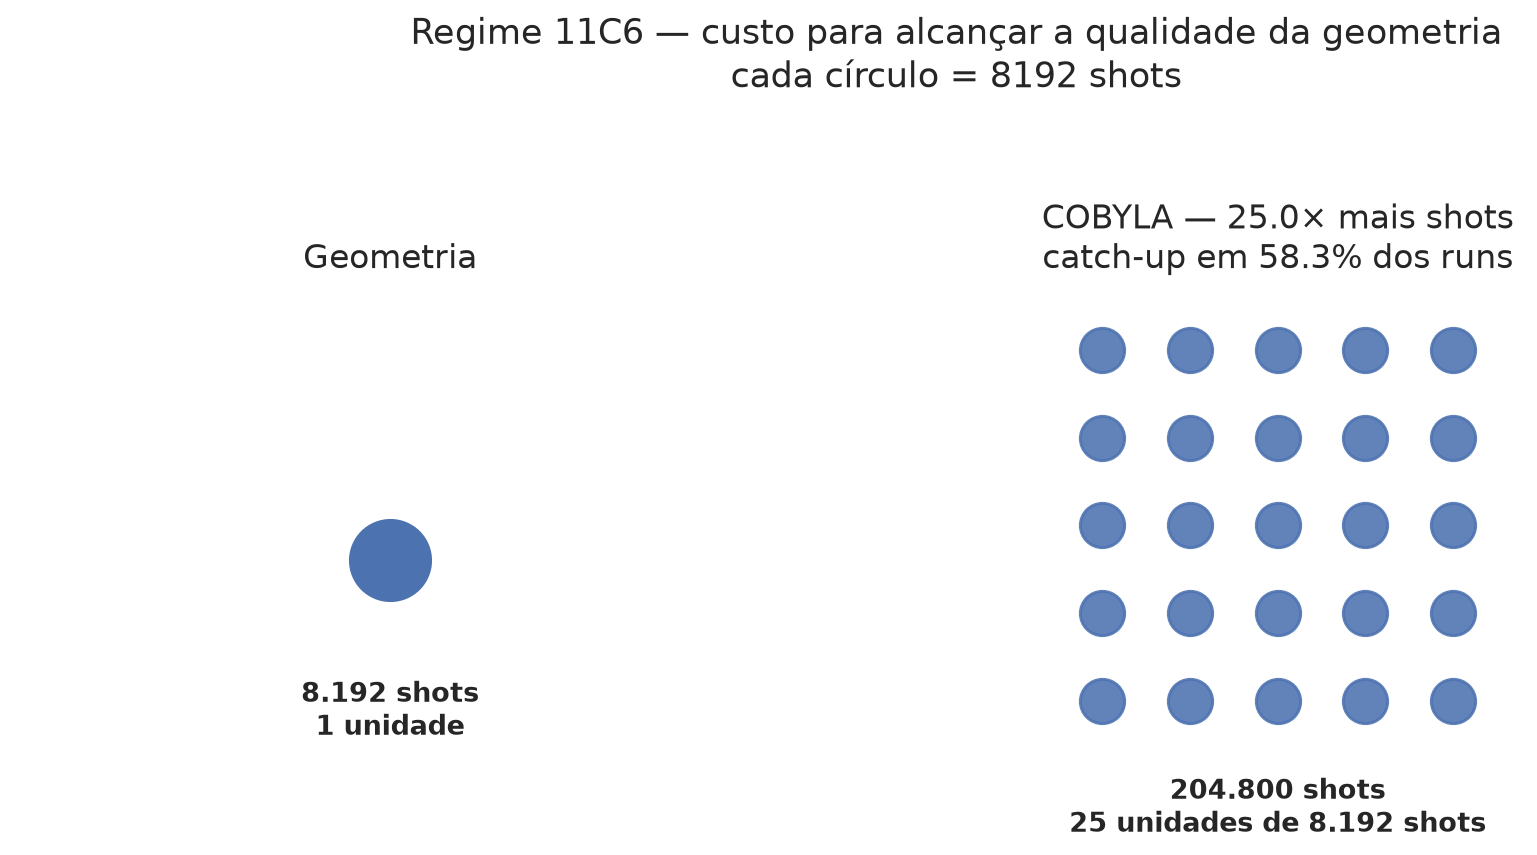

In [14]:
# =====================================================================
# FIGURA: 1 UNIDADE DE SHOTS DA GEOMETRIA vs ~25 UNIDADES DO COBYLA
# =====================================================================
#
# Relação matemática mostrada:
#
#   R_shots = shots_COBYLA / shots_geometria
#
# Para 11C6:
#   shots_geometria = 8192
#   shots_COBYLA    = N_catch * 2048
#
# Cada círculo abaixo representa UMA unidade de 8192 shots.
# Logo, ~25 círculos COBYLA representam ~25 vezes o custo da geometria.
# =====================================================================

target_row = CATCH_SUMMARY[
    (CATCH_SUMMARY["optimizer"] == "COBYLA")
    & (CATCH_SUMMARY["n"] == 11)
    & (CATCH_SUMMARY["k"] == 6)
].copy()

if len(target_row) == 1:
    actual_ratio = float(
        target_row.iloc[0][
            "median_shot_ratio_vs_geometry"
        ]
    )
    actual_catch = float(
        target_row.iloc[0][
            "catchup_fraction"
        ]
    )
    actual_shots = float(
        target_row.iloc[0][
            "median_catchup_shots"
        ]
    )

    # Número inteiro de unidades visuais.
    # No resultado atual 11C6, actual_ratio = 25.0.
    n_units = max(
        1,
        int(round(actual_ratio)),
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6),
        gridspec_kw={
            "width_ratios":[1, 1.65]
        },
    )

    # -------------------------------------------------------------
    # Geometria: uma única unidade.
    # -------------------------------------------------------------
    ax = axes[0]

    ax.scatter(
        [0],
        [0],
        s=1700,
    )

    ax.text(
        0,
        -0.42,
        (
            f"{int(GEOM_COMPARE_SHOTS):,} shots"
            .replace(",", ".")
            + "\n1 unidade"
        ),
        ha="center",
        va="top",
        fontsize=14,
        weight="bold",
    )

    ax.set_title(
        "Geometria",
        fontsize=17,
    )
    ax.set_xlim(
        -1,
        1,
    )
    ax.set_ylim(
        -1,
        1,
    )
    ax.axis(
        "off"
    )

    # -------------------------------------------------------------
    # COBYLA: cada ponto = uma unidade de 8192 shots.
    # Organizamos as unidades em uma grade quadrada.
    # -------------------------------------------------------------
    ax = axes[1]

    ncols = int(
        math.ceil(
            math.sqrt(
                n_units
            )
        )
    )

    coords = []

    for unit in range(
        n_units
    ):
        row = unit // ncols
        col = unit % ncols

        coords.append(
            (
                col,
                -row,
            )
        )

    xs = [
        c[0]
        for c in coords
    ]

    ys = [
        c[1]
        for c in coords
    ]

    ax.scatter(
        xs,
        ys,
        s=520,
        alpha=0.88,
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_title(
        (
            f"COBYLA — {actual_ratio:.1f}× mais shots\n"
            f"catch-up em {100*actual_catch:.1f}% dos runs"
        ),
        fontsize=17,
    )

    ax.text(
        (ncols-1)/2,
        min(ys)-0.85,
        (
            f"{int(actual_shots):,} shots"
            .replace(",", ".")
            +
            f"\n{n_units} unidades de {int(GEOM_COMPARE_SHOTS):,} shots"
            .replace(",", ".")
        ),
        ha="center",
        va="top",
        fontsize=14,
        weight="bold",
    )

    ax.set_xlim(
        -0.8,
        ncols-0.2,
    )
    ax.set_ylim(
        min(ys)-1.6,
        0.8,
    )
    ax.axis(
        "off"
    )

    fig.suptitle(
        (
            "Regime 11C6 — custo para alcançar a qualidade da geometria\n"
            "cada círculo = 8192 shots"
        ),
        fontsize=18,
        y=1.03,
    )

    fig.tight_layout()

    fig.savefig(
        PRESENTATION_FIG_DIR/
        "gain_25x_unit_chart.png",
        dpi=260,
        bbox_inches="tight",
    )

    plt.show()

else:
    print(
        "Regime 11C6 / COBYLA não disponível para o destaque de ~25×."
    )

### O que significa visualmente o ganho de $25\times$

Nesta figura, **cada círculo representa 8192 shots**, isto é, o custo usado pela
geometria.

No regime $11C6$:

$$
N_{\rm catch}^{\rm COBYLA}=100
$$

avaliações medianas entre os runs que alcançaram o alvo. Como cada avaliação usa

$$
2048\ \text{shots},
$$

temos:

$$
100\times2048=204800\ \text{shots}.
$$

Dividindo pelo custo geométrico:

$$
\frac{204800}{8192}
=
\boxed{25}.
$$

Por isso um círculo representa a geometria e os 25 círculos representam o custo
mediano de catch-up do COBYLA.

A figura deve ser interpretada junto com a taxa de sucesso: em $11C6$, COBYLA
alcançou o alvo em cerca de $58.3\%$ dos runs.


## 8. Comparando o perfil de probabilidade sobre os bitstrings

Agora queremos uma figura intuitiva que responda:

> a geometria realmente concentra massa de probabilidade perto do bitstring ótimo?

Para isso, escolhemos um problema representativo e mostramos, para cada método:

- a probabilidade de cada bitstring viável;
- o bitstring ótimo destacado com uma estrela;
- a energia de cada bitstring em segundo eixo.

Essa figura costuma ser muito útil em apresentação porque mostra simultaneamente:

1. onde está a massa de probabilidade;
2. onde está o ótimo;
3. qual o relevo energético do problema.


In [15]:
# =====================================================================
# MAPA MATEMÁTICO DESTA CÉLULA — ESTRUTURA DOS THETAS
# =====================================================================
# [T1] Conversão da fase interna para ângulo físico:
#      theta = periodo * phi / (2*pi)
#
# [T2] Peso quadrático de cada parâmetro:
#      w_j = DeltaTheta_j^2 / sum_l DeltaTheta_l^2
#
# [T3] N90:
#      N90 = menor m tal que sum_{j=1}^m w_(j) >= 0.90
#
# [T4] Dimensão efetiva:
#      d_eff = (sum_j DeltaTheta_j^2)^2 / sum_j DeltaTheta_j^4
#
# N90 mede quantos parâmetros carregam 90% da amplitude quadrática.
# d_eff mede a concentração global do deslocamento.
# =====================================================================

def problem_lookup(problem_id):
    matches=[
        p
        for p in PROBLEMS
        if p.problem_id==problem_id
    ]

    if len(matches)!=1:
        raise RuntimeError(
            f"Expected one problem for {problem_id}; found {len(matches)}."
        )

    return matches[0]


def vqe_record_lookup(
    problem_id,
    optimizer,
    seed,
):
    matches=[
        r
        for r in VQE_RUNS
        if (
            r[
                "problem_id"
            ]==problem_id
            and r[
                "optimizer"
            ]==optimizer
            and int(
                r[
                    "seed"
                ]
            )==int(seed)
        )
    ]

    if len(matches)!=1:
        raise RuntimeError(
            f"Expected one VQE record for "
            f"{problem_id}/{optimizer}/seed={seed}; found {len(matches)}."
        )

    return matches[0]


def geometry_delta_for_problem(
    problem,
    shots=GEOM_COMPARE_SHOTS,
    replicate=GEOM_THETA_REPLICATE,
):
    rg=np.random.default_rng(
        stable_int(
            "direction-shots",
            problem.problem_id,
            int(replicate),
            SEED,
        )
    )

    stream=rg.integers(
        0,
        len(
            problem.E
        ),
        size=int(
            shots
        ),
        endpoint=False,
    )

    est=estimated_directions_from_samples(
        problem,
        stream,
    )

    d=est[
        "d_frozen"
    ]

    if d is None:
        raise RuntimeError(
            f"Geometry direction unavailable for {problem.problem_id}."
        )

    return modal_to_active(
        problem,
        RHO_STEP*np.asarray(
            d,
            float,
        ),
    )


def theta_state_from_delta(
    problem,
    delta_phi,
):
    bundle=BUNDLES[
        (
            problem.n,
            problem.k,
        )
    ]

    periods=bundle[
        "structure"
    ][
        "period"
    ].to_numpy(float)

    phi_D=np.asarray(
        PHI_D[
            (
                problem.n,
                problem.k,
            )
        ],
        float,
    )

    delta_phi=np.asarray(
        delta_phi,
        float,
    )

    phi_final=wrap_phase(
        phi_D
        +delta_phi
    )

    delta_phi_eff=wrap_phase(
        phi_final
        -phi_D
    )

    theta_D=(
        periods
        *phi_D
        /(2*np.pi)
    )

    theta_final=(
        periods
        *phi_final
        /(2*np.pi)
    )

    delta_theta=(
        periods
        *delta_phi_eff
        /(2*np.pi)
    )

    return {
        "theta_D":theta_D,
        "theta_final":theta_final,
        "delta_theta":delta_theta,
        "delta_phi_effective":delta_phi_eff,
        "periods":periods,
    }


def effective_dimension(v):
    v=np.asarray(
        v,
        float,
    )

    q2=float(
        np.sum(
            v*v
        )
    )

    q4=float(
        np.sum(
            v**4
        )
    )

    return (
        float(
            q2*q2/q4
        )
        if q4>1e-30
        else 0.0
    )


def n90_theta(v):
    v=np.asarray(
        v,
        float,
    )

    power=v*v
    total=float(
        power.sum()
    )

    if total<=1e-30:
        return 0

    order=np.argsort(
        -power,
        kind="mergesort",
    )

    cumulative=np.cumsum(
        power[
            order
        ]
    )/total

    return int(
        np.searchsorted(
            cumulative,
            0.90,
        )+1
    )


def top_m_quadratic_share(v,m):
    v=np.asarray(
        v,
        float,
    )

    power=v*v
    total=float(
        power.sum()
    )

    if total<=1e-30:
        return 0.0

    order=np.argsort(
        -power,
        kind="mergesort",
    )

    return float(
        power[
            order[
                :min(
                    int(m),
                    len(v),
                )
            ]
        ].sum()
        /total
    )


def theta_weight_vector(v):
    v=np.asarray(
        v,
        float,
    )

    w=v*v
    total=float(
        w.sum()
    )

    if total<=1e-30:
        return np.zeros_like(
            w
        )

    return w/total


THETA_FULL_ROWS=[]
GEOMETRY_THETA_BY_PROBLEM={}

for p in tqdm(
    PROBLEMS,
    desc="full-cohort theta metrics",
):
    geom_delta=geometry_delta_for_problem(
        p
    )

    geom_theta=theta_state_from_delta(
        p,
        geom_delta,
    )[
        "delta_theta"
    ]

    GEOMETRY_THETA_BY_PROBLEM[
        p.problem_id
    ]=np.asarray(
        geom_theta,
        float,
    )

    endpoint_specs=[
        (
            f"GEOMETRY_{GEOM_COMPARE_SHOTS}_SHOTS",
            GEOM_THETA_REPLICATE,
            geom_delta,
        )
    ]

    for optimizer in OPTIMIZERS_PRESENT:
        for seed in VQE_SEEDS_PRESENT:
            r=vqe_record_lookup(
                p.problem_id,
                optimizer,
                seed,
            )

            endpoint_specs.append(
                (
                    optimizer,
                    int(seed),
                    np.asarray(
                        r[
                            "selected_delta"
                        ],
                        float,
                    ),
                )
            )

    for method,seed,delta in endpoint_specs:
        theta=theta_state_from_delta(
            p,
            delta,
        )[
            "delta_theta"
        ]

        theta=np.asarray(
            theta,
            float,
        )

        w=theta_weight_vector(
            theta
        )

        if method.startswith(
            "GEOMETRY_"
        ):
            overlap=1.0
        else:
            wg=theta_weight_vector(
                GEOMETRY_THETA_BY_PROBLEM[
                    p.problem_id
                ]
            )

            # Bhattacharyya overlap of the squared-amplitude support.
            overlap=float(
                np.sum(
                    np.sqrt(
                        wg*w
                    )
                )
            )

        THETA_FULL_ROWS.append(
            {
                "problem_id":p.problem_id,
                "market":p.market,
                "n":int(p.n),
                "k":int(p.k),
                "method":method,
                "seed":int(seed),
                "d_active":int(
                    len(theta)
                ),
                "theta_l1":float(
                    np.linalg.norm(
                        theta,
                        ord=1,
                    )
                ),
                "theta_l2":float(
                    np.linalg.norm(
                        theta
                    )
                ),
                "theta_linf":float(
                    np.max(
                        np.abs(
                            theta
                        )
                    )
                ),
                "theta_mean_abs":float(
                    np.mean(
                        np.abs(
                            theta
                        )
                    )
                ),
                "theta_effective_dimension":effective_dimension(
                    theta
                ),
                "theta_N90":int(
                    n90_theta(
                        theta
                    )
                ),
                "theta_top1_share":top_m_quadratic_share(
                    theta,
                    1,
                ),
                "theta_top3_share":top_m_quadratic_share(
                    theta,
                    3,
                ),
                "theta_top4_share":top_m_quadratic_share(
                    theta,
                    4,
                ),
                "theta_support_overlap_with_geometry":overlap,
            }
        )


THETA_FULL_DF=pd.DataFrame(
    THETA_FULL_ROWS
)

THETA_FULL_SUMMARY=(
    THETA_FULL_DF.groupby(
        [
            "n",
            "k",
            "method",
        ],
        as_index=False,
    )
    .agg(
        runs=(
            "problem_id",
            "size",
        ),
        median_theta_l2=(
            "theta_l2",
            "median",
        ),
        median_theta_linf=(
            "theta_linf",
            "median",
        ),
        median_deff=(
            "theta_effective_dimension",
            "median",
        ),
        median_N90=(
            "theta_N90",
            "median",
        ),
        median_top4_share=(
            "theta_top4_share",
            "median",
        ),
        median_overlap_with_geometry=(
            "theta_support_overlap_with_geometry",
            "median",
        ),
    )
)

GLOBAL_THETA_SUMMARY=(
    THETA_FULL_DF.groupby(
        "method",
        as_index=False,
    )
    .agg(
        runs=(
            "problem_id",
            "size",
        ),
        median_theta_l2=(
            "theta_l2",
            "median",
        ),
        median_theta_linf=(
            "theta_linf",
            "median",
        ),
        median_deff=(
            "theta_effective_dimension",
            "median",
        ),
        median_N90=(
            "theta_N90",
            "median",
        ),
        median_top4_share=(
            "theta_top4_share",
            "median",
        ),
        median_overlap_with_geometry=(
            "theta_support_overlap_with_geometry",
            "median",
        ),
    )
)

print(
    "GLOBAL THETA SUMMARY"
)
display(
    GLOBAL_THETA_SUMMARY
)

print(
    "THETA BY REGIME"
)
display(
    THETA_FULL_SUMMARY
)

THETA_FULL_DF.to_parquet(
    PRESENTATION_DATA_DIR/
    "theta_full_cohort_runs.parquet",
    index=False,
)

THETA_FULL_SUMMARY.to_csv(
    PRESENTATION_DATA_DIR/
    "theta_full_cohort_by_regime.csv",
    index=False,
)

GLOBAL_THETA_SUMMARY.to_csv(
    PRESENTATION_DATA_DIR/
    "theta_full_cohort_global.csv",
    index=False,
)

full-cohort theta metrics: 100%|██████████| 64/64 [00:00<00:00, 420.62it/s]

GLOBAL THETA SUMMARY


,method,runs,median_theta_l2,median_theta_linf,median_deff,median_N90,median_top4_share,median_overlap_with_geometry
0,CMAES,192,2.158225,1.052394,8.569091,13.0,0.571245,0.719868
1,COBYLA,192,3.366487,1.716205,8.875672,14.0,0.520797,0.807044
2,GEOMETRY_8192_SHOTS,64,2.823486,1.976972,3.576283,7.0,0.765838,1.000000
3,NELDER_MEAD,192,0.000252,0.000241,1.088100,1.0,0.988027,0.278706
4,POWELL,192,5.746219,4.094235,3.495572,6.0,0.834720,0.560741
5,SPSA,192,0.833313,0.394978,9.487682,13.0,0.540083,0.700129


THETA BY REGIME


,n,k,method,runs,median_theta_l2,median_theta_linf,median_deff,median_N90,median_top4_share,median_overlap_with_geometry
0,10,4,CMAES,48,2.299049,1.264896,7.453204,11.0,0.616015,0.745640
1,10,4,COBYLA,48,3.408957,1.903115,7.370654,13.0,0.568739,0.829101
2,10,4,GEOMETRY_8192_SHOTS,16,2.823067,2.002972,3.576283,7.0,0.784875,1.000000
3,10,4,NELDER_MEAD,48,0.000250,0.000232,1.166800,1.0,0.971580,0.299949
4,10,4,POWELL,48,5.828738,4.094235,3.482815,6.0,0.836623,0.598190
5,10,4,SPSA,48,0.877030,0.474986,6.739076,11.0,0.618084,0.747877
6,10,5,CMAES,48,2.143812,1.064668,8.488391,12.0,0.600862,0.757415
7,10,5,COBYLA,48,3.308678,1.647706,9.107939,13.0,0.523966,0.814352
8,10,5,GEOMETRY_8192_SHOTS,16,2.781954,1.887046,3.744247,7.0,0.771732,1.000000
9,10,5,NELDER_MEAD,48,0.000263,0.000240,1.249292,1.5,0.957507,0.309186


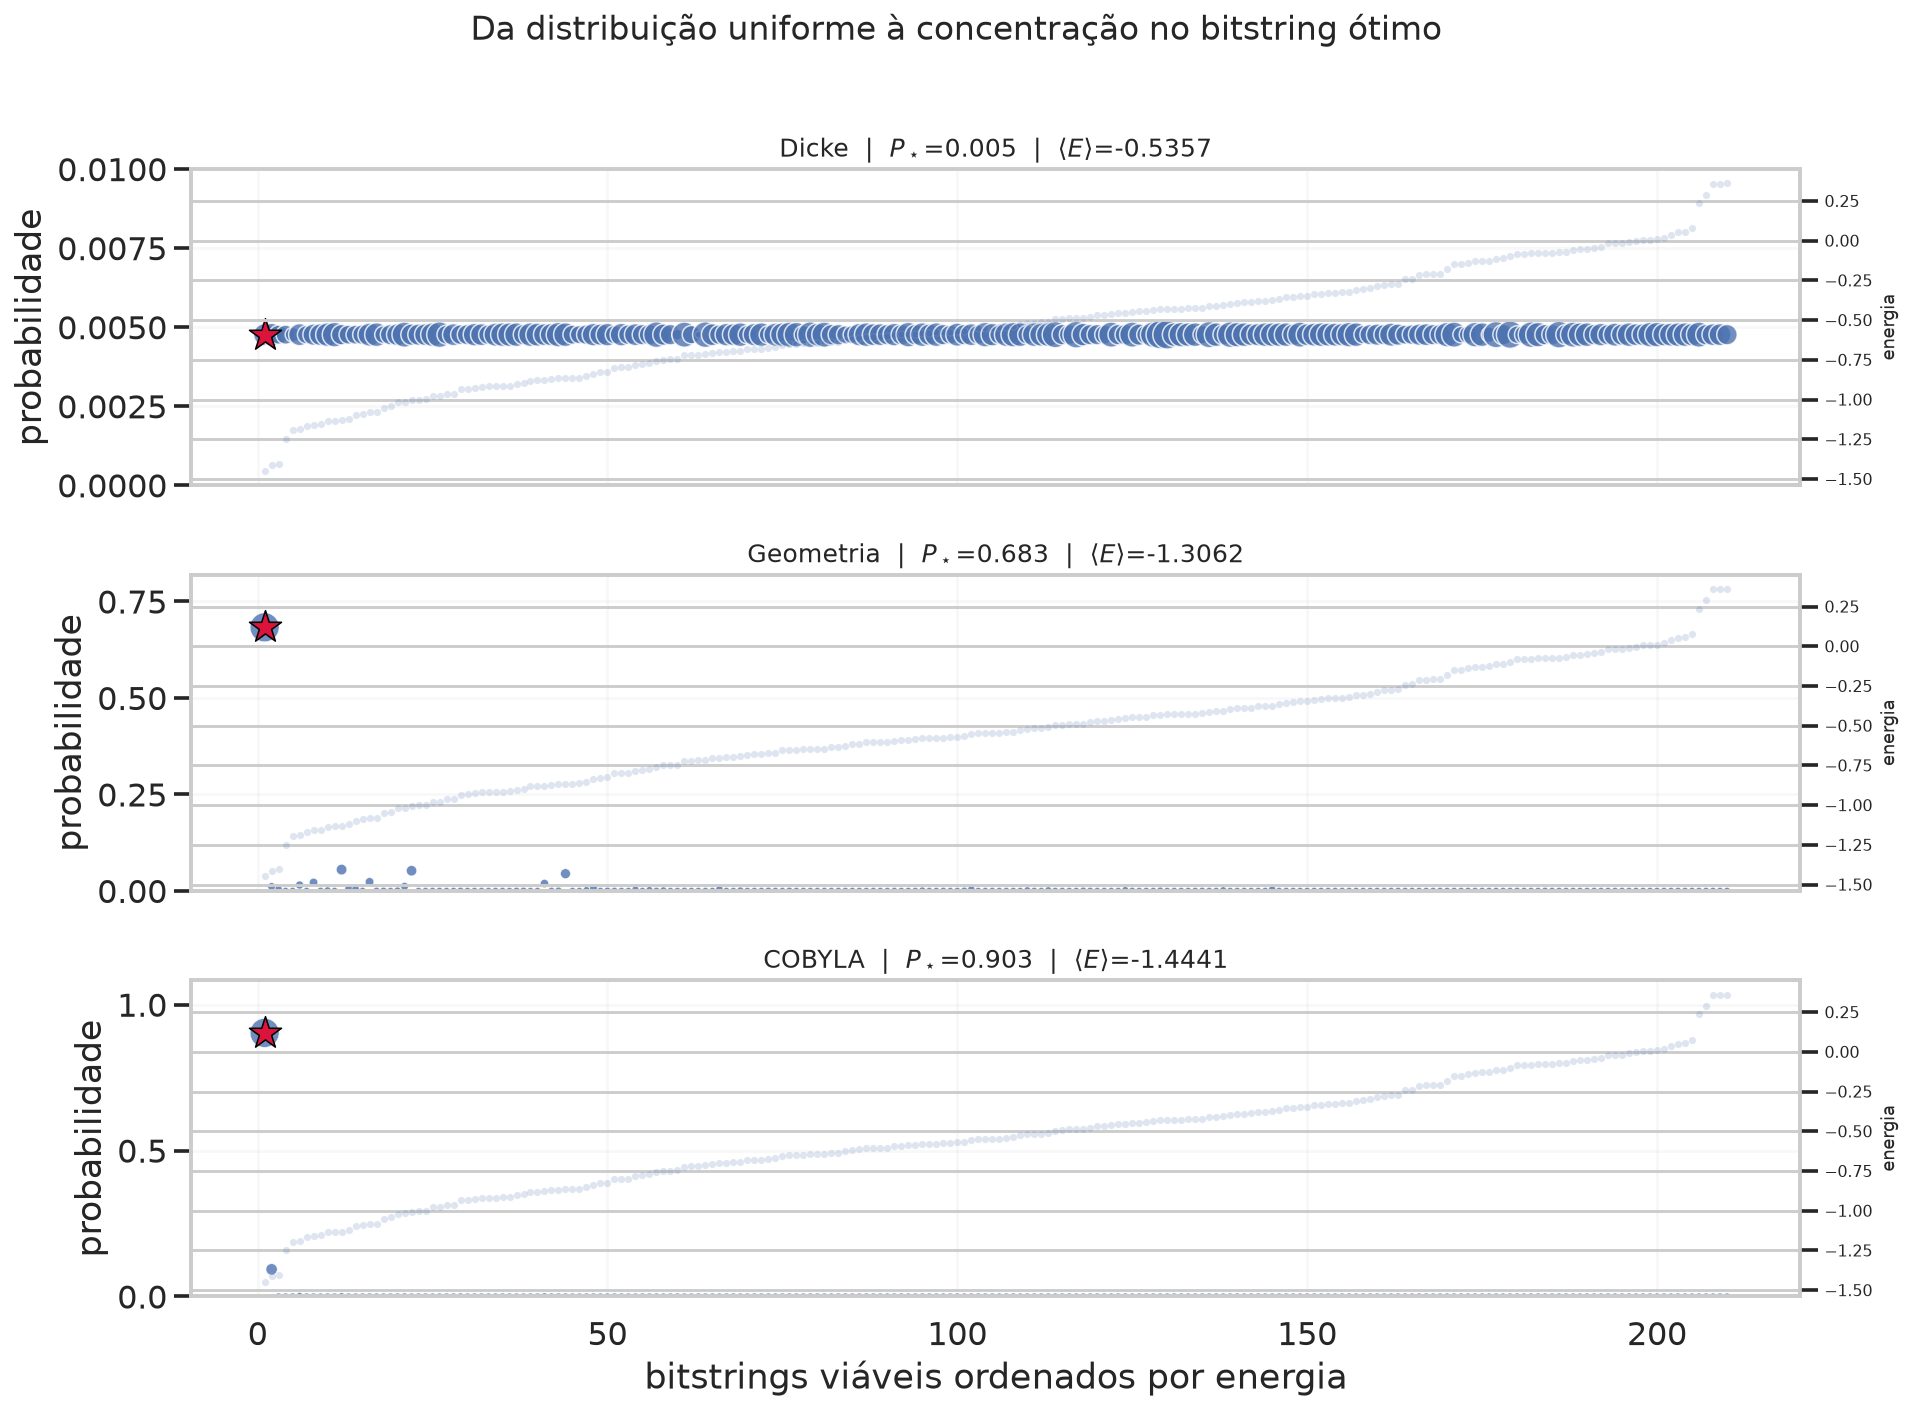

Problema representativo: BR_EQUITY_BRL::BR_EQUITY_BRL__N10__aa8eac1b9370d109::10C4


In [16]:
# =====================================================================
# DISTRIBUIÇÃO SOBRE BITSTRINGS — COMPARAÇÃO PRINCIPAL
# =====================================================================
#
# Para apresentação, mantemos apenas:
#   1) Dicke: ponto de partida;
#   2) Geometria: método proposto;
#   3) COBYLA: baseline iterativo mais competitivo.
#
# Isso reduz poluição visual e deixa a interpretação física imediata.
# =====================================================================

rep_candidates = [
    p
    for p in PROBLEMS
    if (
        p.n == 10
        and p.k == 4
        and p.market == "BR_EQUITY_BRL"
    )
]

geom_scores = []

for p in rep_candidates:
    geom_scores.append(
        (
            p.problem_id,
            exact_metrics(
                p,
                geometry_delta_for_problem(
                    p
                ),
            )["Pstar"],
        )
    )

geom_vals = np.asarray(
    [
        value
        for _, value in geom_scores
    ],
    float,
)

target_geom = float(
    np.median(
        geom_vals
    )
)

rep_pid = min(
    geom_scores,
    key=lambda item:abs(
        item[1]
        -target_geom
    ),
)[0]

REP_PROBLEM = problem_lookup(
    rep_pid
)


def best_vqe_delta(
    problem_id,
    optimizer,
):
    records = [
        r
        for r in VQE_RUNS
        if (
            r["problem_id"] == problem_id
            and r["optimizer"] == optimizer
        )
    ]

    if not records:
        return None

    scored = []

    for r in records:
        pstar = exact_metrics(
            REP_PROBLEM,
            np.asarray(
                r["selected_delta"],
                float,
            ),
        )["Pstar"]

        scored.append(
            (
                pstar,
                r,
            )
        )

    return np.asarray(
        max(
            scored,
            key=lambda item:item[0],
        )[1]["selected_delta"],
        float,
    )


dicke_delta = np.zeros(
    len(
        BUNDLES[
            (
                REP_PROBLEM.n,
                REP_PROBLEM.k,
            )
        ]["structure"]
    ),
    float,
)

cobyla_delta = best_vqe_delta(
    REP_PROBLEM.problem_id,
    "COBYLA",
)

method_deltas = {
    "Dicke": dicke_delta,
    "Geometria": geometry_delta_for_problem(
        REP_PROBLEM
    ),
}

if cobyla_delta is not None:
    method_deltas[
        "COBYLA"
    ] = cobyla_delta


order = np.argsort(
    REP_PROBLEM.E
)

E_sorted = REP_PROBLEM.E[
    order
]

X_sorted = REP_PROBLEM.X[
    order
]

opt_sorted_mask = REP_PROBLEM.opt_mask[
    order
]

bit_labels = [
    "".join(
        map(
            str,
            row.tolist(),
        )
    )
    for row in X_sorted
]


BIT_ROWS = []

for method, delta in method_deltas.items():
    result = exact_metrics(
        REP_PROBLEM,
        delta,
    )

    p_sorted = result[
        "probabilities"
    ][
        order
    ]

    for rank, (
        bitstring,
        energy,
        probability,
        is_optimal,
    ) in enumerate(
        zip(
            bit_labels,
            E_sorted,
            p_sorted,
            opt_sorted_mask,
        ),
        start=1,
    ):
        BIT_ROWS.append(
            {
                "method":method,
                "rank_energy":int(rank),
                "bitstring":bitstring,
                "energy":float(energy),
                "probability":float(probability),
                "is_optimal":bool(is_optimal),
                "Pstar_total":float(
                    result[
                        "Pstar"
                    ]
                ),
                "expected_energy":float(
                    result[
                        "energy"
                    ]
                ),
            }
        )


BIT_DF = pd.DataFrame(
    BIT_ROWS
)

methods_in_plot = list(
    method_deltas
)

fig, axes = plt.subplots(
    len(
        methods_in_plot
    ),
    1,
    figsize=(
        14,
        3.35*len(
            methods_in_plot
        ),
    ),
    sharex=True,
)

if len(
    methods_in_plot
)==1:
    axes=[
        axes
    ]


for ax, method in zip(
    axes,
    methods_in_plot,
):
    g=BIT_DF[
        BIT_DF[
            "method"
        ]==method
    ].copy()

    # Energia: pontos pequenos e discretos.
    ax_energy=ax.twinx()

    sns.scatterplot(
        data=g,
        x="rank_energy",
        y="energy",
        s=14,
        alpha=0.18,
        legend=False,
        ax=ax_energy,
    )

    ax_energy.set_ylabel(
        "energia",
        fontsize=9,
    )
    ax_energy.tick_params(
        axis="y",
        labelsize=8,
    )

    # Probabilidade.
    sns.scatterplot(
        data=g,
        x="rank_energy",
        y="probability",
        size="probability",
        sizes=(12,220),
        alpha=0.80,
        legend=False,
        ax=ax,
    )

    gopt=g[
        g[
            "is_optimal"
        ]
    ]

    ax.scatter(
        gopt[
            "rank_energy"
        ],
        gopt[
            "probability"
        ],
        marker="*",
        s=300,
        color="crimson",
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
    )

    pstar=float(
        g[
            "Pstar_total"
        ].iloc[0]
    )

    eexp=float(
        g[
            "expected_energy"
        ].iloc[0]
    )

    ax.set_title(
        (
            f"{method}  |  "
            f"$P_\\star$={pstar:.3f}  |  "
            f"$\\langle E\\rangle$={eexp:.4f}"
        ),
        fontsize=13,
    )

    ax.set_ylabel(
        "probabilidade"
    )

    # Evita o offset científico estranho que apareceu no Dicke.
    ymax=max(
        float(
            g[
                "probability"
            ].max()
        )*1.20,
        0.01,
    )

    ax.set_ylim(
        0,
        ymax,
    )

    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

    ax.grid(
        alpha=0.13,
    )


axes[-1].set_xlabel(
    "bitstrings viáveis ordenados por energia"
)

fig.suptitle(
    "Da distribuição uniforme à concentração no bitstring ótimo",
    fontsize=17,
    y=1.01,
)

fig.tight_layout()

fig.savefig(
    PRESENTATION_FIG_DIR/
    "bitstrings_dicke_geometry_cobyla_v2.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "Problema representativo:",
    REP_PROBLEM.problem_id,
)

### O que o gráfico dos bitstrings mostra

Os bitstrings estão ordenados pela energia.

A estrela marca o bitstring ótimo. O tamanho vertical de cada ponto representa
a probabilidade atribuída a cada estado.

O objetivo visual é acompanhar a transformação:

$$
\text{Dicke}
\longrightarrow
\text{distribuição modificada}
\longrightarrow
\text{concentração no ótimo}.
$$

No Dicke, a massa está inicialmente distribuída de forma uniforme no subespaço
factível.

Depois da atualização geométrica, uma parcela muito maior da massa é deslocada
para a região de baixa energia e, em particular, para o ótimo.

COBYLA serve como comparação iterativa: ele pode alcançar uma concentração
semelhante, mas faz isso por uma sequência de avaliações do objetivo.

## 8.1 Densidade de probabilidade no eixo de energia

O gráfico anterior preserva a identidade de cada bitstring.

Agora fazemos uma segunda leitura:

> em qual região de energia a probabilidade total de cada método está concentrada?

Definimos a energia normalizada:

$$
\epsilon(x)
=
\frac{
E(x)-E_{\min}
}{
E_{\max}-E_{\min}
}.
$$

Logo:

- $\epsilon=0$ corresponde ao ótimo;
- $\epsilon=1$ corresponde ao estado de maior energia.

A densidade abaixo é ponderada por $p(x)$.
Portanto uma concentração próxima de zero significa que o método deslocou a
massa de probabilidade para a região energeticamente favorável.

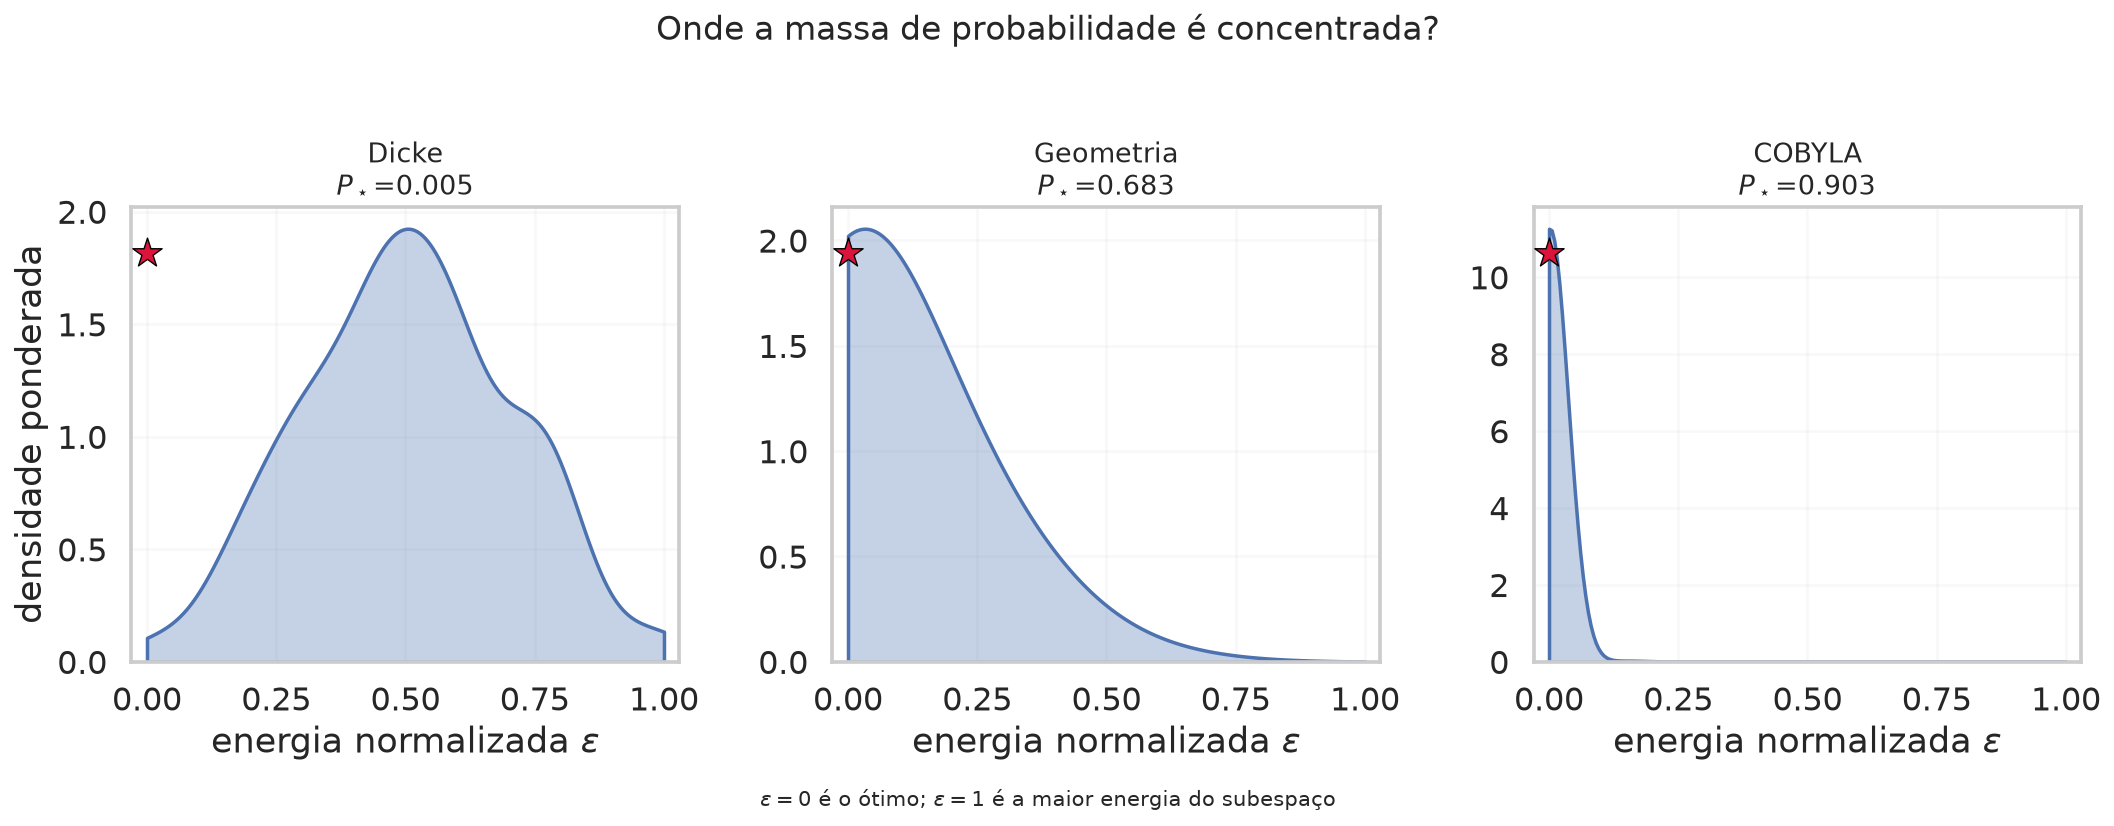

In [17]:
# =====================================================================
# DENSIDADE DE PROBABILIDADE NO EIXO DE ENERGIA
# =====================================================================
#
# Cada método ganha seu próprio painel.
# Assim não precisamos de legenda e não existe sobreposição de curvas.
# =====================================================================

energy_span=max(
    float(
        REP_PROBLEM.Emax
        -REP_PROBLEM.E0
    ),
    1e-30,
)

KDE_ROWS=[]

for method,delta in method_deltas.items():
    result=exact_metrics(
        REP_PROBLEM,
        delta,
    )

    normalized_energy=(
        REP_PROBLEM.E
        -REP_PROBLEM.E0
    )/energy_span

    for e,pw in zip(
        normalized_energy,
        result[
            "probabilities"
        ],
    ):
        KDE_ROWS.append(
            {
                "method":method,
                "normalized_energy":float(
                    e
                ),
                "probability_weight":float(
                    pw
                ),
                "Pstar":float(
                    result[
                        "Pstar"
                    ]
                ),
            }
        )


ENERGY_DENSITY_DF=pd.DataFrame(
    KDE_ROWS
)

fig,axes=plt.subplots(
    1,
    len(
        methods_in_plot
    ),
    figsize=(
        5.2*len(
            methods_in_plot
        ),
        5.5,
    ),
    sharex=True,
)

if len(
    methods_in_plot
)==1:
    axes=[
        axes
    ]


for ax,method in zip(
    axes,
    methods_in_plot,
):
    g=ENERGY_DENSITY_DF[
        ENERGY_DENSITY_DF[
            "method"
        ]==method
    ]

    sns.kdeplot(
        data=g,
        x="normalized_energy",
        weights="probability_weight",
        fill=True,
        alpha=0.32,
        linewidth=1.8,
        common_norm=False,
        clip=(0,1),
        ax=ax,
    )

    pstar=float(
        g[
            "Pstar"
        ].iloc[0]
    )

    ylim=ax.get_ylim()

    ax.scatter(
        [0],
        [
            0.90*ylim[1]
        ],
        marker="*",
        s=250,
        color="crimson",
        edgecolor="black",
        linewidth=0.7,
        zorder=10,
    )

    ax.set_title(
        (
            f"{method}\n"
            f"$P_\\star$={pstar:.3f}"
        ),
        fontsize=14,
    )

    ax.set_xlim(
        -0.03,
        1.03,
    )

    ax.set_xlabel(
        r"energia normalizada $\epsilon$"
    )

    ax.set_ylabel(
        "densidade ponderada"
        if ax is axes[0]
        else ""
    )

    ax.grid(
        alpha=0.12,
    )


fig.suptitle(
    "Onde a massa de probabilidade é concentrada?",
    fontsize=17,
    y=1.02,
)

fig.text(
    0.5,
    -0.01,
    (
        r"$\epsilon=0$ é o ótimo; "
        r"$\epsilon=1$ é a maior energia do subespaço"
    ),
    ha="center",
    fontsize=11,
)

fig.tight_layout()

fig.savefig(
    PRESENTATION_FIG_DIR/
    "probability_density_facets_v2.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

### O que a densidade de probabilidade revela

Aqui os bitstrings individuais são agrupados pelo eixo de energia normalizada:

$$
\epsilon
=
\frac{E-E_{\min}}{E_{\max}-E_{\min}}.
$$

Assim:

$$
\epsilon=0
$$

é o ótimo e

$$
\epsilon=1
$$

é a extremidade de maior energia do subespaço.

A densidade é ponderada pela probabilidade $p(x)$.

Portanto, quando a massa se desloca para a esquerda, a interpretação é direta:

> o método concentrou probabilidade em estados energeticamente melhores.

Esse gráfico é complementar ao gráfico de bitstrings: o anterior mostra
**quais estados** recebem probabilidade; este mostra **em qual região de energia**
a massa total está concentrada.


## 9. Estrutura triangular: onde entra a “memória” entre os modos?

Uma das ideias mais importantes do experimento é que os coeficientes modais não surgem de forma independente.
Eles obedecem uma recorrência triangular do tipo:

$$
c_j
=
\frac{z_j}{R_{jj}}
-
\sum_{i<j}
\frac{R_{ij}}{R_{jj}} c_i.
$$

### Como ler essa fórmula

- $z_j / R_{jj}$ é o **termo direto** do modo $j$;
- a soma
  $\sum_{i<j}(R_{ij}/R_{jj})c_i$
  é a **memória triangular** dos modos anteriores;
- portanto, o coeficiente $c_j$ não nasce sozinho: ele é o resultado de um balanço entre contribuição direta e correções herdadas dos modos anteriores.

### Moral geométrica

Se a parte triangular for forte, então a regularidade observada nos coeficientes não é apenas “um ajuste local em cada coordenada”, mas o produto de uma cadeia ordenada de acoplamentos entre modos.


### Derivação em três modos

Considere

$$
R=
\begin{bmatrix}
R_{11} & R_{12} & R_{13}\\
0      & R_{22} & R_{23}\\
0      & 0      & R_{33}
\end{bmatrix}.
$$

Da relação

$$
R^\top c=z
$$

obtemos sequencialmente:

$$
c_1=\frac{z_1}{R_{11}},
$$

$$
c_2=
\frac{
z_2-R_{12}c_1
}{
R_{22}
},
$$

$$
c_3=
\frac{
z_3-R_{13}c_1-R_{23}c_2
}{
R_{33}
}.
$$

Isso mostra por que chamamos o termo anterior de **memória triangular**:
o modo 3 carrega informação dos modos 1 e 2.

#### Exemplo numérico

Considere:

$$
R=
\begin{bmatrix}
2.0&0.6&-0.2\\
0&1.5&0.4\\
0&0&1.2
\end{bmatrix},
\qquad
z=
\begin{bmatrix}
1.2\\
-0.3\\
0.5
\end{bmatrix}.
$$

Então:

$$
c_1=\frac{1.2}{2}=0.60,
$$

$$
c_2=
\frac{-0.3-0.6(0.60)}{1.5}
=
-0.44,
$$

e:

$$
c_3=
\frac{
0.5-(-0.2)(0.60)-0.4(-0.44)
}{1.2}
\approx0.663.
$$

O terceiro coeficiente não é determinado apenas por $z_3$.
Ele incorpora explicitamente os coeficientes anteriores.

### Referência matemática

Essa recorrência é a solução por substituição progressiva de um sistema
triangular associado à fatoração QR. Uma referência padrão é:

- G. H. Golub e C. F. Van Loan,
  *Matrix Computations*, 4ª ed., Johns Hopkins University Press, 2013.

A recorrência usada aqui é uma consequência algébrica dessa estrutura
triangular; a interpretação como “memória modal” é a leitura física adotada
neste experimento.


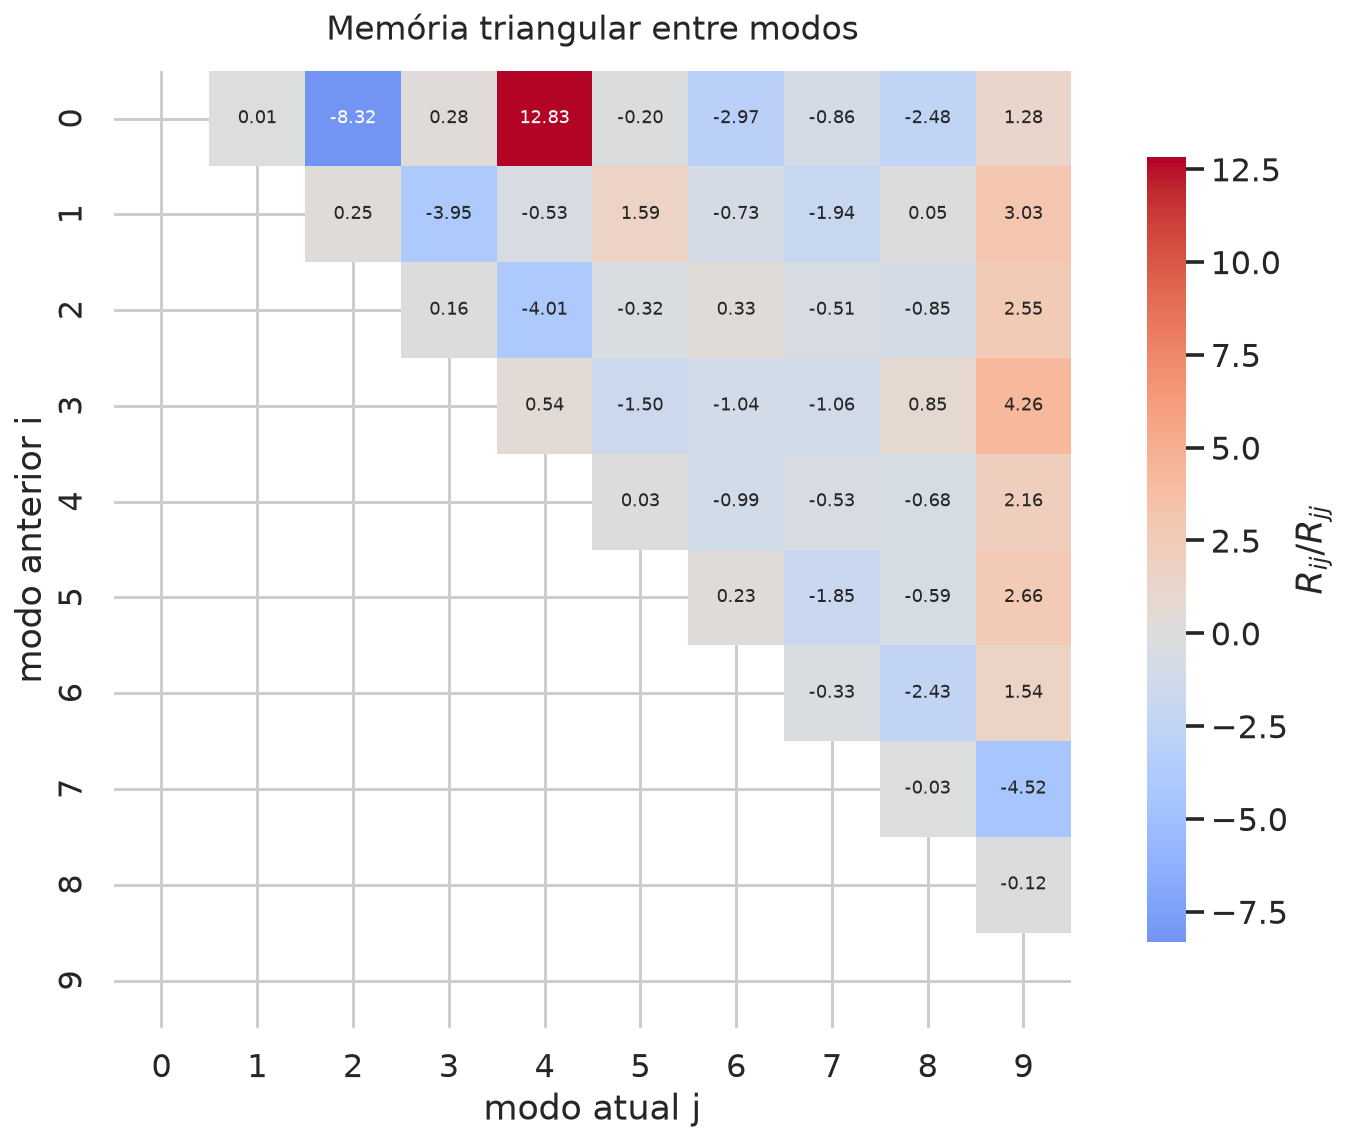

In [18]:
# =====================================================================
# TRIANGULAÇÃO — FIGURA 1: MATRIZ DE MEMÓRIA ENTRE MODOS
# =====================================================================
#
# Partimos da relação:
#
#       R^T c = z
#
# cuja recorrência é:
#
#       c_j = z_j/R_jj - sum_{i<j}(R_ij/R_jj)c_i
#
# O heatmap mostra exatamente os coeficientes:
#
#       R_ij / R_jj
#
# que transportam informação dos modos anteriores i para o modo atual j.
# =====================================================================

rep_dirs = DIRECTION_CACHE[
    REP_PROBLEM.problem_id
]

rep_qr = canonical_qr_from_B(
    rep_dirs[
        "B"
    ]
)

R = np.asarray(
    rep_qr[
        "R"
    ],
    float,
)

q = R.shape[0]

tri = np.full_like(
    R,
    np.nan,
)

for i in range(q):
    for j in range(
        i+1,
        q,
    ):
        # [TR1] Coeficiente de memória triangular.
        #       W_ij = R_ij / R_jj
        tri[
            i,
            j,
        ] = (
            R[
                i,
                j,
            ]
            /R[
                j,
                j,
            ]
        )

fig, ax = plt.subplots(
    figsize=(11.5, 8.5)
)

sns.heatmap(
    tri,
    mask=np.isnan(
        tri
    ),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={
        "fontsize":9
    },
    cbar_kws={
        "label":r"$R_{ij}/R_{jj}$",
        "shrink":0.82,
    },
    square=True,
    ax=ax,
)

ax.set_title(
    "Memória triangular entre modos",
    fontsize=17,
    pad=16,
)

ax.set_xlabel(
    "modo atual j",
)

ax.set_ylabel(
    "modo anterior i",
)

fig.tight_layout()

fig.savefig(
    PRESENTATION_FIG_DIR/
    "triangular_memory_heatmap.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

### Como ler o gráfico de memória triangular

Cada célula representa o fator

$$
\frac{R_{ij}}{R_{jj}},
\qquad i<j,
$$

que aparece na recorrência

$$
c_j
=
\frac{z_j}{R_{jj}}
-
\sum_{i<j}
\frac{R_{ij}}{R_{jj}}c_i.
$$

Portanto, **a coluna $j$ responde à pergunta**:

> quais modos anteriores participam da formação do coeficiente atual $c_j$?

Uma célula com magnitude grande significa que o modo anterior $i$ exerce uma
correção importante sobre o modo $j$.

O triângulo inferior fica vazio porque a recorrência é causal na ordem escolhida:
$c_j$ depende somente dos coeficientes anteriores $c_i$, com $i<j$.

**O que este gráfico demonstra:** existe acoplamento sequencial entre modos.

**O que ele não demonstra sozinho:** que a ordem QR escolhida seja a única ordem
possível ou fisicamente universal.

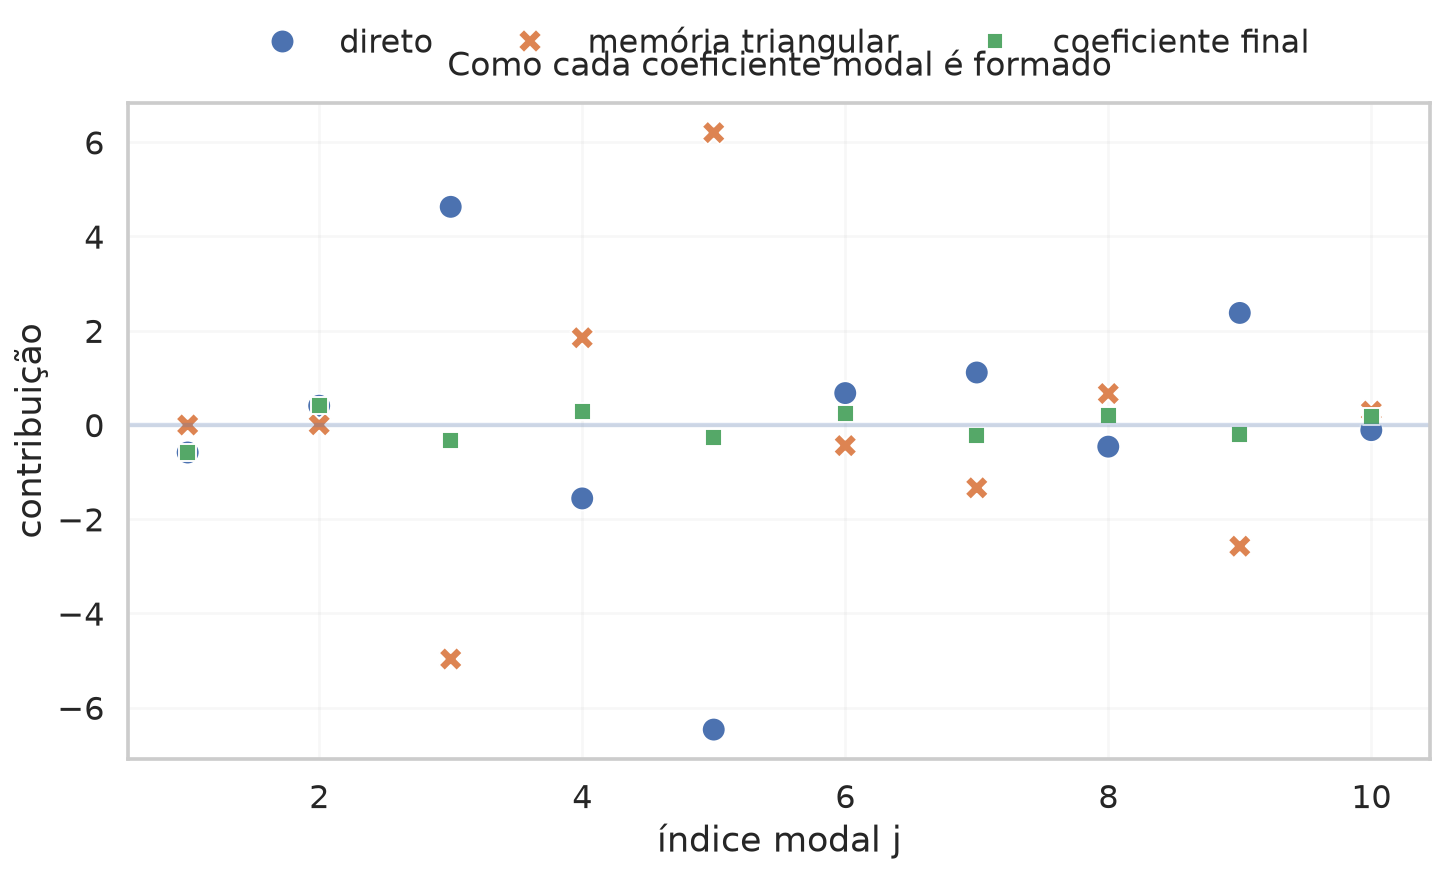

In [19]:
# =====================================================================
# TRIANGULAÇÃO — FIGURA 2: TERMO DIRETO + MEMÓRIA = COEFICIENTE FINAL
# =====================================================================
#
# Equação mostrada ponto a ponto:
#
#       c_j = direto_j + memoria_j
#
# com:
#
#       direto_j  = z_j / R_jj
#
#       memoria_j = - sum_{i<j}(R_ij/R_jj)c_i
#
# O objetivo é visualizar de onde cada coeficiente final c_j vem.
# =====================================================================

# Usamos o vetor estrutural fixo como c para decompor a recorrência.
c = np.asarray(
    FROZEN_A_Q10,
    float,
)

# [TR2] Pela equação R^T c = z:
z = R.T @ c

rows = []

for j in range(q):

    # [TR3] Parcela que vem diretamente de z_j.
    direct = (
        z[j]
        /R[
            j,
            j,
        ]
    )

    # [TR4] Memória acumulada dos modos anteriores.
    memory = (
        -float(
            np.sum(
                (
                    R[
                        :j,
                        j,
                    ]
                    /R[
                        j,
                        j,
                    ]
                )
                *c[
                    :j
                ]
            )
        )
        if j>0
        else 0.0
    )

    # [TR5] Reconstrução da recorrência:
    #       c_j = direct + memory
    recon = (
        direct
        +memory
    )

    rows.extend(
        [
            {
                "modo":j+1,
                "termo":"direto",
                "valor":float(
                    direct
                ),
            },
            {
                "modo":j+1,
                "termo":"memória triangular",
                "valor":float(
                    memory
                ),
            },
            {
                "modo":j+1,
                "termo":"coeficiente final",
                "valor":float(
                    recon
                ),
            },
        ]
    )

TRI_DECOMP_DF = pd.DataFrame(
    rows
)

fig, ax = plt.subplots(
    figsize=(12, 7)
)

sns.scatterplot(
    data=TRI_DECOMP_DF,
    x="modo",
    y="valor",
    hue="termo",
    style="termo",
    s=150,
    ax=ax,
)

ax.axhline(
    0,
    alpha=0.25,
)

ax.set_title(
    "Como cada coeficiente modal é formado",
    fontsize=17,
    pad=14,
)

ax.set_xlabel(
    "índice modal j",
)

ax.set_ylabel(
    "contribuição",
)

# A legenda fica totalmente FORA da área de dados.
ax.legend(
    title="",
    bbox_to_anchor=(0.5, 1.16),
    loc="upper center",
    ncol=3,
    frameon=False,
)

ax.grid(
    alpha=0.14,
)

fig.subplots_adjust(
    top=0.78,
)

fig.savefig(
    PRESENTATION_FIG_DIR/
    "triangular_direct_memory_final.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

### Como ler a decomposição direto × memória × coeficiente final

Para cada modo $j$, o gráfico mostra três pontos:

1. **direto**
   $$
   \frac{z_j}{R_{jj}};
   $$

2. **memória triangular**
   $$
   -\sum_{i<j}\frac{R_{ij}}{R_{jj}}c_i;
   $$

3. **coeficiente final**
   $$
   c_j
   =
   \frac{z_j}{R_{jj}}
   -
   \sum_{i<j}\frac{R_{ij}}{R_{jj}}c_i.
   $$

Se o ponto final estiver muito diferente do termo direto, significa que os modos
anteriores estão corrigindo fortemente aquela coordenada.

Se direto e memória tiverem sinais opostos, existe **cancelamento**.

Se tiverem o mesmo sinal, existe **reforço**.

Esse é o mecanismo que permite interpretar a triangulação como uma forma de
**memória sequencial entre modos**, e não como um conjunto de coeficientes
independentes.

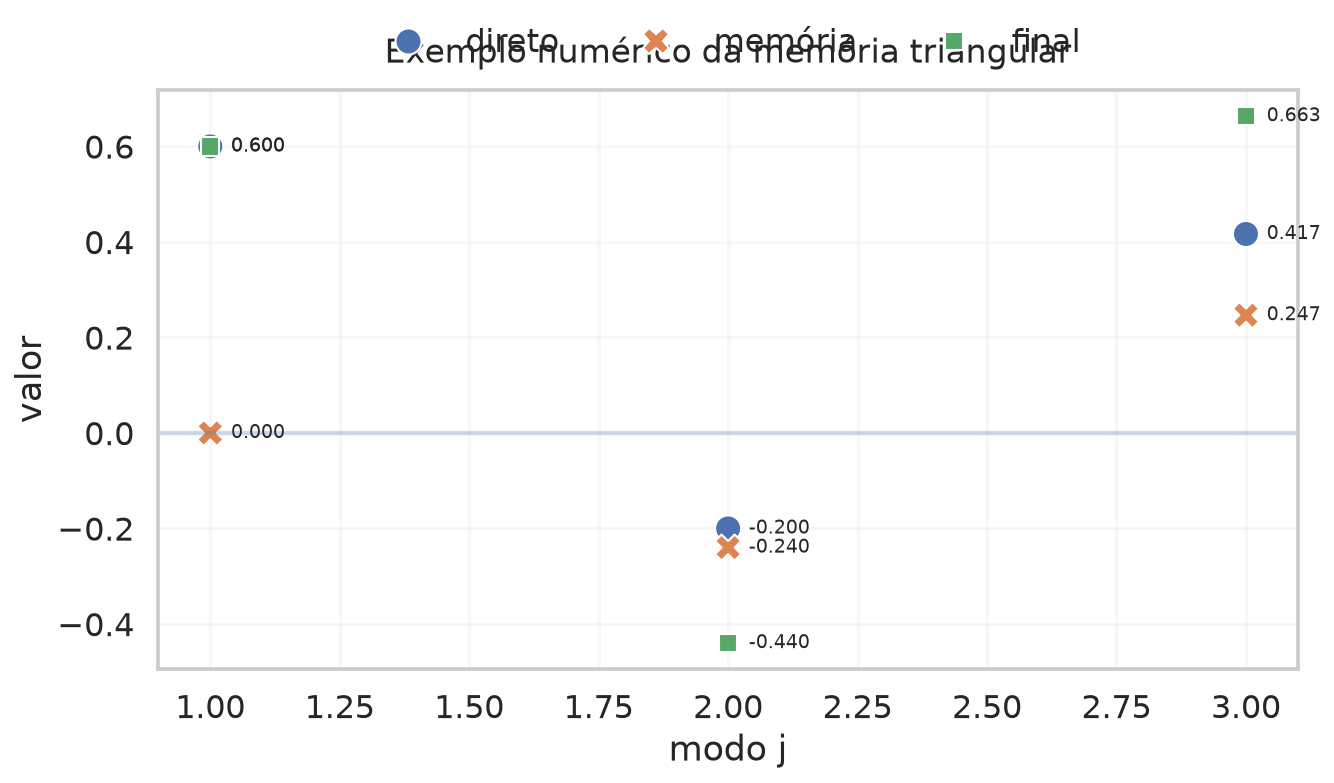

Valores do exemplo:
c1 = 0.600
c2 = -0.440
c3 = 0.663


In [20]:
# =====================================================================
# FIGURA: EXEMPLO NUMÉRICO DA MEMÓRIA TRIANGULAR
# =====================================================================
#
# Exemplo usado no texto:
#
#   R = [[2.0, 0.6, -0.2],
#        [0.0, 1.5,  0.4],
#        [0.0, 0.0,  1.2]]
#
#   z = [1.2, -0.3, 0.5]^T
#
# Então:
#   c1 =  z1 / R11
#   c2 =  z2 / R22 - (R12/R22)c1
#   c3 =  z3 / R33 - (R13/R33)c1 - (R23/R33)c2
# =====================================================================

R_demo = np.array([
    [2.0, 0.6, -0.2],
    [0.0, 1.5,  0.4],
    [0.0, 0.0,  1.2],
], float)

z_demo = np.array([1.2, -0.3, 0.5], float)

c1_direct = z_demo[0] / R_demo[0,0]
c1_memory = 0.0
c1 = c1_direct + c1_memory

c2_direct = z_demo[1] / R_demo[1,1]
c2_memory = -(R_demo[0,1] / R_demo[1,1]) * c1
c2 = c2_direct + c2_memory

c3_direct = z_demo[2] / R_demo[2,2]
c3_memory = -(R_demo[0,2] / R_demo[2,2]) * c1 - (R_demo[1,2] / R_demo[2,2]) * c2
c3 = c3_direct + c3_memory

demo_df = pd.DataFrame({
    "modo": [1, 1, 1, 2, 2, 2, 3, 3, 3],
    "termo": [
        "direto", "memória", "final",
        "direto", "memória", "final",
        "direto", "memória", "final",
    ],
    "valor": [
        c1_direct, c1_memory, c1,
        c2_direct, c2_memory, c2,
        c3_direct, c3_memory, c3,
    ],
})

fig, ax = plt.subplots(figsize=(10.5, 6))
sns.scatterplot(data=demo_df, x="modo", y="valor", hue="termo", style="termo", s=180, ax=ax)
ax.axhline(0, alpha=0.25)

for row in demo_df.itertuples(index=False):
    ax.text(row.modo + 0.04, row.valor, f"{row.valor:.3f}", fontsize=10, va="center")

ax.set_title("Exemplo numérico da memória triangular", fontsize=17, pad=14)
ax.set_xlabel("modo j")
ax.set_ylabel("valor")
ax.legend(title="", bbox_to_anchor=(0.5, 1.16), loc="upper center", ncol=3, frameon=False)
ax.grid(alpha=0.15)
fig.subplots_adjust(top=0.80)
fig.savefig(PRESENTATION_FIG_DIR / "triangular_memory_numeric_example.png", dpi=250, bbox_inches="tight")
plt.show()

print("Valores do exemplo:")
print(f"c1 = {c1:.3f}")
print(f"c2 = {c2:.3f}")
print(f"c3 = {c3:.3f}")

### Exemplo numérico da memória triangular

Considere

$$
R=
\begin{bmatrix}
2 & 0.6 & -0.2\\
0 & 1.5 & 0.4\\
0 & 0 & 1.2
\end{bmatrix},
\qquad
z=
\begin{bmatrix}
1.2\\
-0.3\\
0.5
\end{bmatrix}.
$$

A recorrência é

$$
c_j
=
\frac{z_j}{R_{jj}}
-
\sum_{i<j}
\frac{R_{ij}}{R_{jj}}c_i.
$$

Então:

#### Primeiro coeficiente
$$
c_1=\frac{1.2}{2}=0.6.
$$

Aqui ainda não existe memória triangular, porque não há coeficientes anteriores.

#### Segundo coeficiente
$$
c_2
=
\frac{-0.3}{1.5}
-
\frac{0.6}{1.5}c_1
=
-0.2 - 0.24
=
-0.44.
$$

O termo direto seria apenas \(-0.2\), mas a correção triangular desloca o valor final para \(-0.44\).

#### Terceiro coeficiente
$$
c_3
=
\frac{0.5}{1.2}
-
\frac{-0.2}{1.2}c_1
-
\frac{0.4}{1.2}c_2.
$$

Substituindo \(c_1=0.6\) e \(c_2=-0.44\):

$$
c_3
=
0.4167 + 0.1000 + 0.1467
\approx 0.663.
$$

Esse exemplo mostra exatamente o significado da expressão “memória triangular”:

- cada novo coeficiente \(c_j\) recebe um termo próprio;
- depois ele é corrigido pelos coeficientes anteriores;
- por isso o valor final não é apenas a leitura direta de \(z_j\).

Logo, “memória triangular” não quer dizer memória temporal física.  
Quer dizer apenas que, **na resolução do sistema triangular**, o coeficiente atual depende dos anteriores.


## 10. Estrutura dos deslocamentos em $\theta$

Agora voltamos ao espaço físico dos ângulos e perguntamos:

> poucos parâmetros carregam a maior parte do deslocamento?

Dado o vetor:

$$
\Delta\theta = (\Delta\theta_1,\ldots,\Delta\theta_d),
$$

definimos o peso quadrático:

$$
w_j = \frac{\Delta\theta_j^2}{\sum_{\ell}\Delta\theta_\ell^2}.
$$

Então o número mínimo de parâmetros necessários para carregar 90\% da amplitude quadrática é:

$$
N_{90}^{\theta}
=
\min\left\{m : \sum_{j=1}^m w_{(j)} \ge 0.90\right\}.
$$

Também usamos a dimensão efetiva:

$$
d_{\rm eff}
=
\frac{\left(\sum_j \Delta\theta_j^2\right)^2}{\sum_j \Delta\theta_j^4}.
$$

### Interpretação curta

- $N_{90}^{\theta}$ responde: **quantos parâmetros preciso para carregar quase toda a energia quadrática do deslocamento?**
- $d_{\rm eff}$ responde: **quão concentrado é esse deslocamento?**


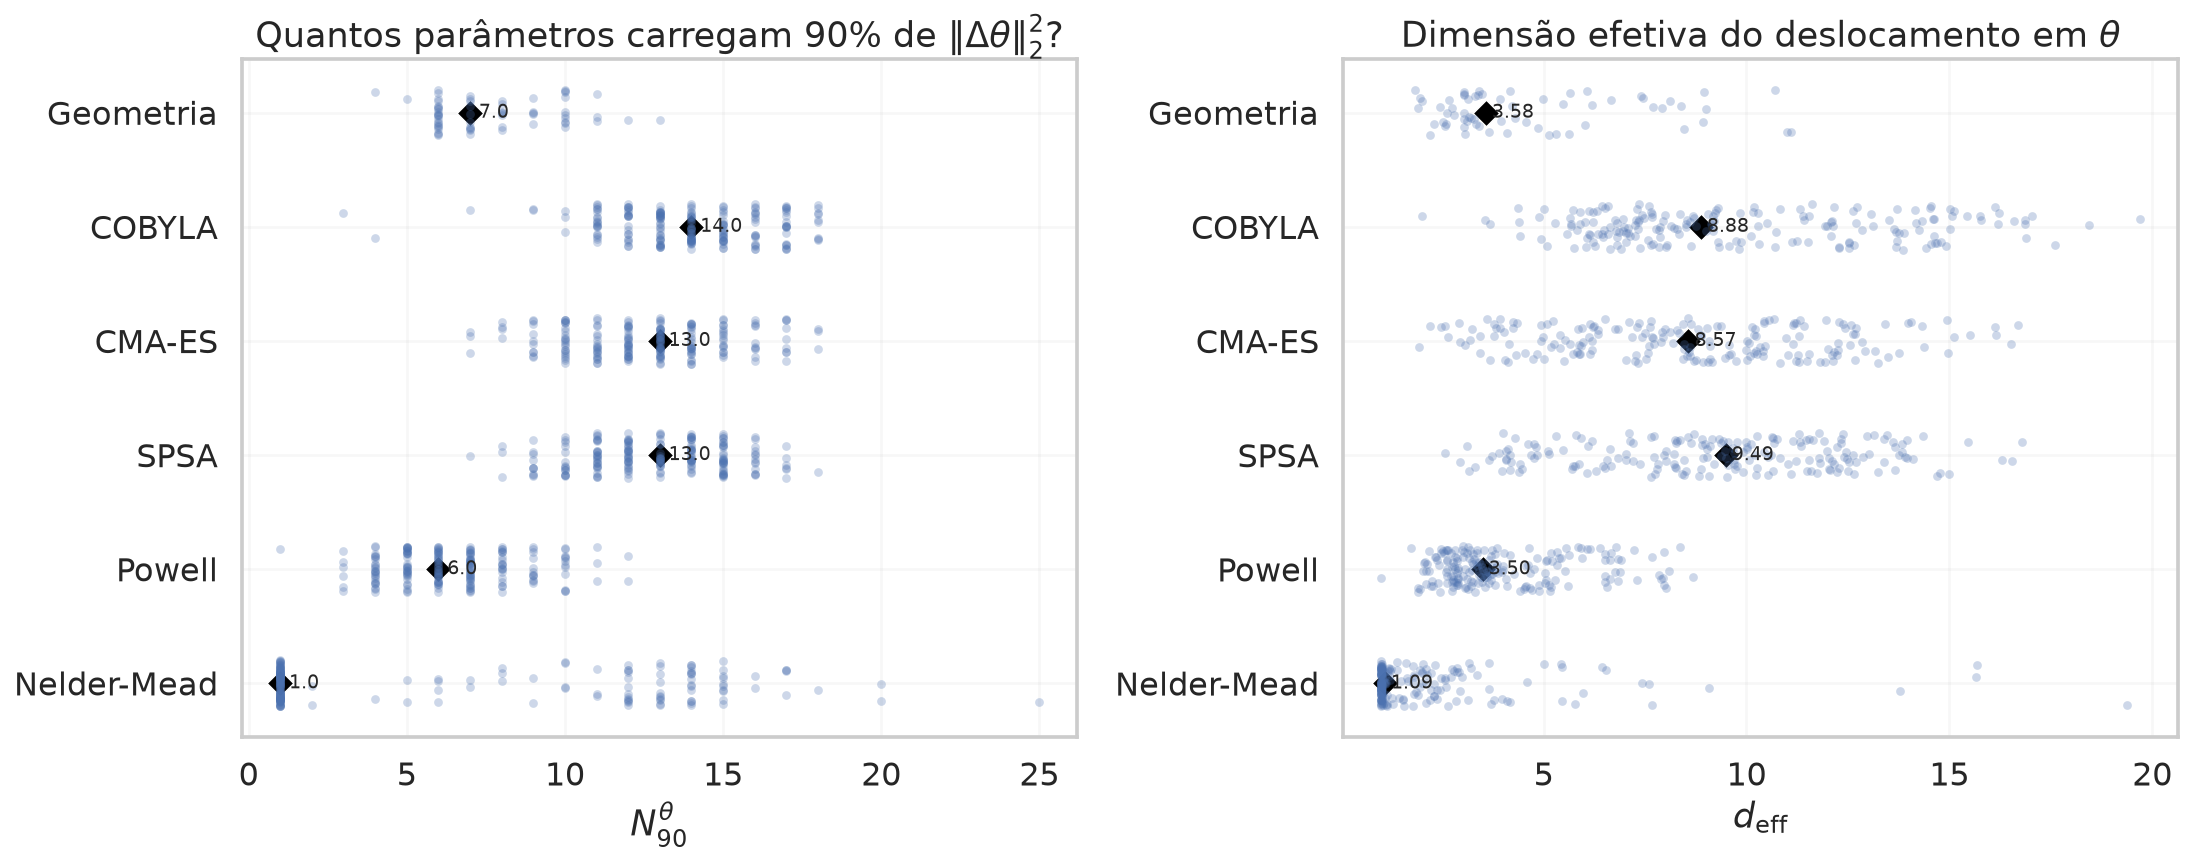

In [21]:
# =====================================================================
# ESTRUTURA DOS DESLOCAMENTOS EM THETA
# =====================================================================
#
# Sem violin plot e sem curvas.
# Cada ponto = um run/endpoint.
# O losango preto = mediana.
# =====================================================================

label_map_theta = {
    f"GEOMETRY_{GEOM_COMPARE_SHOTS}_SHOTS":"Geometria",
    "COBYLA":"COBYLA",
    "CMAES":"CMA-ES",
    "POWELL":"Powell",
    "SPSA":"SPSA",
    "NELDER_MEAD":"Nelder-Mead",
}

method_order_theta=[
    "Geometria",
    "COBYLA",
    "CMA-ES",
    "SPSA",
    "Powell",
    "Nelder-Mead",
]

plot_df=THETA_FULL_DF.copy()

plot_df[
    "method_label"
]=plot_df[
    "method"
].map(
    lambda x:label_map_theta.get(
        x,
        x,
    )
)

plot_df[
    "method_label"
]=pd.Categorical(
    plot_df[
        "method_label"
    ],
    categories=method_order_theta,
    ordered=True,
)

fig,axes=plt.subplots(
    1,
    2,
    figsize=(16,6.5),
)

# ---------------------------------------------------------
# A) N90 theta
# ---------------------------------------------------------
sns.stripplot(
    data=plot_df,
    x="theta_N90",
    y="method_label",
    order=method_order_theta,
    jitter=0.20,
    alpha=0.28,
    size=4.5,
    ax=axes[0],
)

median_n90=(
    plot_df.groupby(
        "method_label",
        observed=False,
        as_index=False,
    )
    .agg(
        median_value=(
            "theta_N90",
            "median",
        )
    )
)

sns.scatterplot(
    data=median_n90,
    x="median_value",
    y="method_label",
    marker="D",
    s=95,
    color="black",
    legend=False,
    ax=axes[0],
)

for row in median_n90.itertuples(index=False):
    axes[0].text(
        float(
            row.median_value
        )+0.28,
        row.method_label,
        f"{row.median_value:.1f}",
        va="center",
        fontsize=10,
    )

axes[0].set_title(
    r"Quantos parâmetros carregam 90% de $\|\Delta\theta\|_2^2$?"
)
axes[0].set_xlabel(
    r"$N_{90}^{\theta}$"
)
axes[0].set_ylabel("")
axes[0].grid(
    alpha=0.14,
)

# ---------------------------------------------------------
# B) effective dimension
# ---------------------------------------------------------
sns.stripplot(
    data=plot_df,
    x="theta_effective_dimension",
    y="method_label",
    order=method_order_theta,
    jitter=0.20,
    alpha=0.28,
    size=4.5,
    ax=axes[1],
)

median_deff=(
    plot_df.groupby(
        "method_label",
        observed=False,
        as_index=False,
    )
    .agg(
        median_value=(
            "theta_effective_dimension",
            "median",
        )
    )
)

sns.scatterplot(
    data=median_deff,
    x="median_value",
    y="method_label",
    marker="D",
    s=95,
    color="black",
    legend=False,
    ax=axes[1],
)

for row in median_deff.itertuples(index=False):
    axes[1].text(
        float(
            row.median_value
        )+0.15,
        row.method_label,
        f"{row.median_value:.2f}",
        va="center",
        fontsize=10,
    )

axes[1].set_title(
    r"Dimensão efetiva do deslocamento em $\theta$"
)
axes[1].set_xlabel(
    r"$d_{\rm eff}$"
)
axes[1].set_ylabel("")
axes[1].grid(
    alpha=0.14,
)

fig.tight_layout()

fig.savefig(
    PRESENTATION_FIG_DIR/
    "theta_structure_points_v2.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

### Como interpretar $N_{90}^{\theta}$ e $d_{\rm eff}$

O primeiro painel mede quantos parâmetros são necessários para carregar 90% da
amplitude quadrática:

$$
N_{90}^{\theta}
=
\min\left\{
m:
\sum_{j=1}^{m}w_{(j)}
\ge0.90
\right\}.
$$

O segundo usa

$$
d_{\rm eff}
=
\frac{
\left(\sum_j\Delta\theta_j^2\right)^2
}{
\sum_j\Delta\theta_j^4
}.
$$

Nesta execução, a geometria apresenta medianamente:

$$
N_{90}^{\theta}\approx7,
\qquad
d_{\rm eff}\approx3.58.
$$

Para COBYLA:

$$
N_{90}^{\theta}\approx14,
\qquad
d_{\rm eff}\approx8.88.
$$

Logo, o deslocamento geométrico é significativamente mais concentrado.

Isso **não prova**, sozinho, que 3–4 parâmetros bastam funcionalmente; por isso
a seção seguinte realiza ablação.


## 11. Ablação causal

Por fim, testamos se determinados parâmetros são apenas grandes em amplitude ou se são realmente necessários.

Para um endpoint com probabilidade final $P_\star^{\rm full}$, retiramos um parâmetro de cada vez:

$$
\Delta\theta_j \rightarrow 0,
$$

recalculamos a probabilidade ótima e medimos a perda:

$$
L_j = P_\star^{\rm full} - P_{\star,-j}.
$$

### Exemplo didático

Se:

$$
P_\star^{\rm full}=0.80,
\qquad
P_{\star,-7}=0.52,
$$

então:

$$
L_7 = 0.28.
$$

Se outro parâmetro produz apenas:

$$
L_{12}=0.01,
$$

então o parâmetro 7 é muito mais crítico para sustentar o endpoint.


In [22]:
# =====================================================================
# MAPA MATEMÁTICO DESTA CÉLULA — ABLAÇÃO CAUSAL/FUNCIONAL
# =====================================================================
# [A1] Perda por remover o parâmetro j:
#      L_j = P*_full - P*_{-j}
#
# [A2] Retenção de um subconjunto top-m:
#      R_P(m) = [P*_(m) - P*_Dicke] / [P*_full - P*_Dicke]
#
# [A3] "stable crossing":
#      primeiro m a partir do qual R_P(m') >= 0.90 para todo m' >= m.
#
# Necessidade e suficiência são perguntas diferentes:
# - remover -> testa necessidade local;
# - manter somente top-m -> testa suficiência funcional.
# =====================================================================

CAUSAL_METHODS=[
    f"GEOMETRY_{GEOM_COMPARE_SHOTS}_SHOTS",
]+OPTIMIZERS_PRESENT

CAUSAL_VQE_SEEDS=(
    VQE_SEEDS_PRESENT
    if CAUSAL_ALL_SEEDS
    else [
        VQE_SEEDS_PRESENT[
            0
        ]
    ]
)

CAUSAL_PROBLEMS=list(
    PROBLEMS
)

if GEOM_FAST_CAUSAL:
    # Development only: first two problems per regime.
    selected=[]
    for n,k in REGIMES:
        selected.extend(
            [
                p
                for p in PROBLEMS
                if (
                    p.n==n
                    and p.k==k
                )
            ][
                :2
            ]
        )
    CAUSAL_PROBLEMS=selected


CAUSAL_CACHE=PRESENTATION_CACHE_DIR/(
    "causal_ablation"
    +("__allseeds" if CAUSAL_ALL_SEEDS else "__seed0")
    +("__fast" if GEOM_FAST_CAUSAL else "__full")
    +".pkl"
)

if CAUSAL_CACHE.exists():
    with open(
        CAUSAL_CACHE,
        "rb",
    ) as f:
        CAUSAL_RESULTS=pickle.load(
            f
        )
else:
    CAUSAL_RESULTS={}


def endpoint_delta(
    problem,
    method,
    seed,
):
    if method.startswith(
        "GEOMETRY_"
    ):
        return geometry_delta_for_problem(
            problem,
            shots=GEOM_COMPARE_SHOTS,
            replicate=GEOM_THETA_REPLICATE,
        )

    r=vqe_record_lookup(
        problem.problem_id,
        method,
        seed,
    )

    return np.asarray(
        r[
            "selected_delta"
        ],
        float,
    )


def retention_relative_to_dicke(
    pstar_subset,
    pstar_full,
    pstar_dicke,
):
    gain=(
        pstar_full
        -pstar_dicke
    )

    if gain<=1e-14:
        return np.nan

    return float(
        (
            pstar_subset
            -pstar_dicke
        )
        /gain
    )


def first_crossing(
    values,
    threshold=0.90,
):
    values=np.asarray(
        values,
        float,
    )

    idx=np.where(
        np.isfinite(
            values
        )
        &(
            values>=threshold
        )
    )[0]

    return (
        int(
            idx[0]+1
        )
        if len(idx)
        else np.nan
    )


def stable_crossing(
    values,
    threshold=0.90,
):
    """
    First m such that every later prefix m' >= m also stays above threshold.
    More conservative than the first crossing when interference makes
    retention non-monotonic.
    """
    values=np.asarray(
        values,
        float,
    )

    for i in range(
        len(values)
    ):
        tail=values[
            i:
        ]

        if (
            np.isfinite(
                tail
            ).all()
            and(
                tail>=threshold
            ).all()
        ):
            return int(
                i+1
            )

    return np.nan


def causal_audit_endpoint(
    problem,
    method,
    seed,
):
    delta=np.asarray(
        endpoint_delta(
            problem,
            method,
            seed,
        ),
        float,
    )

    d=len(
        delta
    )

    full=exact_metrics(
        problem,
        delta,
    )

    dicke=exact_metrics(
        problem,
        np.zeros(
            d,
            float,
        ),
    )

    p_full=float(
        full[
            "Pstar"
        ]
    )

    p_dicke=float(
        dicke[
            "Pstar"
        ]
    )

    theta=theta_state_from_delta(
        problem,
        delta,
    )[
        "delta_theta"
    ]

    theta=np.asarray(
        theta,
        float,
    )

    amp_order=np.argsort(
        -np.abs(
            theta
        ),
        kind="mergesort",
    )

    single_rows=[]
    losses=np.zeros(
        d,
        float,
    )

    # Necessity: remove one parameter at a time.
    for j in range(
        d
    ):
        ablated=delta.copy()
        ablated[
            j
        ]=0.0

        p_minus=float(
            exact_metrics(
                problem,
                ablated,
            )[
                "Pstar"
            ]
        )

        loss=float(
            p_full-p_minus
        )

        losses[
            j
        ]=loss

        single_rows.append(
            {
                "parameter_index":int(j),
                "delta_theta":float(
                    theta[
                        j
                    ]
                ),
                "abs_delta_theta":float(
                    abs(
                        theta[
                            j
                        ]
                    )
                ),
                "Pstar_after_single_ablation":p_minus,
                "single_ablation_loss":loss,
            }
        )

    causal_order=np.argsort(
        -losses,
        kind="mergesort",
    )

    path_rows=[]

    for ranking_name,order in [
        (
            "AMPLITUDE",
            amp_order,
        ),
        (
            "CAUSAL_SINGLE_ABLATION",
            causal_order,
        ),
    ]:
        retention_values=[]

        for m in range(
            1,
            d+1,
        ):
            keep=np.zeros(
                d,
                float,
            )

            chosen=order[
                :m
            ]

            keep[
                chosen
            ]=delta[
                chosen
            ]

            p_m=float(
                exact_metrics(
                    problem,
                    keep,
                )[
                    "Pstar"
                ]
            )

            retention=retention_relative_to_dicke(
                p_m,
                p_full,
                p_dicke,
            )

            retention_values.append(
                retention
            )

            path_rows.append(
                {
                    "ranking":ranking_name,
                    "m":int(m),
                    "Pstar_top_m":p_m,
                    "retention":retention,
                }
            )

        if ranking_name=="AMPLITUDE":
            amp_retention=np.asarray(
                retention_values,
                float,
            )
        else:
            causal_retention=np.asarray(
                retention_values,
                float,
            )

    # Necessity of the four most causally damaging parameters together.
    top4_causal=causal_order[
        :min(
            4,
            d,
        )
    ]

    removed_top4=delta.copy()
    removed_top4[
        top4_causal
    ]=0.0

    p_removed_top4=float(
        exact_metrics(
            problem,
            removed_top4,
        )[
            "Pstar"
        ]
    )

    summary={
        "problem_id":problem.problem_id,
        "market":problem.market,
        "n":int(problem.n),
        "k":int(problem.k),
        "method":method,
        "seed":int(seed),
        "d_active":int(d),
        "Pstar_dicke":p_dicke,
        "Pstar_full":p_full,
        "full_gain_over_dicke":float(
            p_full-p_dicke
        ),
        "max_single_ablation_loss":float(
            np.max(
                losses
            )
        ),
        "median_single_ablation_loss":float(
            np.median(
                losses
            )
        ),
        "positive_single_ablation_fraction":float(
            np.mean(
                losses>0
            )
        ),
        "amplitude_m90_first":first_crossing(
            amp_retention,
            0.90,
        ),
        "amplitude_m90_stable":stable_crossing(
            amp_retention,
            0.90,
        ),
        "causal_m90_first":first_crossing(
            causal_retention,
            0.90,
        ),
        "causal_m90_stable":stable_crossing(
            causal_retention,
            0.90,
        ),
        "amplitude_top4_retention":float(
            amp_retention[
                min(
                    4,
                    d,
                )-1
            ]
        ),
        "causal_top4_retention":float(
            causal_retention[
                min(
                    4,
                    d,
                )-1
            ]
        ),
        "Pstar_after_removing_top4_causal":p_removed_top4,
        "top4_causal_removal_loss":float(
            p_full-p_removed_top4
        ),
    }

    return {
        "summary":summary,
        "single_rows":single_rows,
        "path_rows":path_rows,
    }

In [23]:
for p in tqdm(
    CAUSAL_PROBLEMS,
    desc="causal endpoint audit",
):
    for method in CAUSAL_METHODS:
        seeds=(
            [
                GEOM_THETA_REPLICATE
            ]
            if method.startswith(
                "GEOMETRY_"
            )
            else CAUSAL_VQE_SEEDS
        )

        for seed in seeds:
            key=(
                p.problem_id,
                method,
                int(seed),
            )

            if key in CAUSAL_RESULTS:
                continue

            result=causal_audit_endpoint(
                p,
                method,
                int(seed),
            )

            CAUSAL_RESULTS[
                key
            ]=result

            # Resume-safe after every endpoint.
            with open(
                CAUSAL_CACHE,
                "wb",
            ) as f:
                pickle.dump(
                    CAUSAL_RESULTS,
                    f,
                )


summary_rows=[]
single_rows=[]
path_rows=[]

for (
    problem_id,
    method,
    seed,
),result in CAUSAL_RESULTS.items():
    summary_rows.append(
        result[
            "summary"
        ]
    )

    base_meta={
        "problem_id":problem_id,
        "method":method,
        "seed":int(seed),
    }

    for row in result[
        "single_rows"
    ]:
        single_rows.append(
            {
                **base_meta,
                **row,
            }
        )

    for row in result[
        "path_rows"
    ]:
        path_rows.append(
            {
                **base_meta,
                **row,
            }
        )


CAUSAL_SUMMARY_DF=pd.DataFrame(
    summary_rows
)

CAUSAL_SINGLE_DF=pd.DataFrame(
    single_rows
)

CAUSAL_PATH_DF=pd.DataFrame(
    path_rows
)

GLOBAL_CAUSAL_SUMMARY=(
    CAUSAL_SUMMARY_DF.groupby(
        "method",
        as_index=False,
    )
    .agg(
        endpoints=(
            "problem_id",
            "size",
        ),
        median_full_Pstar=(
            "Pstar_full",
            "median",
        ),
        median_max_single_ablation_loss=(
            "max_single_ablation_loss",
            "median",
        ),
        median_amplitude_m90_first=(
            "amplitude_m90_first",
            "median",
        ),
        median_amplitude_m90_stable=(
            "amplitude_m90_stable",
            "median",
        ),
        median_causal_m90_first=(
            "causal_m90_first",
            "median",
        ),
        median_causal_m90_stable=(
            "causal_m90_stable",
            "median",
        ),
        median_amplitude_top4_retention=(
            "amplitude_top4_retention",
            "median",
        ),
        median_causal_top4_retention=(
            "causal_top4_retention",
            "median",
        ),
        median_top4_causal_removal_loss=(
            "top4_causal_removal_loss",
            "median",
        ),
    )
)

CAUSAL_BY_REGIME=(
    CAUSAL_SUMMARY_DF.groupby(
        [
            "n",
            "k",
            "method",
        ],
        as_index=False,
    )
    .agg(
        endpoints=(
            "problem_id",
            "size",
        ),
        median_full_Pstar=(
            "Pstar_full",
            "median",
        ),
        median_amplitude_m90_stable=(
            "amplitude_m90_stable",
            "median",
        ),
        median_causal_m90_stable=(
            "causal_m90_stable",
            "median",
        ),
        median_amplitude_top4_retention=(
            "amplitude_top4_retention",
            "median",
        ),
        median_causal_top4_retention=(
            "causal_top4_retention",
            "median",
        ),
        median_top4_causal_removal_loss=(
            "top4_causal_removal_loss",
            "median",
        ),
    )
)

print(
    "GLOBAL CAUSAL SUMMARY"
)
display(
    GLOBAL_CAUSAL_SUMMARY
)

print(
    "CAUSAL SUMMARY BY REGIME"
)
display(
    CAUSAL_BY_REGIME
)

CAUSAL_SUMMARY_DF.to_parquet(
    PRESENTATION_DATA_DIR/
    "causal_endpoint_summary.parquet",
    index=False,
)

CAUSAL_SINGLE_DF.to_parquet(
    PRESENTATION_DATA_DIR/
    "causal_single_parameter_ablation.parquet",
    index=False,
)

CAUSAL_PATH_DF.to_parquet(
    PRESENTATION_DATA_DIR/
    "causal_topm_paths.parquet",
    index=False,
)

GLOBAL_CAUSAL_SUMMARY.to_csv(
    PRESENTATION_DATA_DIR/
    "causal_global_summary.csv",
    index=False,
)

CAUSAL_BY_REGIME.to_csv(
    PRESENTATION_DATA_DIR/
    "causal_by_regime.csv",
    index=False,
)

causal endpoint audit: 100%|██████████| 64/64 [00:00<00:00, 438620.03it/s]

GLOBAL CAUSAL SUMMARY


,method,endpoints,median_full_Pstar,median_max_single_ablation_loss,median_amplitude_m90_first,median_amplitude_m90_stable,median_causal_m90_first,median_causal_m90_stable,median_amplitude_top4_retention,median_causal_top4_retention,median_top4_causal_removal_loss
0,CMAES,64,0.068827,4.312806e-02,14.0,19.5,6.0,6.0,0.123195,0.471772,6.461525e-02
1,COBYLA,64,0.755812,4.198877e-01,13.0,15.0,8.0,8.0,0.045258,0.146419,7.166265e-01
2,GEOMETRY_8192_SHOTS,64,0.758659,5.254518e-01,9.0,9.0,8.0,8.0,0.109166,0.121031,7.348524e-01
3,NELDER_MEAD,64,0.003066,4.741574e-08,4.0,17.0,1.0,1.0,1.000000,1.814573,1.009266e-07
4,POWELL,64,0.049258,3.056247e-02,11.0,11.0,4.0,4.0,0.115521,1.000000,4.511705e-02
5,SPSA,64,0.012588,4.850095e-03,11.0,17.0,4.0,4.0,0.339100,1.056926,9.596759e-03


CAUSAL SUMMARY BY REGIME


,n,k,method,endpoints,median_full_Pstar,median_amplitude_m90_stable,median_causal_m90_stable,median_amplitude_top4_retention,median_causal_top4_retention,median_top4_causal_removal_loss
0,10,4,CMAES,16,0.163474,17.5,7.0,0.119240,0.326972,1.484319e-01
1,10,4,COBYLA,16,0.925145,12.0,8.0,0.051733,0.135535,8.859726e-01
2,10,4,GEOMETRY_8192_SHOTS,16,0.748652,9.0,8.0,0.131117,0.157020,7.243283e-01
3,10,4,NELDER_MEAD,16,0.004762,21.0,1.0,0.918916,2.032307,8.158940e-08
4,10,4,POWELL,16,0.083144,12.0,4.0,0.148987,1.000000,7.644072e-02
5,10,4,SPSA,16,0.017742,16.0,3.0,0.407487,1.286800,1.371376e-02
6,10,5,CMAES,16,0.107540,20.0,6.0,0.166313,0.492660,1.013021e-01
7,10,5,COBYLA,16,0.805904,13.5,8.0,0.047523,0.143420,7.765610e-01
8,10,5,GEOMETRY_8192_SHOTS,16,0.783719,9.0,8.0,0.125720,0.138539,7.552191e-01
9,10,5,NELDER_MEAD,16,0.003968,13.0,1.5,0.929411,1.704093,3.099084e-07


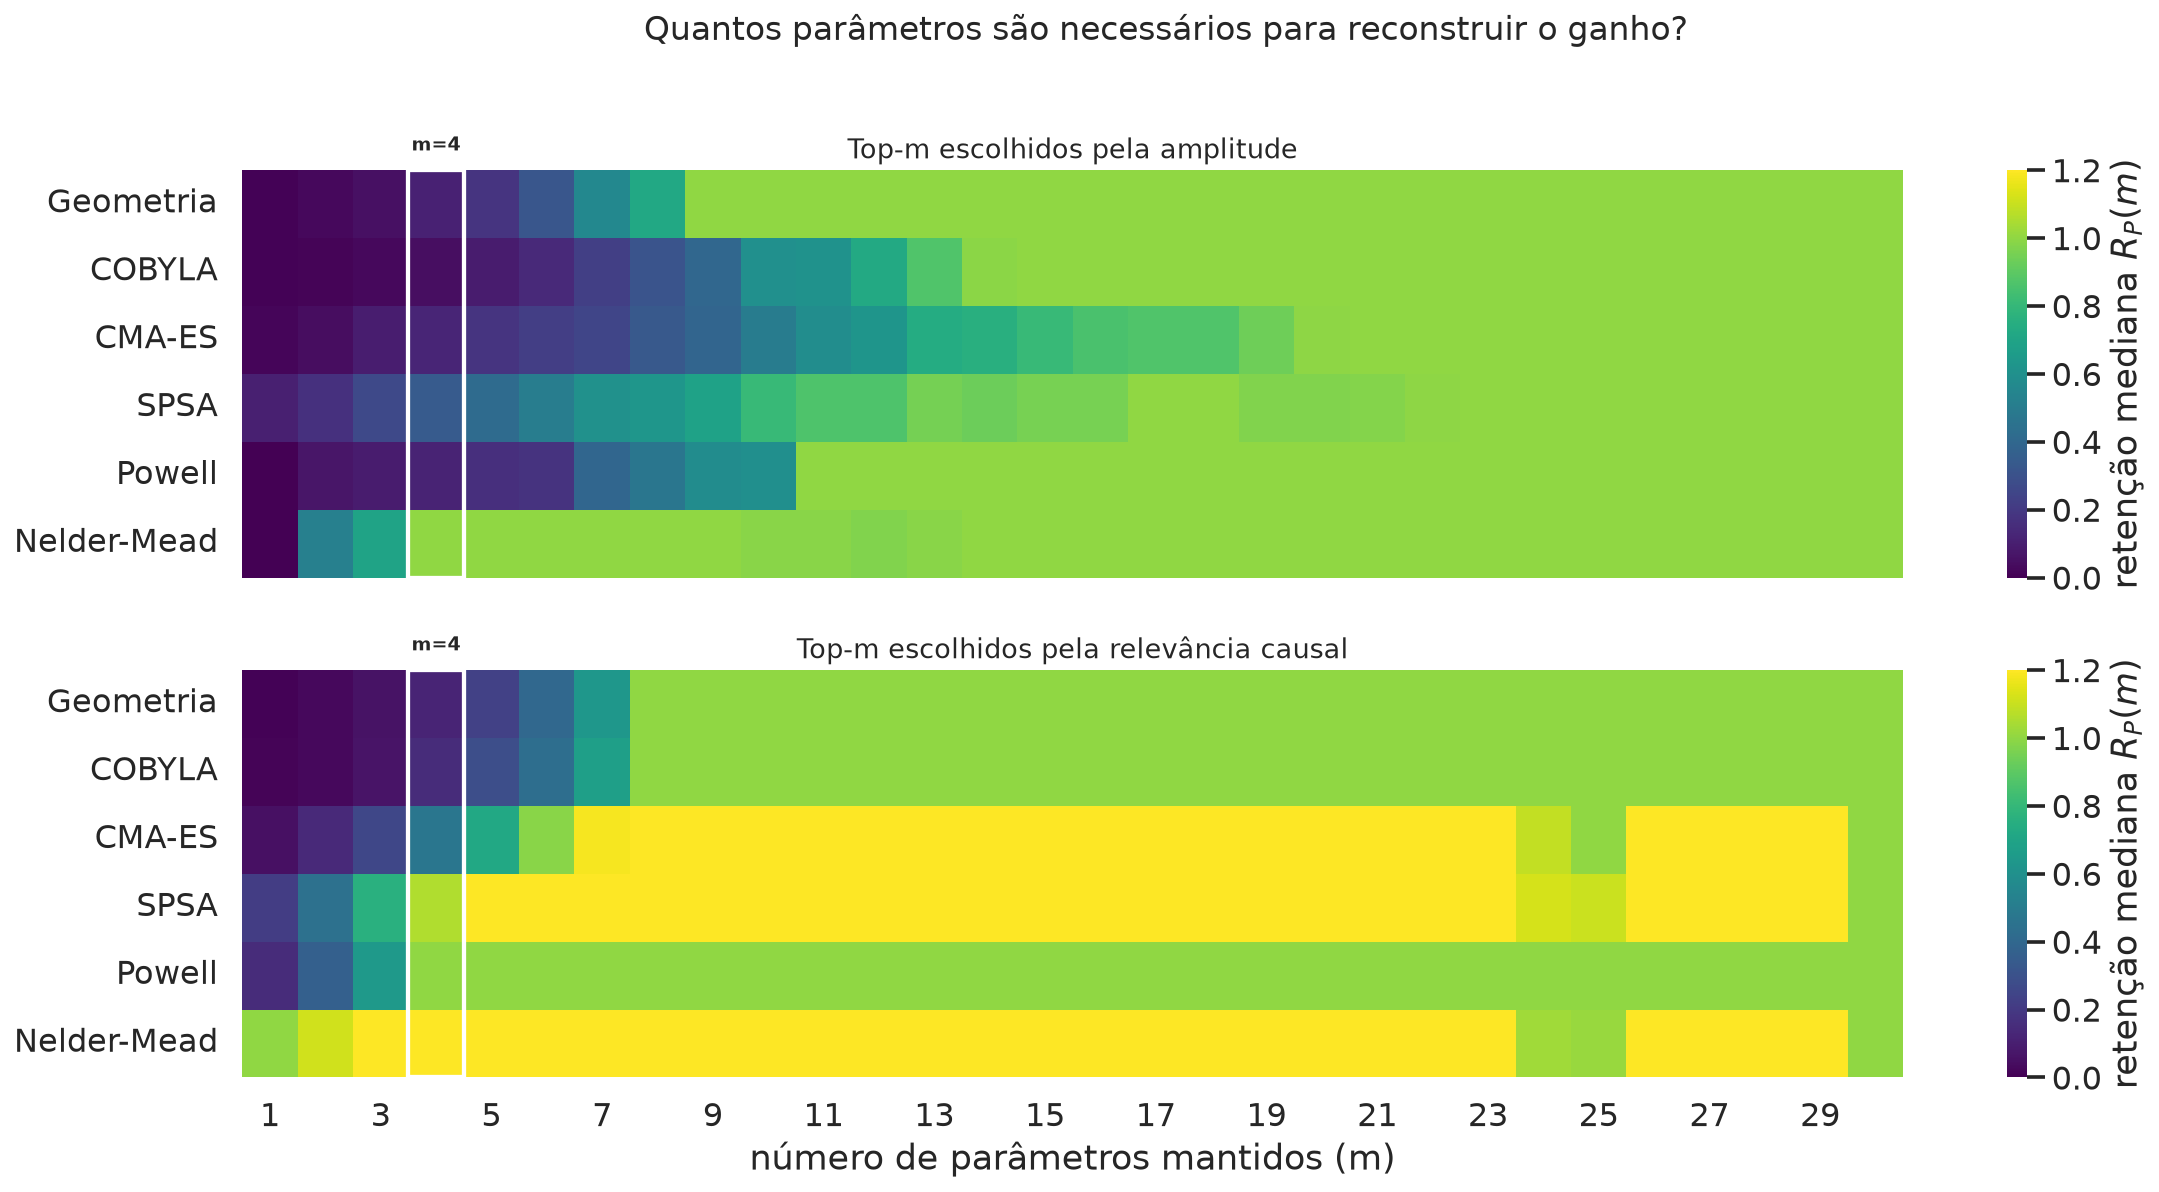

In [24]:
# =====================================================================
# RETENÇÃO TOP-m — HEATMAPS
# =====================================================================
#
# A curva foi substituída por uma matriz visual:
# linha = método;
# coluna = número m de parâmetros preservados;
# cor = retenção mediana do ganho.
#
# Isso remove linhas e legendas sobrepostas.
# =====================================================================

PATH_PLOT=(
    CAUSAL_PATH_DF.groupby(
        [
            "method",
            "ranking",
            "m",
        ],
        as_index=False,
    )
    .agg(
        median_retention=(
            "retention",
            "median",
        )
    )
)

PATH_PLOT[
    "method_label"
]=PATH_PLOT[
    "method"
].map(
    lambda x:label_map_theta.get(
        x,
        x,
    )
)

# Para visualização, limitamos a escala superior da cor.
# Valores >1 significam que o subconjunto supera o endpoint completo,
# mas não queremos que esses casos comprimam toda a paleta.
COLOR_CAP=1.20

fig,axes=plt.subplots(
    2,
    1,
    figsize=(17,8.5),
    sharex=True,
)

ranking_specs=[
    (
        "AMPLITUDE",
        "Top-m escolhidos pela amplitude",
    ),
    (
        "CAUSAL_SINGLE_ABLATION",
        "Top-m escolhidos pela relevância causal",
    ),
]

for ax,(
    ranking,
    title,
) in zip(
    axes,
    ranking_specs,
):
    g=PATH_PLOT[
        PATH_PLOT[
            "ranking"
        ]==ranking
    ].copy()

    pivot=(
        g.pivot(
            index="method_label",
            columns="m",
            values="median_retention",
        )
        .reindex(
            method_order_theta
        )
    )

    clipped=pivot.clip(
        lower=0,
        upper=COLOR_CAP,
    )

    sns.heatmap(
        clipped,
        cmap="viridis",
        vmin=0,
        vmax=COLOR_CAP,
        cbar=True,
        cbar_kws={
            "label":r"retenção mediana $R_P(m)$"
        },
        xticklabels=2,
        yticklabels=True,
        ax=ax,
    )

    ax.set_title(
        title,
        fontsize=14,
    )

    ax.set_ylabel("")
    ax.set_xlabel("")

    # Destaca visualmente a coluna m=4 com uma caixa.
    if 4 in pivot.columns:
        col_idx=list(
            pivot.columns
        ).index(
            4
        )

        rect=plt.Rectangle(
            (
                col_idx,
                0,
            ),
            1,
            len(
                pivot.index
            ),
            fill=False,
            edgecolor="white",
            linewidth=2.2,
        )

        ax.add_patch(
            rect
        )

        ax.text(
            col_idx+0.5,
            -0.22,
            "m=4",
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold",
        )


axes[-1].set_xlabel(
    "número de parâmetros mantidos (m)"
)

fig.suptitle(
    "Quantos parâmetros são necessários para reconstruir o ganho?",
    fontsize=17,
    y=1.01,
)

fig.tight_layout()

fig.savefig(
    PRESENTATION_FIG_DIR/
    "topm_retention_heatmaps_v2.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

### Como ler os heatmaps de retenção top-$m$

Cada célula responde:

> se eu mantiver apenas os primeiros $m$ parâmetros, quanto do ganho do endpoint
> completo sobre o Dicke é preservado?

A métrica é

$$
R_P(m)
=
\frac{
P_\star^{(m)}-P_{\star,D}
}{
P_\star^{\rm full}-P_{\star,D}
}.
$$

Valores próximos de

$$
R_P(m)=1
$$

significam que o subconjunto top-$m$ quase reproduz todo o ganho.

O destaque em $m=4$ testa diretamente a hipótese original dos “3–4 parâmetros”.

O resultado importante é que concentração de amplitude e suficiência funcional
não são a mesma coisa: poucos parâmetros podem ser dominantes, mas ainda
necessitar de coordenadas adicionais para reconstruir o endpoint de alta
probabilidade.

In [25]:
# Optional logical-key frequency analysis:
# do the same physical gates repeatedly appear among the largest geometry moves?

LOGICAL_ROWS=[]

for p in PROBLEMS:
    delta=geometry_delta_for_problem(
        p
    )

    theta=theta_state_from_delta(
        p,
        delta,
    )[
        "delta_theta"
    ]

    theta=np.asarray(
        theta,
        float,
    )

    order=np.argsort(
        -np.abs(
            theta
        ),
        kind="mergesort",
    )

    structure=BUNDLES[
        (
            p.n,
            p.k,
        )
    ][
        "structure"
    ]

    for rank,j in enumerate(
        order[
            :min(
                4,
                len(order),
            )
        ],
        start=1,
    ):
        row=structure.iloc[
            int(j)
        ]

        LOGICAL_ROWS.append(
            {
                "problem_id":p.problem_id,
                "market":p.market,
                "n":int(p.n),
                "k":int(p.k),
                "rank":int(rank),
                "parameter_index":int(j),
                "logical_key":str(
                    tuple(
                        row[
                            "logical_key"
                        ]
                    )
                ),
                "gate_type":str(
                    row[
                        "gate_type"
                    ]
                ),
                "l":int(
                    row[
                        "l"
                    ]
                ),
                "i":int(
                    row[
                        "i"
                    ]
                ),
                "abs_delta_theta":float(
                    abs(
                        theta[
                            j
                        ]
                    )
                ),
            }
        )


LOGICAL_TOP4_DF=pd.DataFrame(
    LOGICAL_ROWS
)

LOGICAL_TOP4_FREQ=(
    LOGICAL_TOP4_DF.groupby(
        [
            "n",
            "k",
            "logical_key",
            "gate_type",
            "l",
            "i",
        ],
        as_index=False,
    )
    .agg(
        appearances_top4=(
            "problem_id",
            "size",
        ),
        median_rank=(
            "rank",
            "median",
        ),
        median_abs_delta_theta=(
            "abs_delta_theta",
            "median",
        ),
    )
    .sort_values(
        [
            "n",
            "k",
            "appearances_top4",
            "median_rank",
        ],
        ascending=[
            True,
            True,
            False,
            True,
        ],
    )
)

display(
    LOGICAL_TOP4_FREQ.groupby(
        [
            "n",
            "k",
        ],
        group_keys=False,
    ).head(
        10
    )
)

LOGICAL_TOP4_DF.to_csv(
    PRESENTATION_DATA_DIR/
    "geometry_top4_logical_keys.csv",
    index=False,
)

LOGICAL_TOP4_FREQ.to_csv(
    PRESENTATION_DATA_DIR/
    "geometry_top4_logical_key_frequency.csv",
    index=False,
)

,n,k,logical_key,gate_type,l,i,appearances_top4,median_rank,median_abs_delta_theta
11,10,4,"(8, 4, 'CCY')",CCY,8,4,12,3.0,0.830787
2,10,4,"(3, 1, 'CCY')",CCY,3,1,10,3.0,0.870435
1,10,4,"(2, 1, 'CY')",CY,2,1,9,1.0,2.014888
12,10,4,"(9, 5, 'CCY')",CCY,9,5,6,3.0,0.815599
3,10,4,"(3, 2, 'CY')",CY,3,2,4,1.0,2.107205
5,10,4,"(4, 2, 'CCY')",CCY,4,2,4,2.0,0.932528
8,10,4,"(6, 3, 'CCY')",CCY,6,3,4,3.5,0.780925
0,10,4,"(1, 0, 'CY')",CY,1,0,3,1.0,1.554942
4,10,4,"(4, 1, 'CCY')",CCY,4,1,3,2.0,0.962049
6,10,4,"(5, 2, 'CCY')",CCY,5,2,3,4.0,0.828289



## 12. Tabelas finais e referências úteis

As tabelas finais abaixo resumem três perguntas complementares:

1. **Custo operacional**: quanto custa alcançar a geometria?
2. **Estrutura em $\theta$**: quão concentrado é o deslocamento físico?
3. **Causalidade**: poucos parâmetros são realmente suficientes/necessários?

### Referências de apoio para o contexto do notebook

- **Dicke, R. H. (1954).** *Coherence in Spontaneous Radiation Processes*. Phys. Rev. 93, 99–110.
- **Markowitz, H. (1952).** *Portfolio Selection*. Journal of Finance 7(1), 77–91.
- **Spall, J. C. (1998).** *Implementation of the simultaneous perturbation algorithm for stochastic optimization*. IEEE Trans. AES 34(3), 817–823.
- **Hansen, N. (2016).** *The CMA Evolution Strategy: A Tutorial*.
- **Powell, M. J. D.** referências clássicas sobre métodos direction-set/derivative-free.
- **Nocedal, J.; Wright, S.** *Numerical Optimization* — referência geral para otimização sem derivadas e análise numérica.

> Observação didática: estas referências servem para contextualizar o experimento; o notebook foi escrito para ser entendido sozinho, mesmo antes da leitura formal da literatura.


### Referências adicionais de otimização

- J. C. Spall, *Implementation of the simultaneous perturbation algorithm for
  stochastic optimization*, IEEE Transactions on Aerospace and Electronic
  Systems **34** (1998), 817–823. DOI: `10.1109/7.705889`.

- N. Hansen, *The CMA Evolution Strategy: A Tutorial*,
  arXiv:`1604.00772` (2016).

Essas referências são usadas apenas para contextualizar os otimizadores de
comparação; a geometria QR apresentada neste notebook é o objeto específico que
estamos investigando.


In [26]:
print(
    "="*110
)
print(
    "A) GLOBAL CATCH-UP"
)
display(
    GLOBAL_CATCH_SUMMARY
)

print(
    "="*110
)
print(
    "B) GLOBAL THETA STRUCTURE"
)
display(
    GLOBAL_THETA_SUMMARY
)

print(
    "="*110
)
print(
    "C) GLOBAL CAUSAL ABLATION"
)
display(
    GLOBAL_CAUSAL_SUMMARY
)

FINAL_CONTRACT={
    "geometry_fixed_shots":int(
        GEOM_COMPARE_SHOTS
    ),
    "geometry_target_uses_replicate_median":True,
    "geometry_theta_uses_replicate":int(
        GEOM_THETA_REPLICATE
    ),
    "catchup_is_first_queried_candidate_not_accepted_update":True,
    "theta_full_cohort_all_vqe_seeds":True,
    "causal_all_vqe_seeds":bool(
        CAUSAL_ALL_SEEDS
    ),
    "causal_fast_mode":bool(
        GEOM_FAST_CAUSAL
    ),
    "optimizers_present":list(
        OPTIMIZERS_PRESENT
    ),
    "problem_count":int(
        len(
            PROBLEMS
        )
    ),
}

with open(
    PRESENTATION_DATA_DIR/
    "v84_contract.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        FINAL_CONTRACT,
        f,
        indent=2,
        ensure_ascii=False,
    )

print(
    "Outputs:"
)
print(
    "PRESENTATION_DATA_DIR =",PRESENTATION_DATA_DIR
)
print(
    "PRESENTATION_FIG_DIR  =",PRESENTATION_FIG_DIR
)
print(
    "CAUSAL_CACHE =",CAUSAL_CACHE
)

A) GLOBAL CATCH-UP


,optimizer,runs,catchup_fraction,median_catchup_evals,median_catchup_rounds,median_catchup_shots,median_shot_ratio_vs_geometry
0,CMAES,192,0.057292,86.0,7.0,176128.0,21.50
1,COBYLA,192,0.588542,86.0,86.0,176128.0,21.50
2,NELDER_MEAD,192,0.000000,NaN,NaN,NaN,NaN
3,POWELL,192,0.015625,107.0,107.0,219136.0,26.75
4,SPSA,192,0.015625,96.0,48.0,196608.0,24.00


B) GLOBAL THETA STRUCTURE


,method,runs,median_theta_l2,median_theta_linf,median_deff,median_N90,median_top4_share,median_overlap_with_geometry
0,CMAES,192,2.158225,1.052394,8.569091,13.0,0.571245,0.719868
1,COBYLA,192,3.366487,1.716205,8.875672,14.0,0.520797,0.807044
2,GEOMETRY_8192_SHOTS,64,2.823486,1.976972,3.576283,7.0,0.765838,1.000000
3,NELDER_MEAD,192,0.000252,0.000241,1.088100,1.0,0.988027,0.278706
4,POWELL,192,5.746219,4.094235,3.495572,6.0,0.834720,0.560741
5,SPSA,192,0.833313,0.394978,9.487682,13.0,0.540083,0.700129


C) GLOBAL CAUSAL ABLATION


,method,endpoints,median_full_Pstar,median_max_single_ablation_loss,median_amplitude_m90_first,median_amplitude_m90_stable,median_causal_m90_first,median_causal_m90_stable,median_amplitude_top4_retention,median_causal_top4_retention,median_top4_causal_removal_loss
0,CMAES,64,0.068827,4.312806e-02,14.0,19.5,6.0,6.0,0.123195,0.471772,6.461525e-02
1,COBYLA,64,0.755812,4.198877e-01,13.0,15.0,8.0,8.0,0.045258,0.146419,7.166265e-01
2,GEOMETRY_8192_SHOTS,64,0.758659,5.254518e-01,9.0,9.0,8.0,8.0,0.109166,0.121031,7.348524e-01
3,NELDER_MEAD,64,0.003066,4.741574e-08,4.0,17.0,1.0,1.0,1.000000,1.814573,1.009266e-07
4,POWELL,64,0.049258,3.056247e-02,11.0,11.0,4.0,4.0,0.115521,1.000000,4.511705e-02
5,SPSA,64,0.012588,4.850095e-03,11.0,17.0,4.0,4.0,0.339100,1.056926,9.596759e-03


Outputs:
PRESENTATION_DATA_DIR = /home/marlonmaxuel/Desktop/v82105_paper1_operational_benchmark/presentation_analysis/data
PRESENTATION_FIG_DIR  = /home/marlonmaxuel/Desktop/v82105_paper1_operational_benchmark/presentation_analysis/figures
CAUSAL_CACHE = /home/marlonmaxuel/Desktop/v82105_paper1_operational_benchmark/presentation_analysis/cache/causal_ablation__seed0__full.pkl
